In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the correct path to your data directory
data_dir = '/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data'  # No leading './' needed if you're in the parent directory

# First check if directory exists
print(f"Directory exists: {os.path.exists(data_dir)}")

# List all CSV files in the directory
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files")
print(csv_files)


Directory exists: True
Found 13 CSV files
['WR.csv', 'NR.csv', 'NCR.csv', 'CR.csv', 'SCR.csv', 'NFR.csv', 'ECOR.csv', 'ECR.csv', 'WCR.csv', 'Test - Zone.csv', 'SR.csv', 'NER.csv', 'SECR.csv']


In [7]:
# Load all datasets into a dictionary
datasets = {}
for file_name in csv_files:
    file_path = os.path.join(data_dir, file_name)
    datasets[file_name] = pd.read_csv(file_path)
    print(f"Loaded {file_name} with shape {datasets[file_name].shape}")


Loaded WR.csv with shape (341322, 12)
Loaded NR.csv with shape (52334, 12)
Loaded NCR.csv with shape (49244, 12)
Loaded CR.csv with shape (105881, 12)
Loaded SCR.csv with shape (714, 12)
Loaded NFR.csv with shape (93138, 12)
Loaded ECOR.csv with shape (93553, 12)


/tmp/ipykernel_154680/4273555833.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  datasets[file_name] = pd.read_csv(file_path)


Loaded ECR.csv with shape (363007, 12)
Loaded WCR.csv with shape (17876, 12)
Loaded Test - Zone.csv with shape (23, 12)
Loaded SR.csv with shape (230590, 12)
Loaded NER.csv with shape (104215, 12)
Loaded SECR.csv with shape (135962, 12)


In [8]:
# Take a sample dataset to understand its structure
sample_file = csv_files[0]
print(f"\nSample from {sample_file}:")
print(datasets[sample_file].head())

# Check column names in all datasets to understand how to merge them
print("\nColumn names in each dataset:")
for file_name, data in datasets.items():
    print(f"{file_name}: {data.columns.tolist()}")



Sample from WR.csv:
                  Time Site Name Point Machine Name Direction  \
0  2025-02-10 01:04:09      Atul            101/102   Reverse   
1  2025-02-10 01:12:10      Atul            101/102    Normal   
2  2025-02-10 07:13:06      Atul            101/102   Reverse   
3  2025-02-10 08:00:53      Atul            101/102   Reverse   
4  2025-02-10 08:03:36      Atul            101/102    Normal   

                                           A Current  \
0  0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,...   
1  0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,...   
2  0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2....   
3  0.0,4.5,4.7,3.9,3.2,2.7,2.4,2.1,2,1.9,1.9,1.9,...   
4  0,5.1,5.1,4.1,3.4,2.9,2.5,2.2,2,1.9,1.8,1.8,1....   

                                           A Voltage  \
0  0.0,13.5,46.5,72.0,88.5,99.0,103.5,108.0,109.5...   
1  0.0,88.5,90.0,97.5,102.0,105.0,108.0,109.5,111...   
2  0.0,25.5,55.5,78.0,91.5,100.5,105.0,108.0,109....   
3  0.0,37.5,66.0,84.0,96.0,

In [9]:
# Basic data quality check for a sample dataset
sample_data = datasets[sample_file]
print(f"\nData types for {sample_file}:")
print(sample_data.dtypes)

print(f"\nMissing values in {sample_file}:")
print(sample_data.isnull().sum())

# Basic statistics
print(f"\nBasic statistics for {sample_file}:")
print(sample_data.describe())



Data types for WR.csv:
Time                   object
Site Name              object
Point Machine Name     object
Direction              object
A Current              object
A Voltage              object
B Current              object
B Voltage              object
Type of A              object
Type of B              object
Polling of A            int64
Polling of B          float64
dtype: object

Missing values in WR.csv:
Time                      0
Site Name                 0
Point Machine Name        0
Direction                 0
A Current               424
A Voltage               440
B Current               674
B Voltage               508
Type of A                 0
Type of B             50994
Polling of A              0
Polling of B          50994
dtype: int64

Basic statistics for WR.csv:
        Polling of A   Polling of B
count  341322.000000  290328.000000
mean       52.626552      52.471412
std        39.314588      39.285184
min        20.000000      20.000000
25%        20.00

In [10]:
# Check if all datasets have similar structure for merging
common_columns = set(datasets[csv_files[0]].columns)
for file_name in csv_files[1:]:
    common_columns = common_columns.intersection(set(datasets[file_name].columns))

print(f"\nCommon columns across all datasets: {list(common_columns)}")

# If there are common columns, we can use them for merging
# For demonstration, let's concatenate the first two datasets
if len(csv_files) >= 2:
    merged_sample = pd.concat([datasets[csv_files[0]], datasets[csv_files[1]]], ignore_index=True)
    print(f"\nMerged sample shape: {merged_sample.shape}")
    print(merged_sample.head())



Common columns across all datasets: ['Polling of A', 'Direction', 'Type of B', 'Point Machine Name', 'Type of A', 'Site Name', 'A Voltage', 'Time', 'A Current', 'B Voltage', 'B Current', 'Polling of B']

Merged sample shape: (393656, 12)
                  Time Site Name Point Machine Name Direction  \
0  2025-02-10 01:04:09      Atul            101/102   Reverse   
1  2025-02-10 01:12:10      Atul            101/102    Normal   
2  2025-02-10 07:13:06      Atul            101/102   Reverse   
3  2025-02-10 08:00:53      Atul            101/102   Reverse   
4  2025-02-10 08:03:36      Atul            101/102    Normal   

                                           A Current  \
0  0.0,1.5,4.9,4.5,3.7,3,2.6,2.3,2.1,1.9,1.9,1.8,...   
1  0,5.2,4.9,4,3.3,2.8,2.4,2.2,2,1.9,1.8,1.8,1.8,...   
2  0.0,3.2,4.9,4.2,3.5,2.9,2.5,2.2,2,1.9,2,2,2,2....   
3  0.0,4.5,4.7,3.9,3.2,2.7,2.4,2.1,2,1.9,1.9,1.9,...   
4  0,5.1,5.1,4.1,3.4,2.9,2.5,2.2,2,1.9,1.8,1.8,1....   

                                 

In [11]:
# Add zone identifier before concatenating
for zone_name, df in datasets.items():
    # Extract zone name from filename (remove .csv)
    zone = zone_name.replace('.csv', '')
    df['zone'] = zone


In [12]:
# Fix data types
for file_name, df in datasets.items():
    # Convert time to datetime
    df['Time'] = pd.to_datetime(df['Time'])
    
    # Handle the mixed type column with proper type casting
    # Assuming Point Machine Name is column 2 with mixed types
    df['Point Machine Name'] = df['Point Machine Name'].astype(str)


In [13]:
# Extract first value from array-like columns
def extract_first_value(value_str):
    try:
        return float(value_str.split(',')[0])
    except (ValueError, AttributeError):
        return None

# Apply to all datasets
for df in datasets.values():
    df['a_current_first'] = df['A Current'].apply(extract_first_value)
    df['a_voltage_first'] = df['A Voltage'].apply(extract_first_value)
    df['b_current_first'] = df['B Current'].apply(extract_first_value)
    df['b_voltage_first'] = df['B Voltage'].apply(extract_first_value)


In [14]:
# Standardize column names (replace spaces with underscores)
for df in datasets.values():
    df.columns = [col.lower().replace(' ', '_') for col in df.columns]


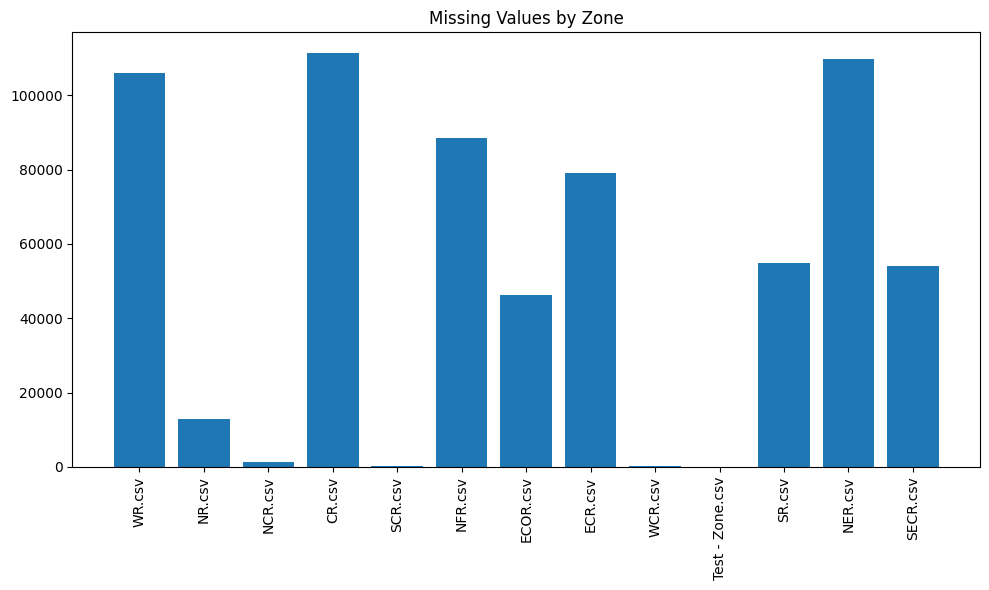

/tmp/ipykernel_154680/507441634.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_154680/507441634.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [15]:
# Check missing values across all datasets
def check_missing_values(datasets_dict):
    missing_counts = {}
    for name, df in datasets_dict.items():
        missing = df.isnull().sum().sum()
        missing_counts[name] = missing
        
    # Plot zones by missing value count
    plt.figure(figsize=(10, 6))
    plt.bar(missing_counts.keys(), missing_counts.values())
    plt.xticks(rotation=90)
    plt.title('Missing Values by Zone')
    plt.tight_layout()
    plt.show()
    
check_missing_values(datasets)

# Strategy for handling missing values
for df in datasets.values():
    # Fill missing numerical values appropriately
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        df[col].fillna(df[col].median(), inplace=True)
    
    # Fill categorical with mode or 'Unknown'
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col].fillna('Unknown', inplace=True)


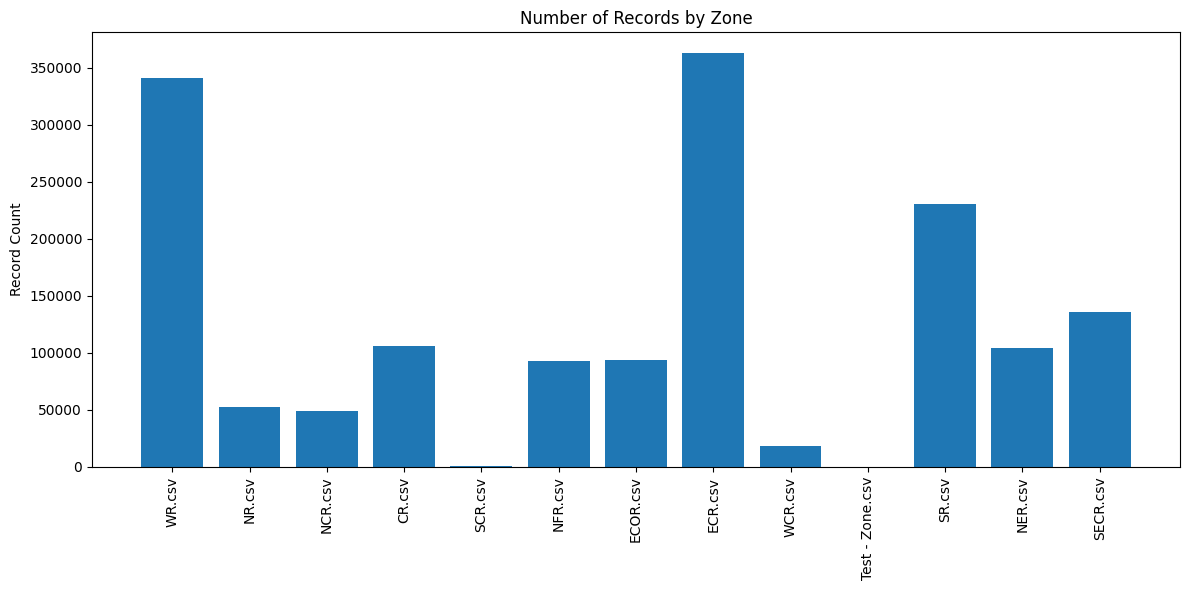

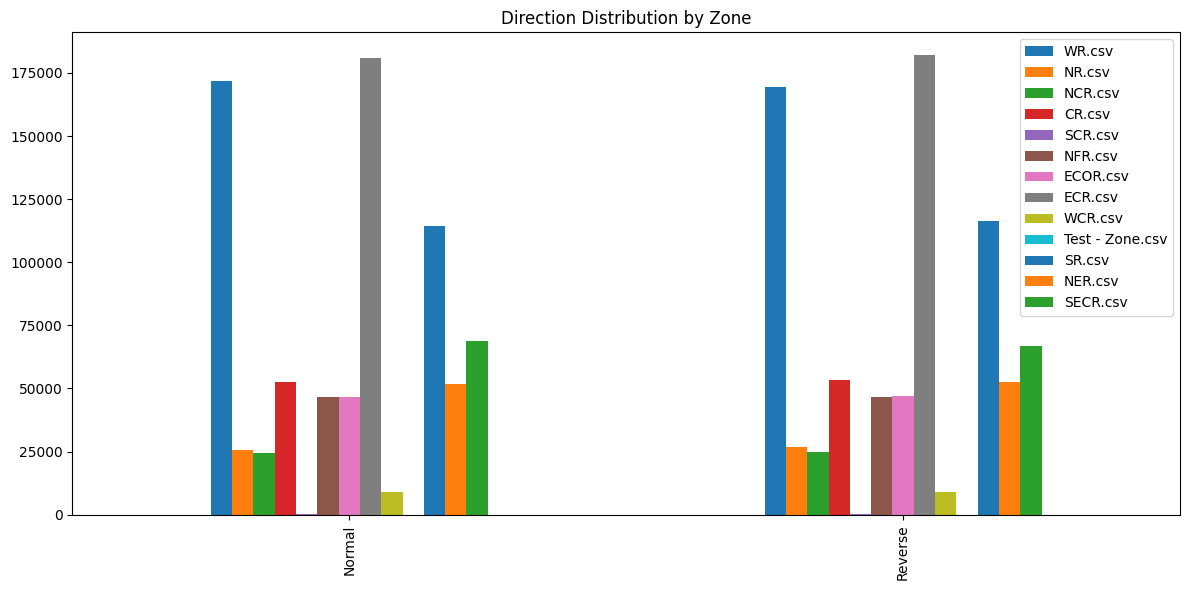

In [16]:
# Add basic visualizations
def visualize_data_overview(datasets_dict):
    # Create dataset size comparison
    sizes = {name: len(df) for name, df in datasets_dict.items()}
    
    plt.figure(figsize=(12, 6))
    plt.bar(sizes.keys(), sizes.values())
    plt.xticks(rotation=90)
    plt.title('Number of Records by Zone')
    plt.ylabel('Record Count')
    plt.tight_layout()
    plt.show()
    
    # Direction distribution across zones
    directions = {}
    for name, df in datasets_dict.items():
        directions[name] = df['direction'].value_counts().to_dict()
    
    direction_df = pd.DataFrame(directions).fillna(0)
    direction_df.plot(kind='bar', figsize=(12, 6))
    plt.title('Direction Distribution by Zone')
    plt.tight_layout()
    plt.show()

visualize_data_overview(datasets)


In [17]:
# Create final merged dataset with proper documentation
def create_merged_dataset(datasets_dict):
    """
    Creates a merged dataset from all zone datasets with proper
    data type handling and zone identification.
    """
    # List to hold processed dataframes
    processed_dfs = []
    
    for zone_name, df in datasets_dict.items():
        # Create a copy to avoid modifying original
        processed_df = df.copy()
        
        # Add zone info
        zone = zone_name.replace('.csv', '')
        processed_df['zone'] = zone
        
        # Add to list
        processed_dfs.append(processed_df)
    
    # Concatenate all
    merged_df = pd.concat(processed_dfs, ignore_index=True)
    
    print(f"Created merged dataset with {len(merged_df)} rows")
    print(f"Memory usage: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return merged_df

final_dataset = create_merged_dataset(datasets)


Created merged dataset with 1587859 rows
Memory usage: 2949.78 MB


In [18]:
# Optimize memory usage for large dataset
def optimize_memory(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage before optimization: {start_mem:.2f} MB")
    
    # Optimize numeric columns
    for col in df.select_dtypes(include=['float64']):
        df[col] = df[col].astype('float32')
    
    # Optimize integer columns
    for col in df.select_dtypes(include=['int64']):
        df[col] = df[col].astype('int32')
    
    # Optimize object columns with categorical when appropriate
    for col in df.select_dtypes(include=['object']):
        if df[col].nunique() < df.shape[0] * 0.5:  # If less than 50% unique values
            df[col] = df[col].astype('category')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage after optimization: {end_mem:.2f} MB")
    print(f"Reduced by {(start_mem - end_mem) / start_mem * 100:.1f}%")
    
    return df

final_dataset = optimize_memory(final_dataset)


Memory usage before optimization: 2949.78 MB
Memory usage after optimization: 2359.76 MB
Reduced by 20.0%


# Distribution Analysis

In [20]:
import numpy as np

Total number of datasets: 13
Total number of records: 1,587,859


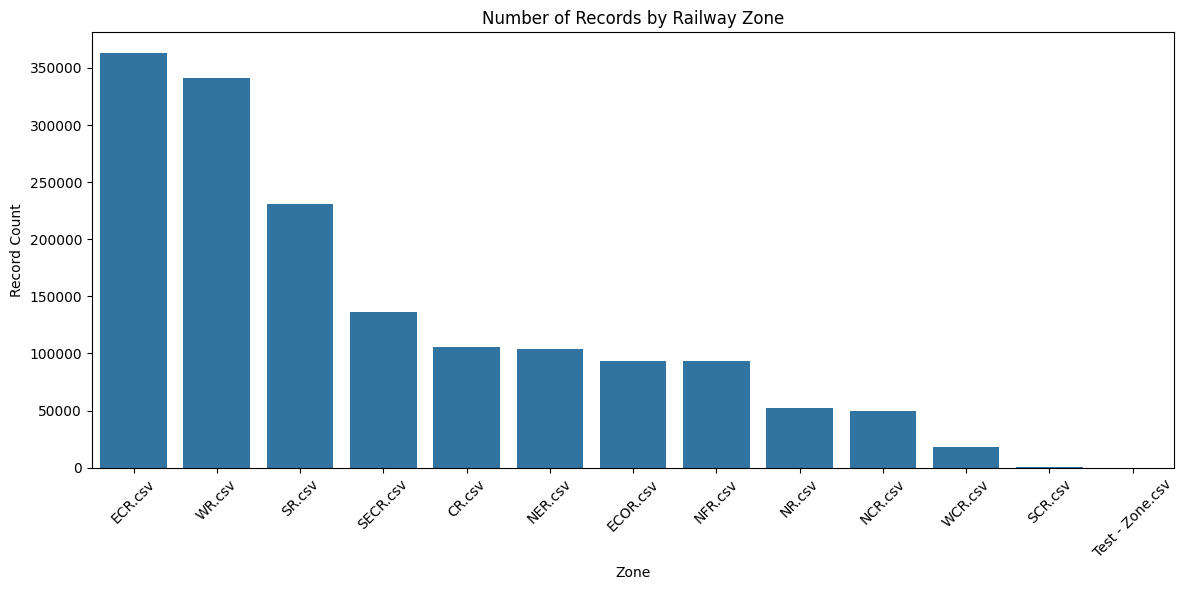


Numeric Variable Statistics:

A_CURRENT_FIRST:
  mean: 0.07
  median: 0.00
  min: 0.00
  max: 1.00
  std: 0.23

A_VOLTAGE_FIRST:
  mean: 0.01
  median: 0.00
  min: 0.00
  max: 235.90
  std: 0.79

B_CURRENT_FIRST:
  mean: 0.06
  median: 0.00
  min: 0.00
  max: 12.00
  std: 0.21

B_VOLTAGE_FIRST:
  mean: 0.02
  median: 0.00
  min: 0.00
  max: 1250.80
  std: 1.51


In [21]:
# Create a comprehensive dataset profile
def dataset_profile(datasets_dict):
    total_records = sum(len(df) for df in datasets_dict.values())
    zones_count = len(datasets_dict)
    
    print(f"Total number of datasets: {zones_count}")
    print(f"Total number of records: {total_records:,}")
    
    # Record distribution by zone
    zone_sizes = {zone: len(df) for zone, df in datasets_dict.items()}
    
    # Calculate basic statistics for each numeric column
    numeric_stats = {}
    for column in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
        all_values = []
        for df in datasets_dict.values():
            if column in df.columns:
                all_values.extend(df[column].dropna().tolist())
        
        if all_values:
            numeric_stats[column] = {
                'mean': np.mean(all_values),
                'median': np.median(all_values),
                'min': min(all_values),
                'max': max(all_values),
                'std': np.std(all_values)
            }
    
    # Create visualization of zone distributions
    plt.figure(figsize=(12, 6))
    zone_names = list(zone_sizes.keys())
    zone_counts = list(zone_sizes.values())
    
    # Sort by count
    sorted_indices = np.argsort(zone_counts)[::-1]
    sorted_zones = [zone_names[i] for i in sorted_indices]
    sorted_counts = [zone_counts[i] for i in sorted_indices]
    
    sns.barplot(x=sorted_zones, y=sorted_counts)
    plt.title('Number of Records by Railway Zone')
    plt.xlabel('Zone')
    plt.ylabel('Record Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Print numeric statistics
    print("\nNumeric Variable Statistics:")
    for column, stats in numeric_stats.items():
        print(f"\n{column.upper()}:")
        for stat_name, value in stats.items():
            print(f"  {stat_name}: {value:.2f}")
            
    # Return the profile data for further analysis
    return {
        'total_records': total_records,
        'zones_count': zones_count,
        'zone_sizes': zone_sizes,
        'numeric_stats': numeric_stats
    }

profile = dataset_profile(datasets)


# Temporal analysis

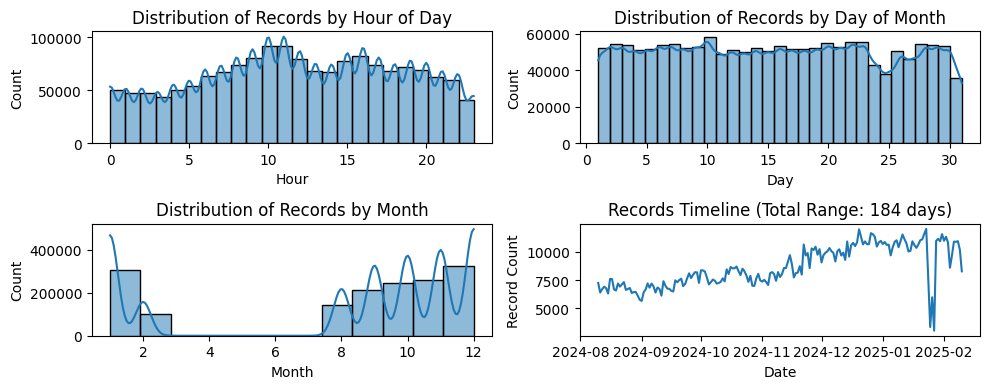

In [22]:
# Extract datetime components for analysis
def analyze_temporal_patterns(datasets_dict):
    # Combine all time data
    all_times = []
    zone_times = {}
    
    for zone, df in datasets_dict.items():
        if 'time' in df.columns:
            zone_df = df.copy()
            # Extract datetime components
            zone_df['hour'] = zone_df['time'].dt.hour
            zone_df['day'] = zone_df['time'].dt.day
            zone_df['month'] = zone_df['time'].dt.month
            zone_df['year'] = zone_df['time'].dt.year
            
            all_times.extend(zone_df['time'].tolist())
            zone_times[zone] = zone_df['time'].tolist()
    
    # Create time-based visualizations
    plt.figure(figsize=(18, 12))
    
    # Hour distribution
    plt.subplot(2, 2, 1)
    hours = [t.hour for t in all_times]
    sns.histplot(hours, bins=24, kde=True)
    plt.title('Distribution of Records by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Count')
    
    # Day distribution
    plt.subplot(2, 2, 2)
    days = [t.day for t in all_times]
    sns.histplot(days, bins=31, kde=True)
    plt.title('Distribution of Records by Day of Month')
    plt.xlabel('Day')
    plt.ylabel('Count')
    
    # Month distribution
    plt.subplot(2, 2, 3)
    months = [t.month for t in all_times]
    sns.histplot(months, bins=12, kde=True)
    plt.title('Distribution of Records by Month')
    plt.xlabel('Month')
    plt.ylabel('Count')
    
    # Time range analysis
    plt.subplot(2, 2, 4)
    if all_times:
        earliest = min(all_times)
        latest = max(all_times)
        time_range = latest - earliest
        time_range_days = time_range.days
        
        # Create a timeline of record counts
        timeline_df = pd.DataFrame({'time': all_times})
        timeline_df['date'] = timeline_df['time'].dt.date
        date_counts = timeline_df['date'].value_counts().sort_index()
        
        date_counts.plot(figsize=(10, 4))
        plt.title(f'Records Timeline (Total Range: {time_range_days} days)')
        plt.xlabel('Date')
        plt.ylabel('Record Count')
    
    plt.tight_layout()
    plt.show()
    
    # Return temporal analysis data
    return {
        'all_times': all_times,
        'zone_times': zone_times
    }

temporal_analysis = analyze_temporal_patterns(datasets)


# Current and Voltage Analysis

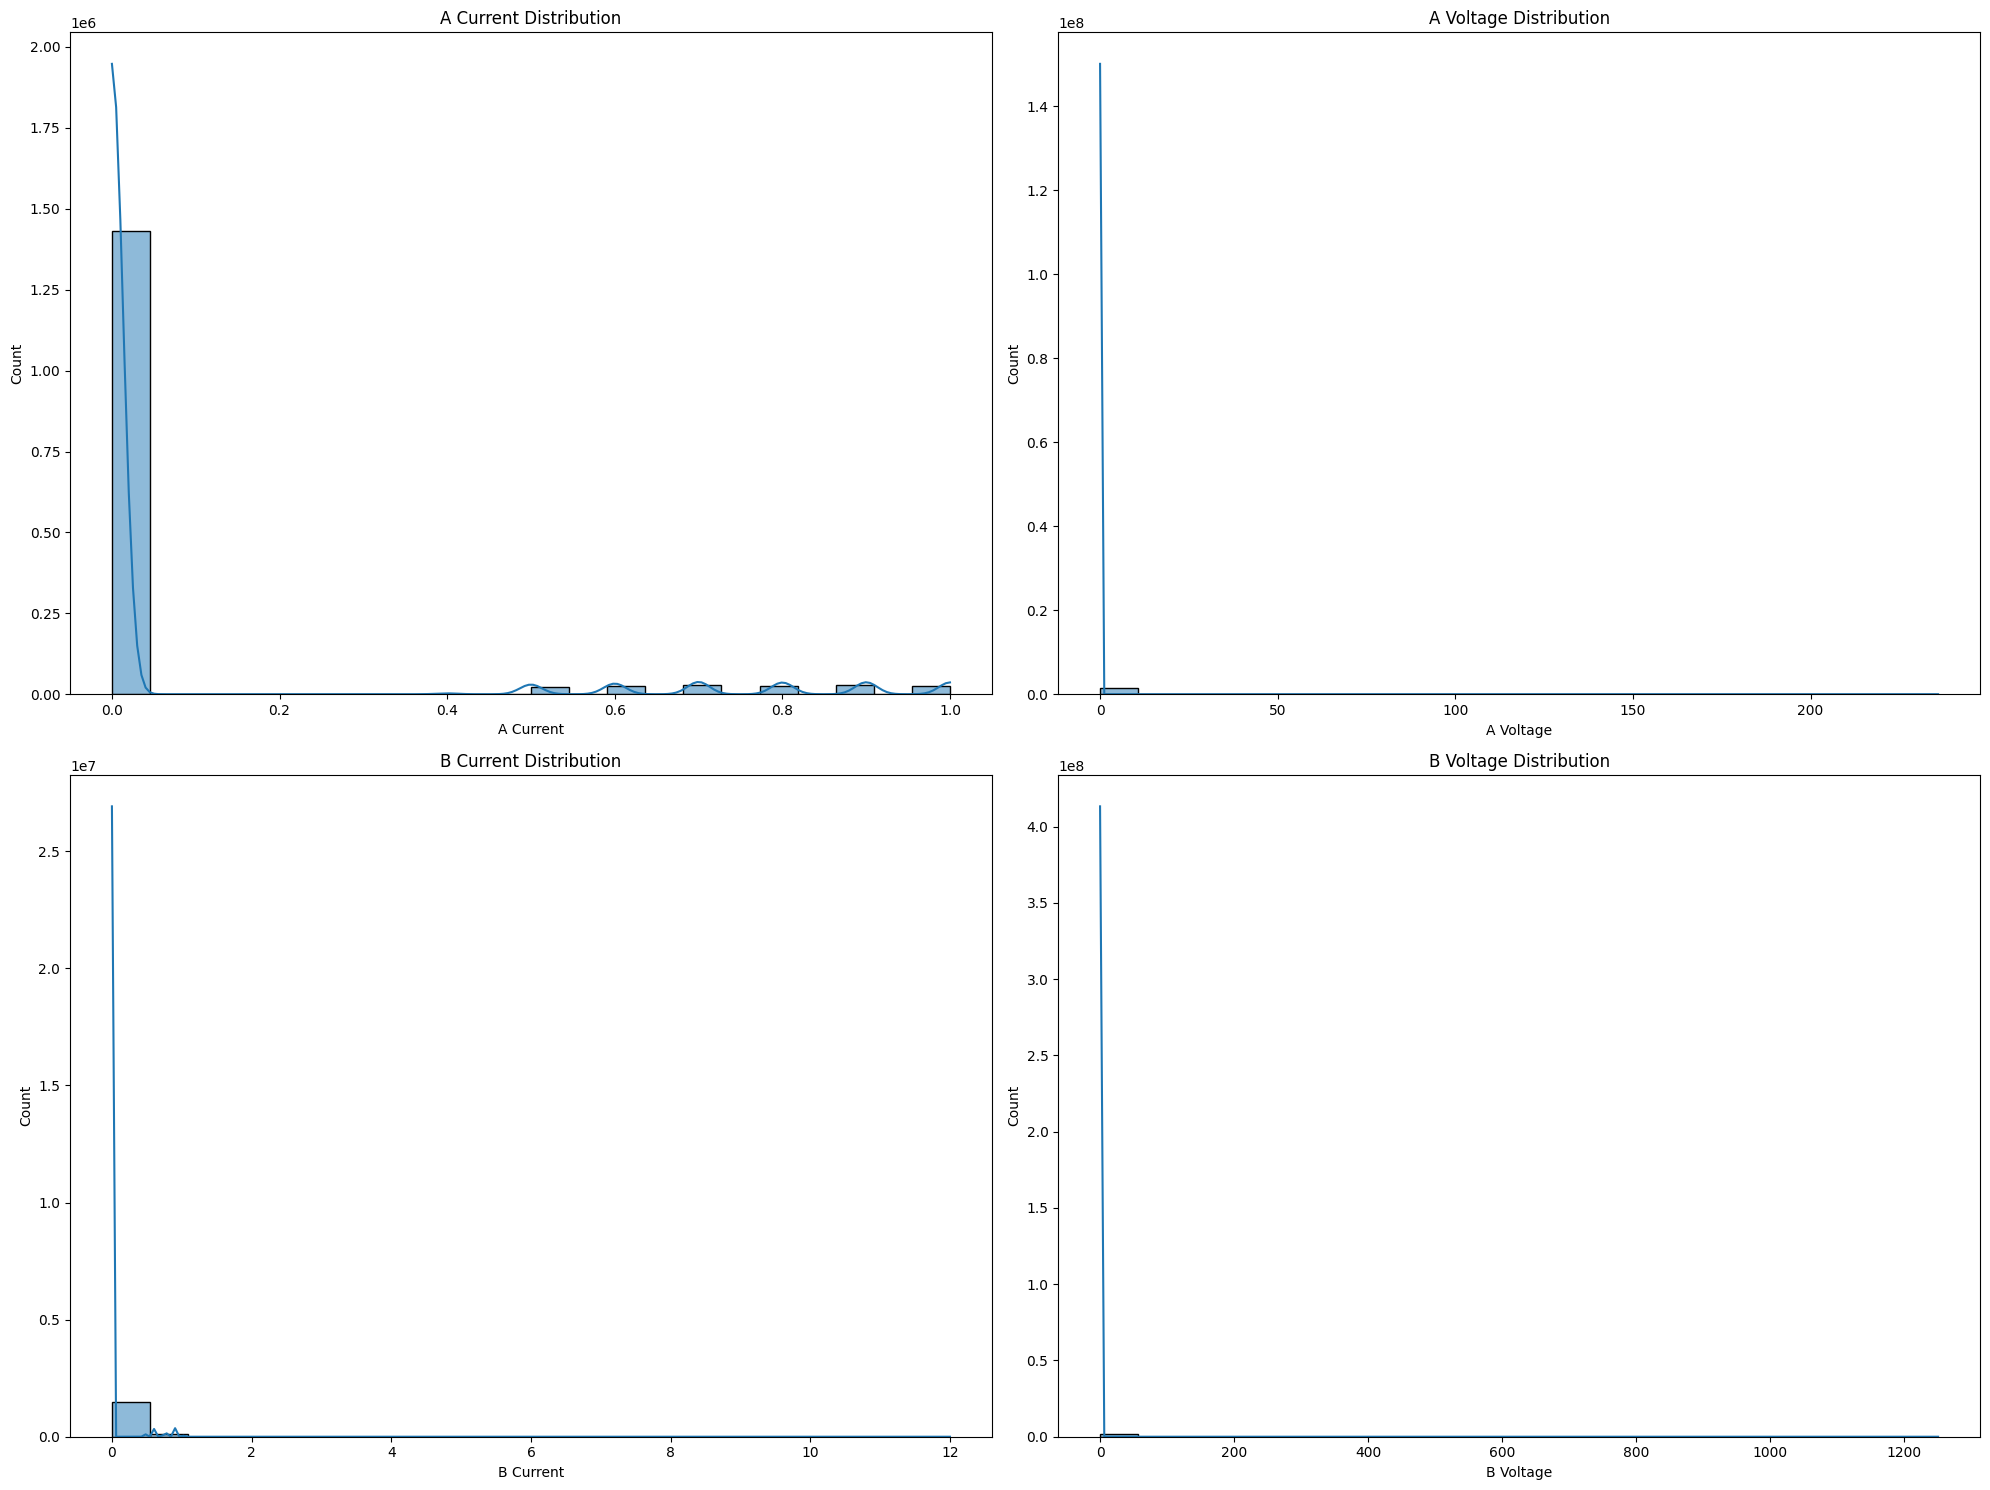

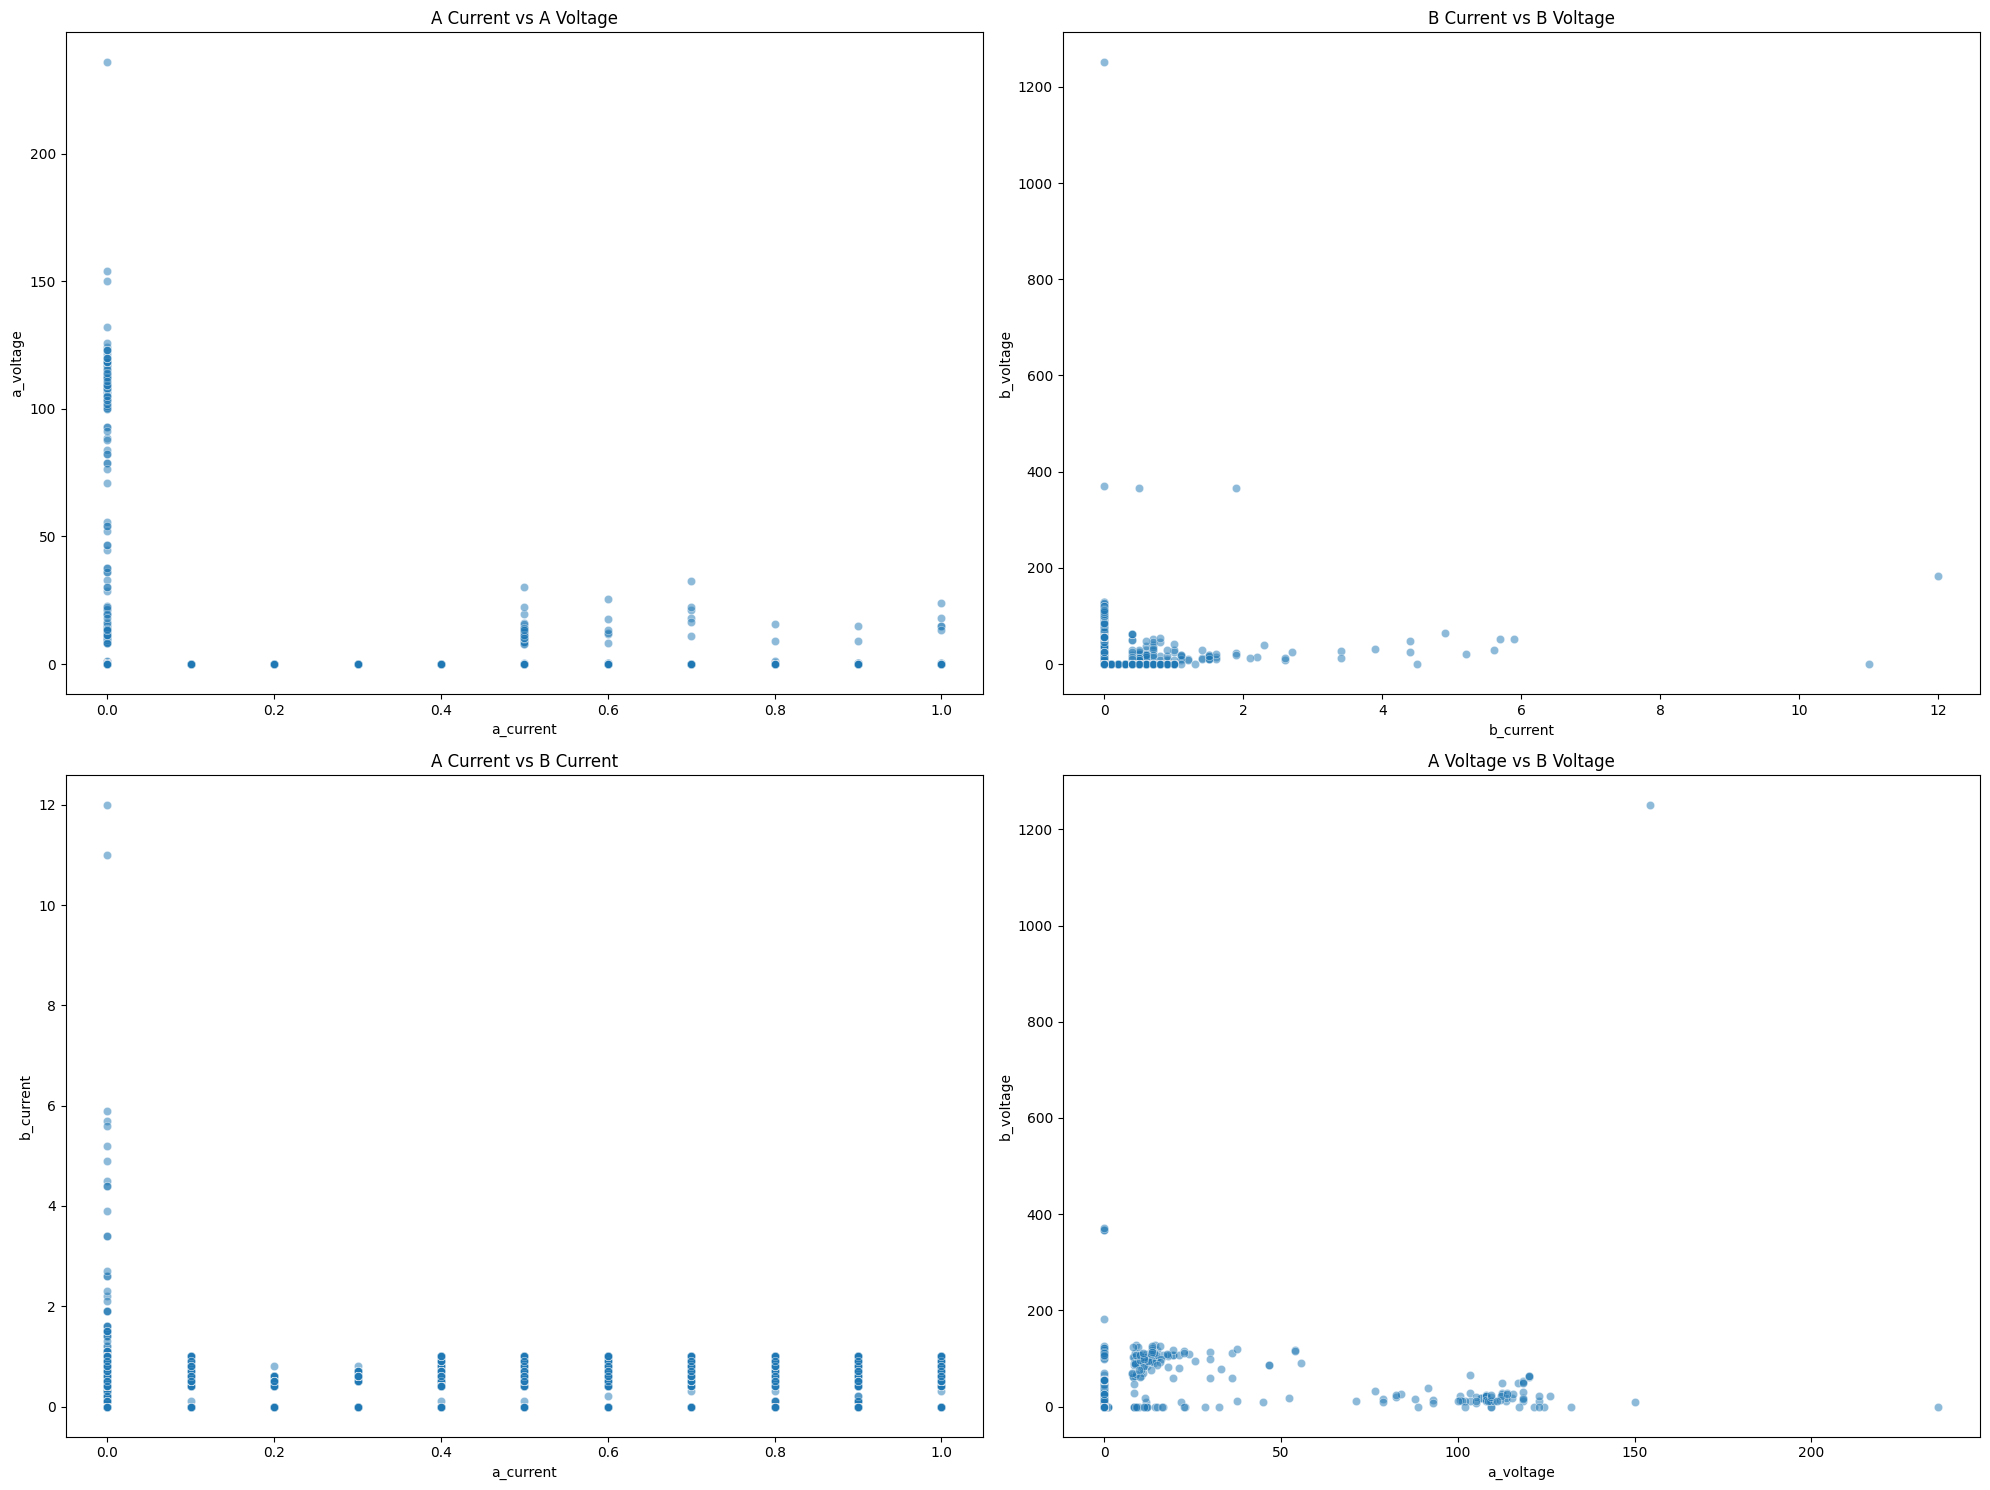

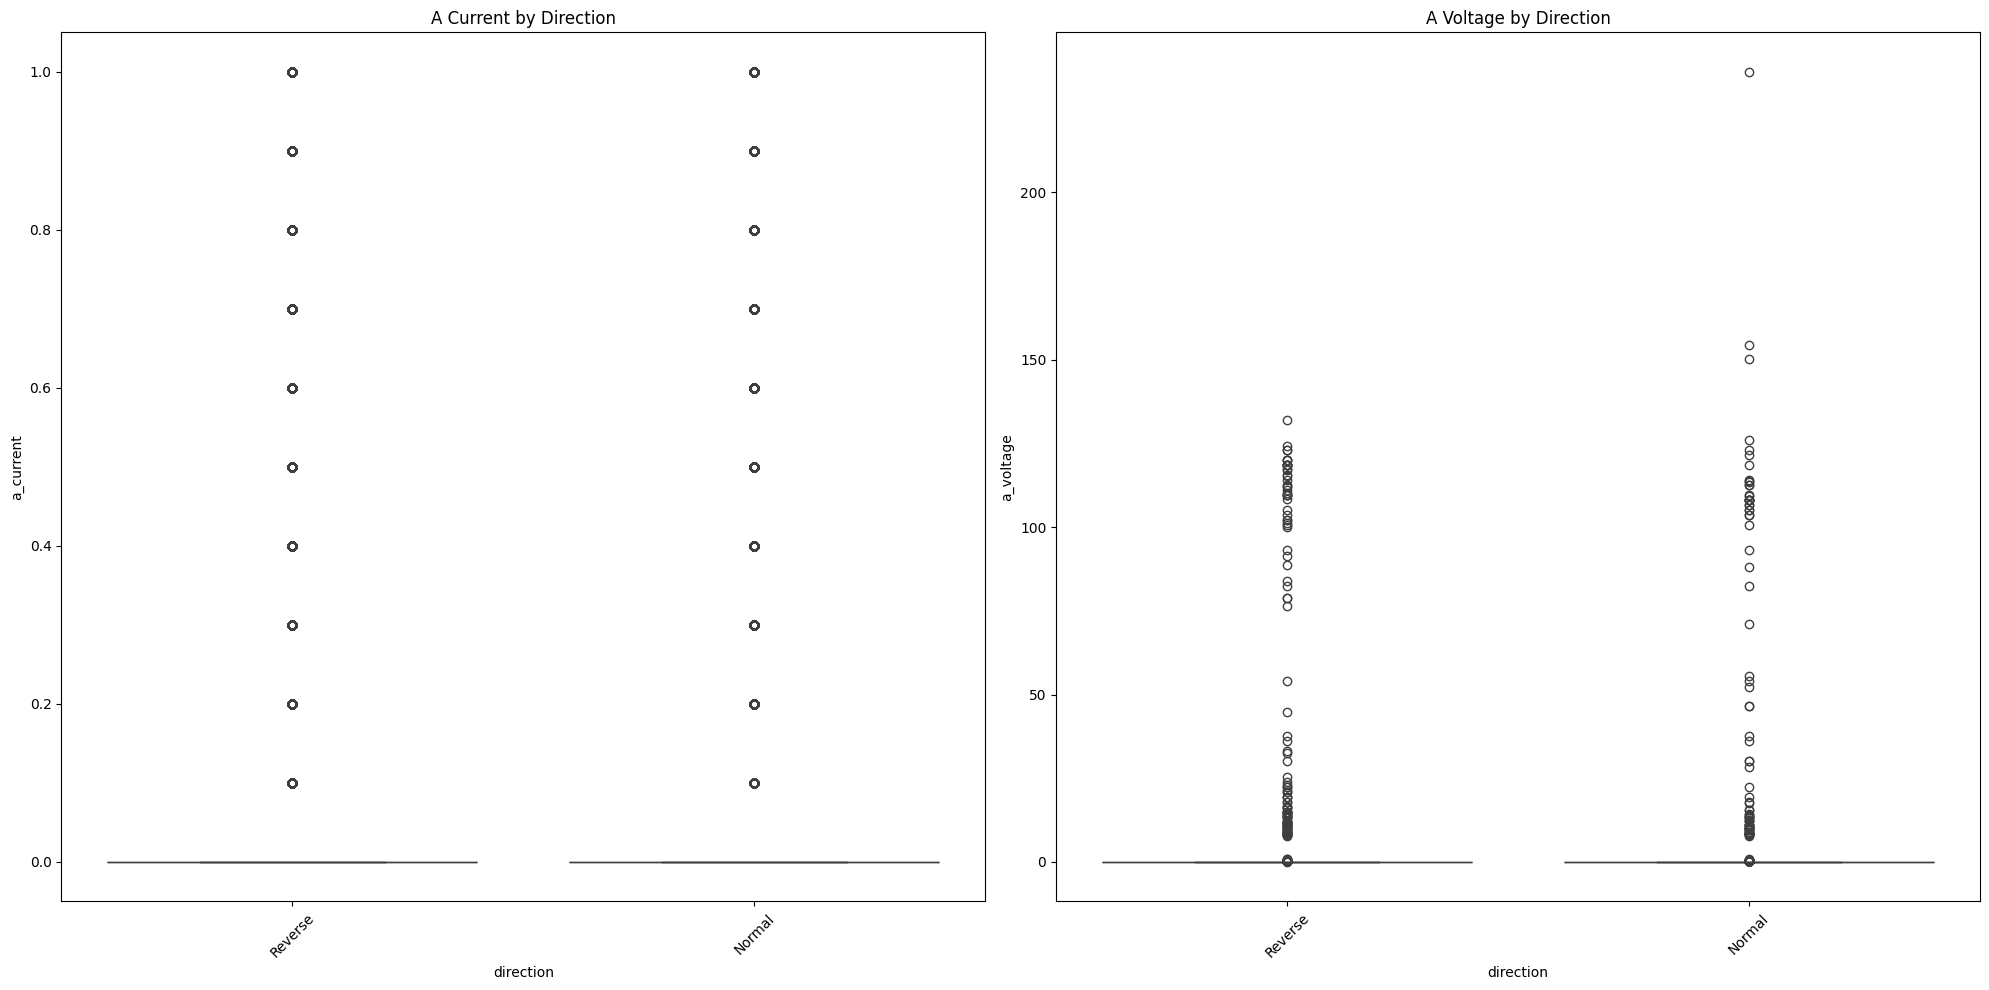

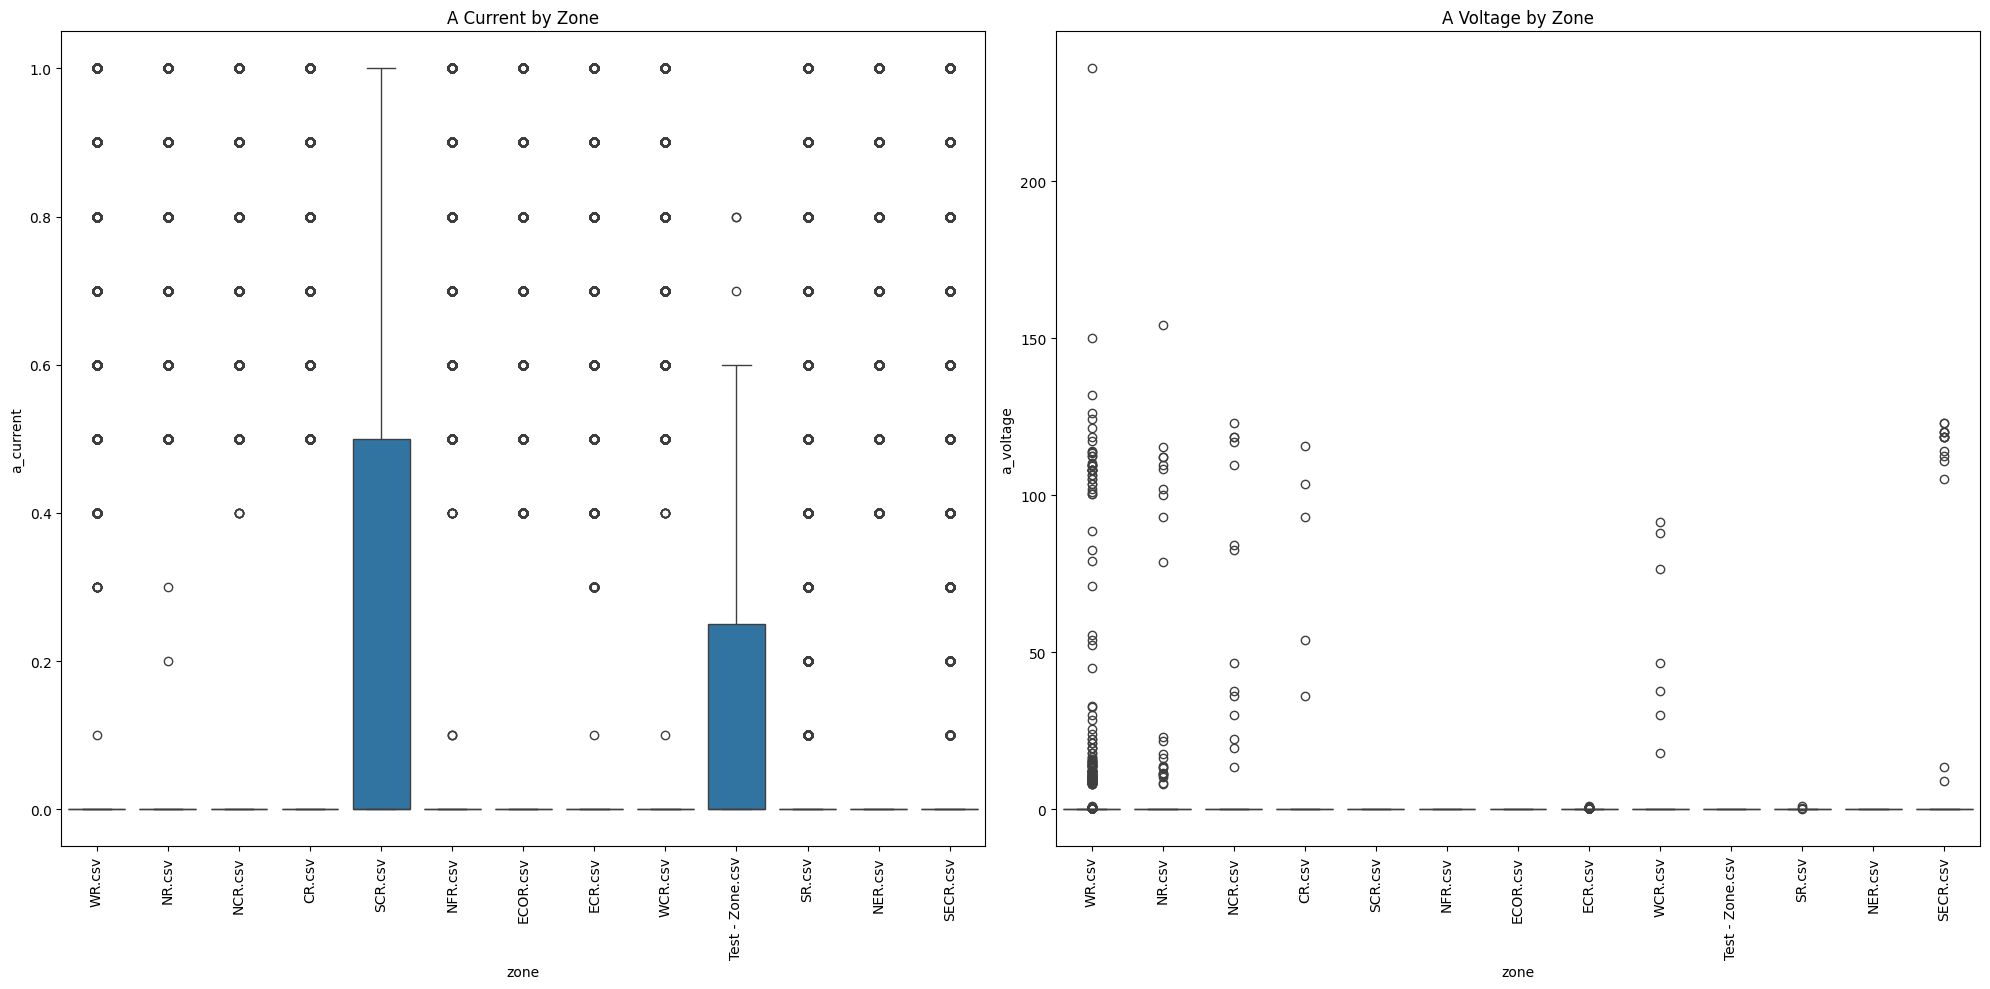

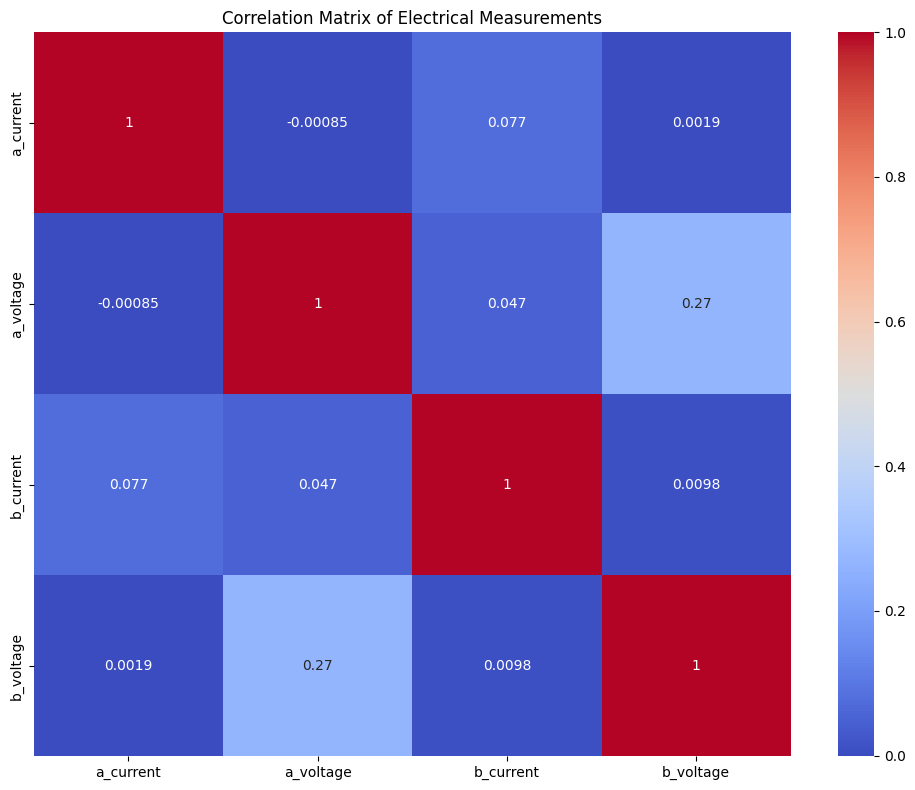

In [31]:
# Analyze current and voltage patterns
def analyze_electrical_measurements(datasets_dict):
    # Create a list to store complete rows of data
    all_data = []
    
    for zone, df in datasets_dict.items():
        required_columns = ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']
        
        # Check if all required columns exist
        if all(col in df.columns for col in required_columns):
            # Get rows with all electrical measurements available
            valid_rows = df.dropna(subset=required_columns)
            
            for idx, row in valid_rows.iterrows():
                # Get direction if available
                direction = row['direction'] if 'direction' in df.columns else 'Unknown'
                
                all_data.append({
                    'a_current': row['a_current_first'],
                    'a_voltage': row['a_voltage_first'],
                    'b_current': row['b_current_first'],
                    'b_voltage': row['b_voltage_first'],
                    'zone': zone,
                    'direction': direction
                })
    
    # Create dataframe for analysis
    if all_data:
        electrical_df = pd.DataFrame(all_data)
    else:
        # Create empty DataFrame with expected columns if no data
        electrical_df = pd.DataFrame(columns=[
            'a_current', 'a_voltage', 'b_current', 'b_voltage', 'zone', 'direction'
        ])
    
    # Visualize distributions
    plt.figure(figsize=(20, 15))
    
    # A Current distribution
    plt.subplot(2, 2, 1)
    sns.histplot(data=electrical_df, x='a_current', kde=True)
    plt.title('A Current Distribution')
    plt.xlabel('A Current')
    
    # A Voltage distribution
    plt.subplot(2, 2, 2)
    sns.histplot(data=electrical_df, x='a_voltage', kde=True)
    plt.title('A Voltage Distribution')
    plt.xlabel('A Voltage')
    
    # B Current distribution
    plt.subplot(2, 2, 3)
    sns.histplot(data=electrical_df, x='b_current', kde=True)
    plt.title('B Current Distribution')
    plt.xlabel('B Current')
    
    # B Voltage distribution
    plt.subplot(2, 2, 4)
    sns.histplot(data=electrical_df, x='b_voltage', kde=True)
    plt.title('B Voltage Distribution')
    plt.xlabel('B Voltage')
    
    plt.tight_layout()
    plt.show()
    
    # Relationship analysis
    plt.figure(figsize=(20, 15))
    
    # A Current vs A Voltage
    plt.subplot(2, 2, 1)
    sns.scatterplot(data=electrical_df, x='a_current', y='a_voltage', alpha=0.5)
    plt.title('A Current vs A Voltage')
    
    # B Current vs B Voltage
    plt.subplot(2, 2, 2)
    sns.scatterplot(data=electrical_df, x='b_current', y='b_voltage', alpha=0.5)
    plt.title('B Current vs B Voltage')
    
    # A Current vs B Current
    plt.subplot(2, 2, 3)
    sns.scatterplot(data=electrical_df, x='a_current', y='b_current', alpha=0.5)
    plt.title('A Current vs B Current')
    
    # A Voltage vs B Voltage
    plt.subplot(2, 2, 4)
    sns.scatterplot(data=electrical_df, x='a_voltage', y='b_voltage', alpha=0.5)
    plt.title('A Voltage vs B Voltage')
    
    plt.tight_layout()
    plt.show()
    
    # Direction-based analysis
    plt.figure(figsize=(20, 10))
    
    # Current by direction
    plt.subplot(1, 2, 1)
    sns.boxplot(data=electrical_df, x='direction', y='a_current')
    plt.title('A Current by Direction')
    plt.xticks(rotation=45)
    
    # Voltage by direction
    plt.subplot(1, 2, 2)
    sns.boxplot(data=electrical_df, x='direction', y='a_voltage')
    plt.title('A Voltage by Direction')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Zone-based electrical measurements
    plt.figure(figsize=(20, 10))
    
    # Current by zone
    plt.subplot(1, 2, 1)
    sns.boxplot(data=electrical_df, x='zone', y='a_current')
    plt.title('A Current by Zone')
    plt.xticks(rotation=90)
    
    # Voltage by zone
    plt.subplot(1, 2, 2)
    sns.boxplot(data=electrical_df, x='zone', y='a_voltage')
    plt.title('A Voltage by Zone')
    plt.xticks(rotation=90)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    correlation_values = electrical_df[['a_current', 'a_voltage', 'b_current', 'b_voltage']].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_values, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix of Electrical Measurements')
    plt.tight_layout()
    plt.show()
    
    # Return the dataframe for further analysis
    return electrical_df

electrical_analysis = analyze_electrical_measurements(datasets)


# Direction and Point machine type analysis

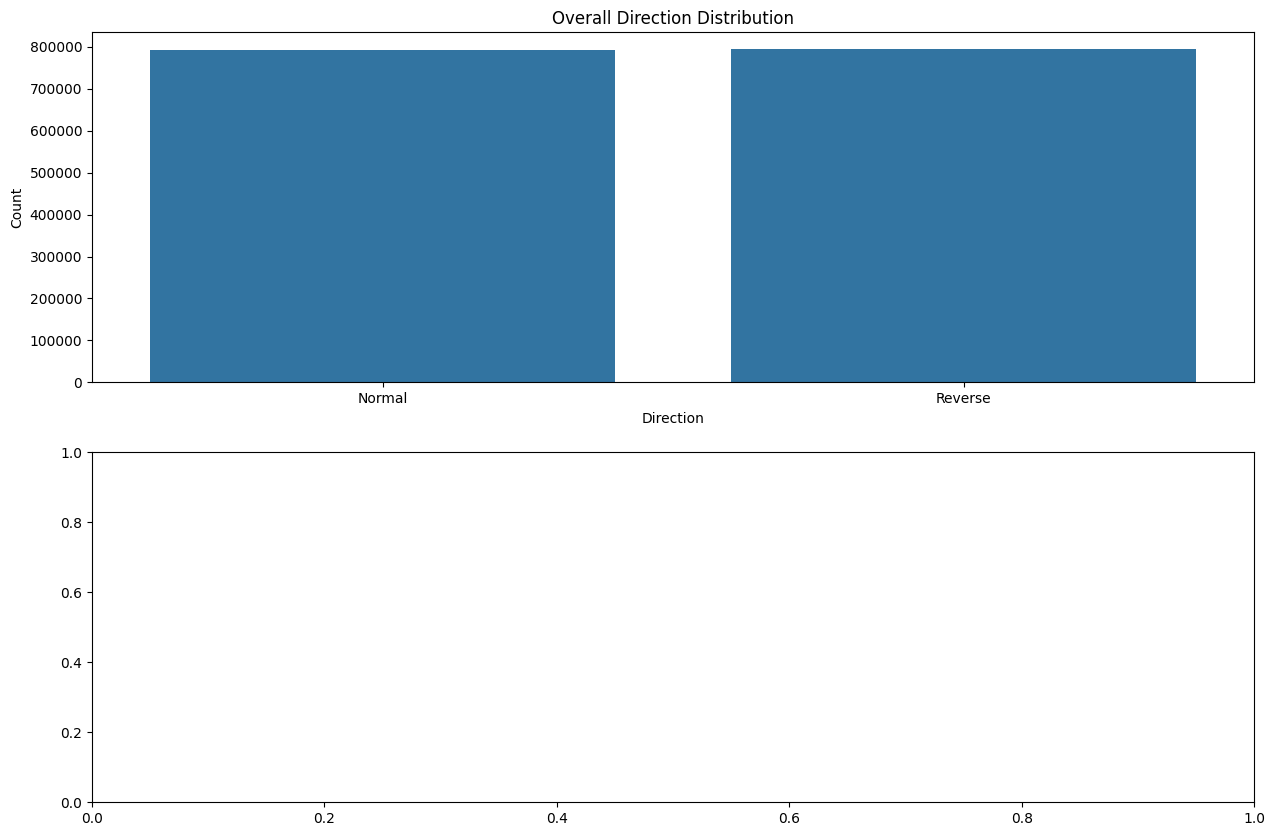

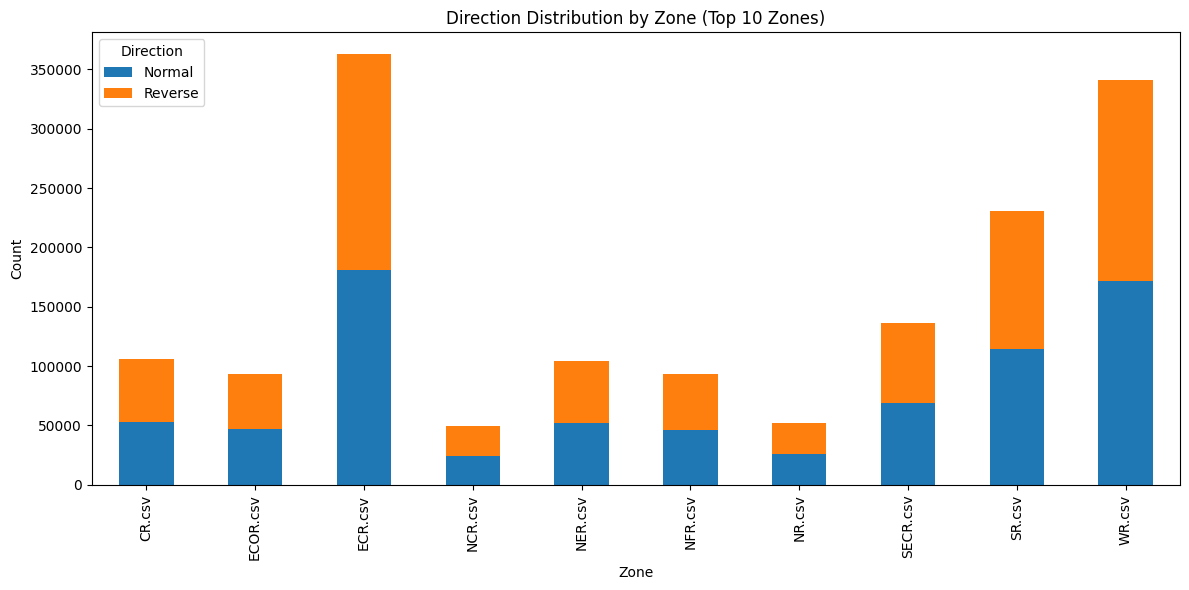

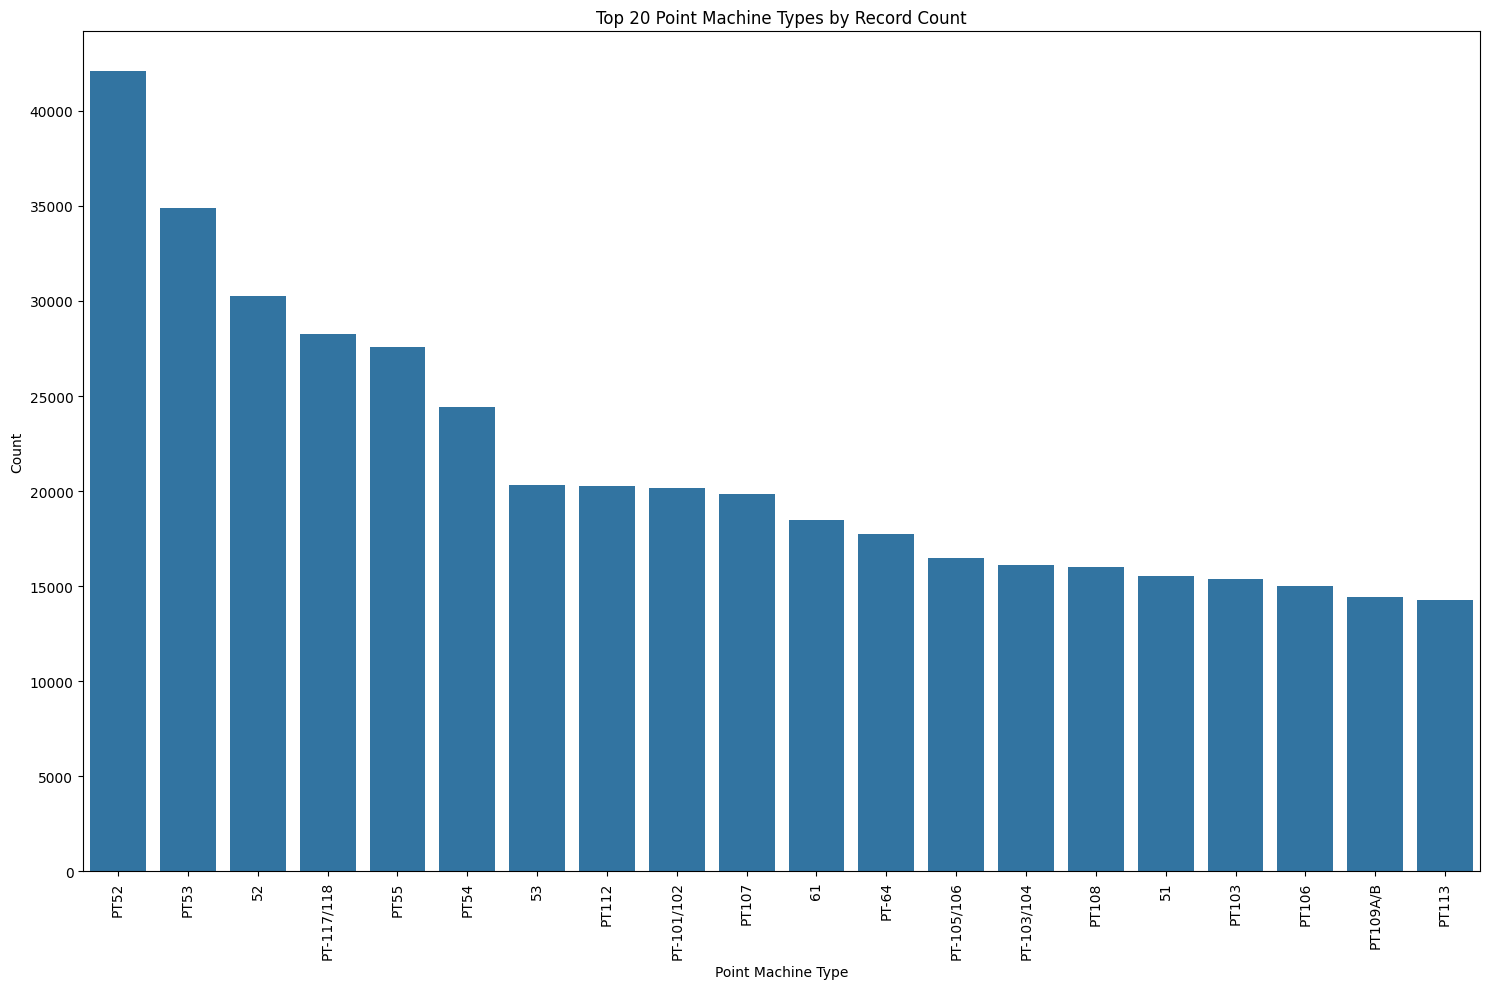

In [24]:
# Analyze direction distribution and point machine types
def analyze_categorical_features(datasets_dict):
    # Collect information
    direction_data = []
    point_machine_data = []
    zone_data = []
    
    for zone, df in datasets_dict.items():
        if 'direction' in df.columns:
            zone_directions = df['direction'].value_counts().to_dict()
            for direction, count in zone_directions.items():
                direction_data.append({
                    'zone': zone,
                    'direction': direction,
                    'count': count
                })
        
        if 'point_machine_name' in df.columns:
            zone_point_machines = df['point_machine_name'].value_counts().to_dict()
            for machine, count in zone_point_machines.items():
                point_machine_data.append({
                    'zone': zone,
                    'point_machine_name': machine,
                    'count': count
                })
                
        # Count overall zone records
        zone_data.append({
            'zone': zone,
            'count': len(df)
        })
    
    # Create dataframes
    direction_df = pd.DataFrame(direction_data)
    point_machine_df = pd.DataFrame(point_machine_data)
    zone_df = pd.DataFrame(zone_data)
    
    # Direction visualization
    plt.figure(figsize=(15, 10))
    
    # Overall direction distribution
    plt.subplot(2, 1, 1)
    direction_counts = direction_df.groupby('direction')['count'].sum().reset_index()
    sns.barplot(data=direction_counts, x='direction', y='count')
    plt.title('Overall Direction Distribution')
    plt.xlabel('Direction')
    plt.ylabel('Count')
    
    # Direction distribution by zone
    plt.subplot(2, 1, 2)
    # Get top 10 zones by count
    top_zones = zone_df.sort_values('count', ascending=False).head(10)['zone'].tolist()
    zone_direction_pivot = direction_df[direction_df['zone'].isin(top_zones)].pivot_table(
        index='zone', columns='direction', values='count', fill_value=0
    )
    zone_direction_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title('Direction Distribution by Zone (Top 10 Zones)')
    plt.xlabel('Zone')
    plt.ylabel('Count')
    plt.legend(title='Direction')
    
    plt.tight_layout()
    plt.show()
    
    # Point machine analysis
    # Get top 20 point machines by count
    top_machines = point_machine_df.groupby('point_machine_name')['count'].sum().sort_values(ascending=False).head(20)
    
    plt.figure(figsize=(15, 10))
    sns.barplot(x=top_machines.index, y=top_machines.values)
    plt.title('Top 20 Point Machine Types by Record Count')
    plt.xlabel('Point Machine Type')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Return dataframes for further analysis
    return {
        'direction_df': direction_df,
        'point_machine_df': point_machine_df,
        'zone_df': zone_df
    }

categorical_analysis = analyze_categorical_features(datasets)


# Missing Value Pattern Analysis

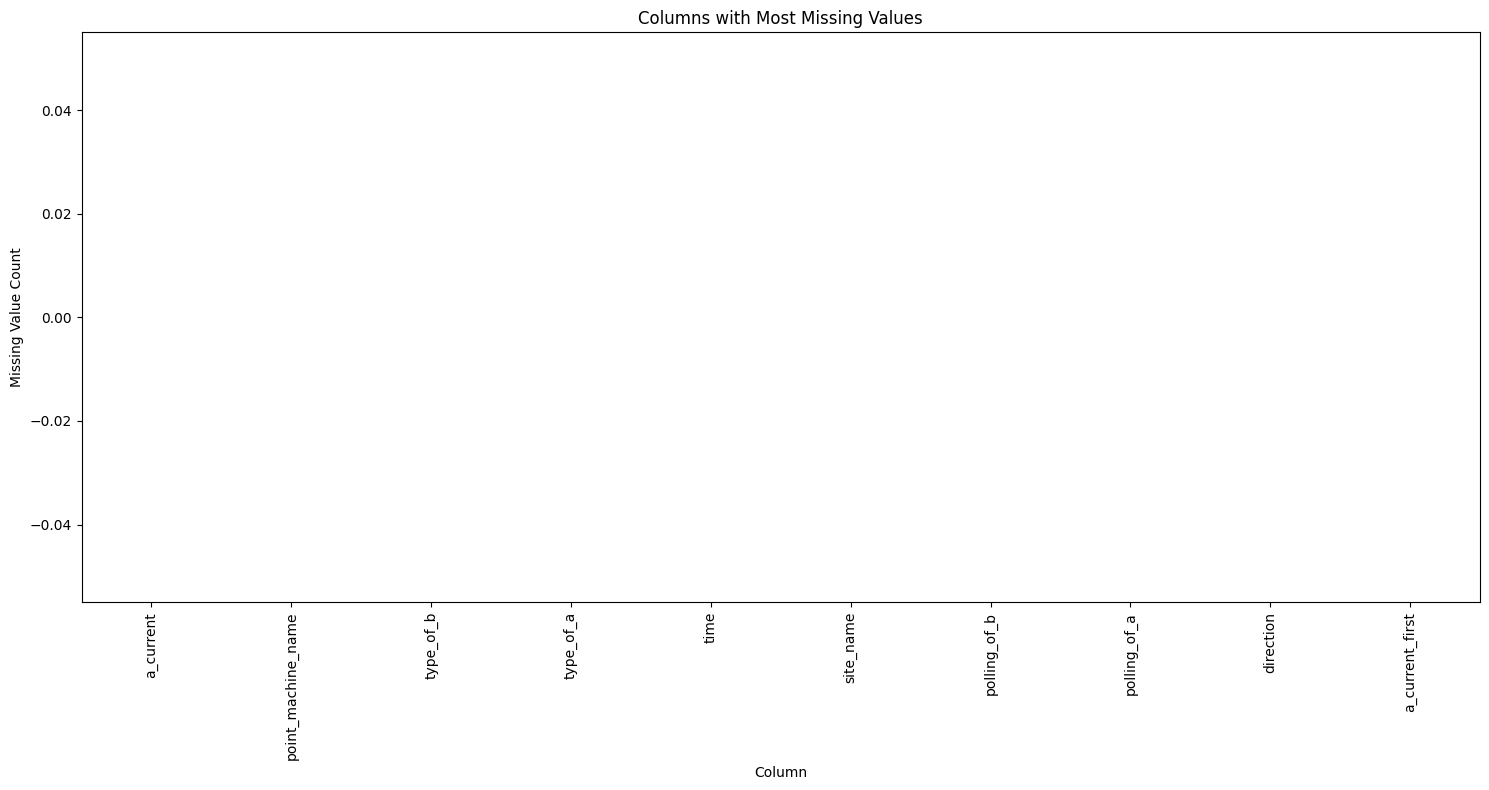

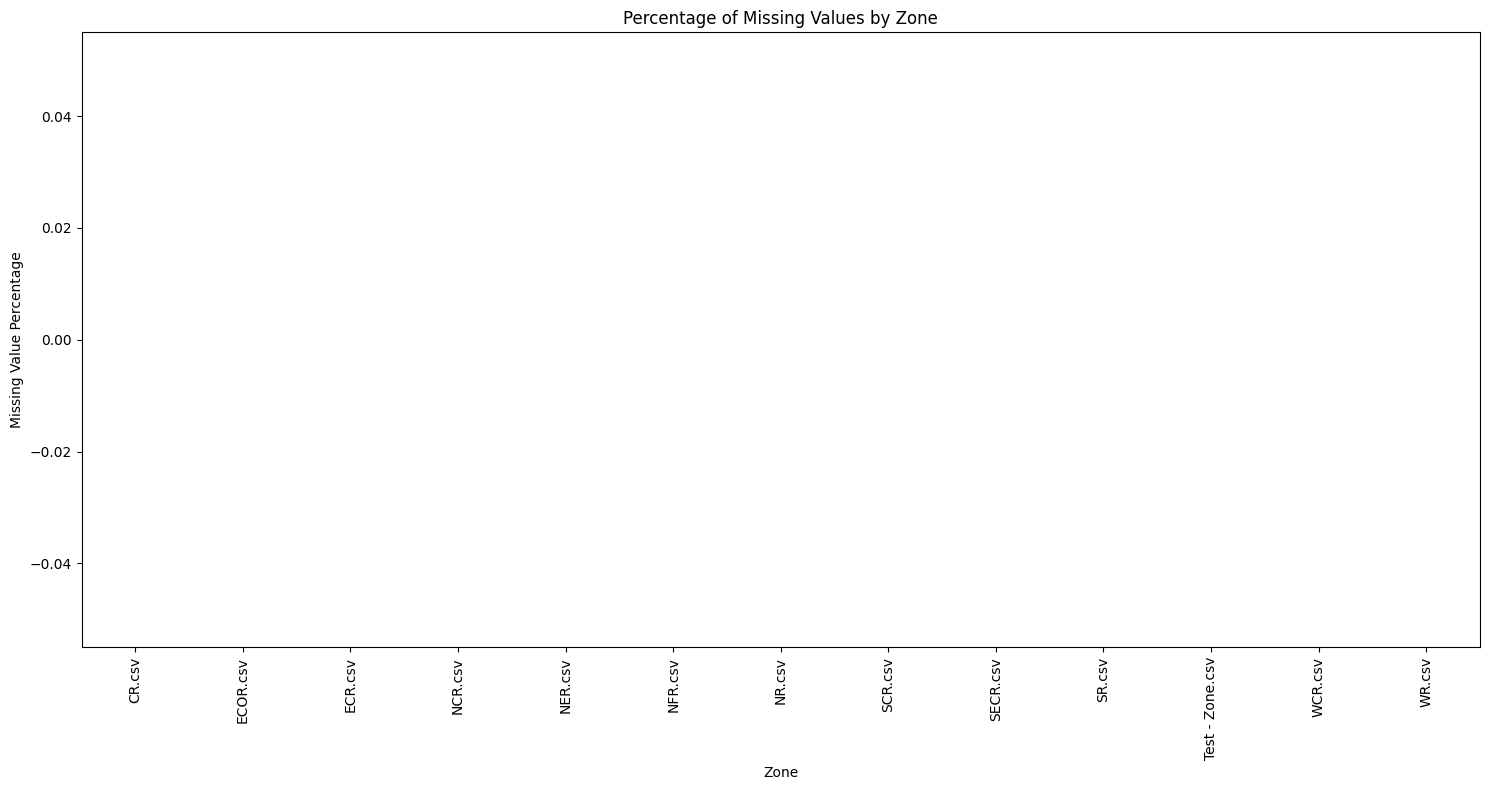

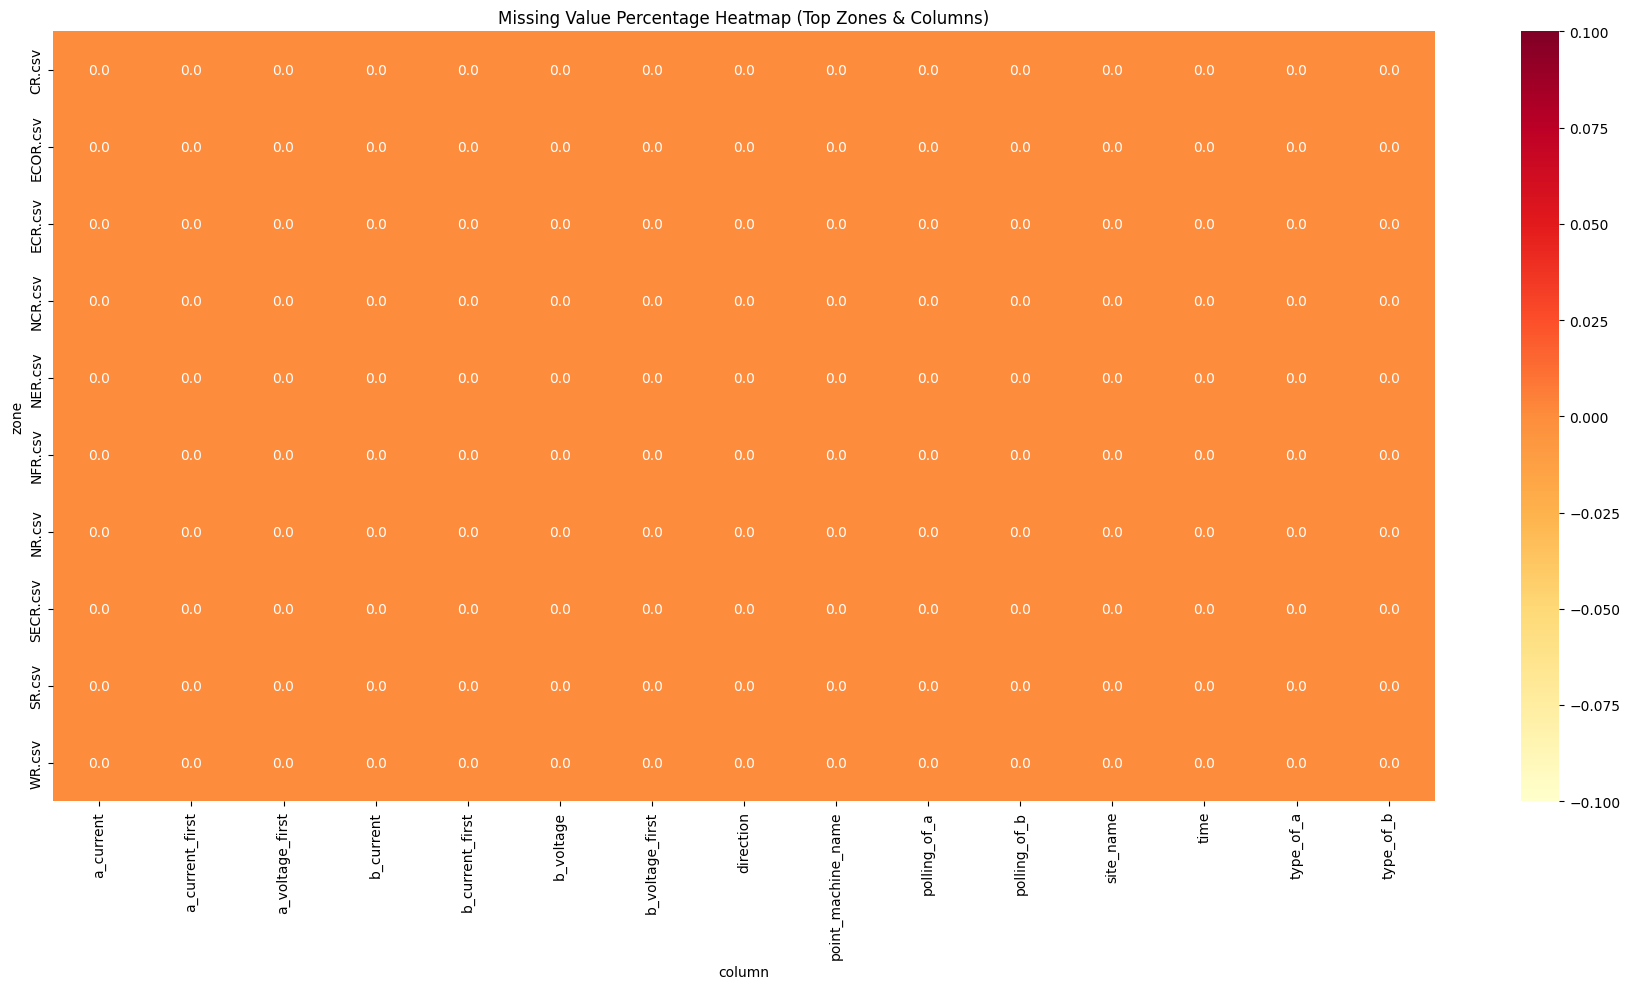

In [25]:
# Detailed missing value analysis
def analyze_missing_values(datasets_dict):
    # Track missing values per column per zone
    missing_data = []
    
    for zone, df in datasets_dict.items():
        missing_counts = df.isnull().sum()
        total_records = len(df)
        
        for column, missing_count in missing_counts.items():
            missing_percentage = (missing_count / total_records) * 100
            missing_data.append({
                'zone': zone,
                'column': column,
                'missing_count': missing_count,
                'missing_percentage': missing_percentage,
                'total_records': total_records
            })
    
    missing_df = pd.DataFrame(missing_data)
    
    # Visualize missing values
    plt.figure(figsize=(15, 8))
    
    # Get top columns with missing values
    column_missing = missing_df.groupby('column')['missing_count'].sum().sort_values(ascending=False).head(10)
    
    sns.barplot(x=column_missing.index, y=column_missing.values)
    plt.title('Columns with Most Missing Values')
    plt.xlabel('Column')
    plt.ylabel('Missing Value Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Missing values by zone
    plt.figure(figsize=(15, 8))
    zone_missing_totals = missing_df.groupby('zone')['missing_count'].sum().sort_values(ascending=False)
    zone_missing_percentages = zone_missing_totals / missing_df.groupby('zone')['total_records'].first()
    
    sns.barplot(x=zone_missing_percentages.index, y=zone_missing_percentages.values)
    plt.title('Percentage of Missing Values by Zone')
    plt.xlabel('Zone')
    plt.ylabel('Missing Value Percentage')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Missing value heatmap for top zones and columns
    plt.figure(figsize=(18, 10))
    
    # Get top 10 zones by record count
    top_zones = missing_df.groupby('zone')['total_records'].first().sort_values(ascending=False).head(10).index.tolist()
    
    # Get top 15 columns with most missing values
    top_columns = missing_df.groupby('column')['missing_count'].sum().sort_values(ascending=False).head(15).index.tolist()
    
    # Filter and pivot
    missing_heatmap = missing_df[
        (missing_df['zone'].isin(top_zones)) & 
        (missing_df['column'].isin(top_columns))
    ].pivot_table(
        index='zone', 
        columns='column', 
        values='missing_percentage',
        fill_value=0
    )
    
    sns.heatmap(missing_heatmap, annot=True, cmap='YlOrRd', fmt='.1f')
    plt.title('Missing Value Percentage Heatmap (Top Zones & Columns)')
    plt.tight_layout()
    plt.show()
    
    return missing_df

missing_analysis = analyze_missing_values(datasets)


# Outlier Detection

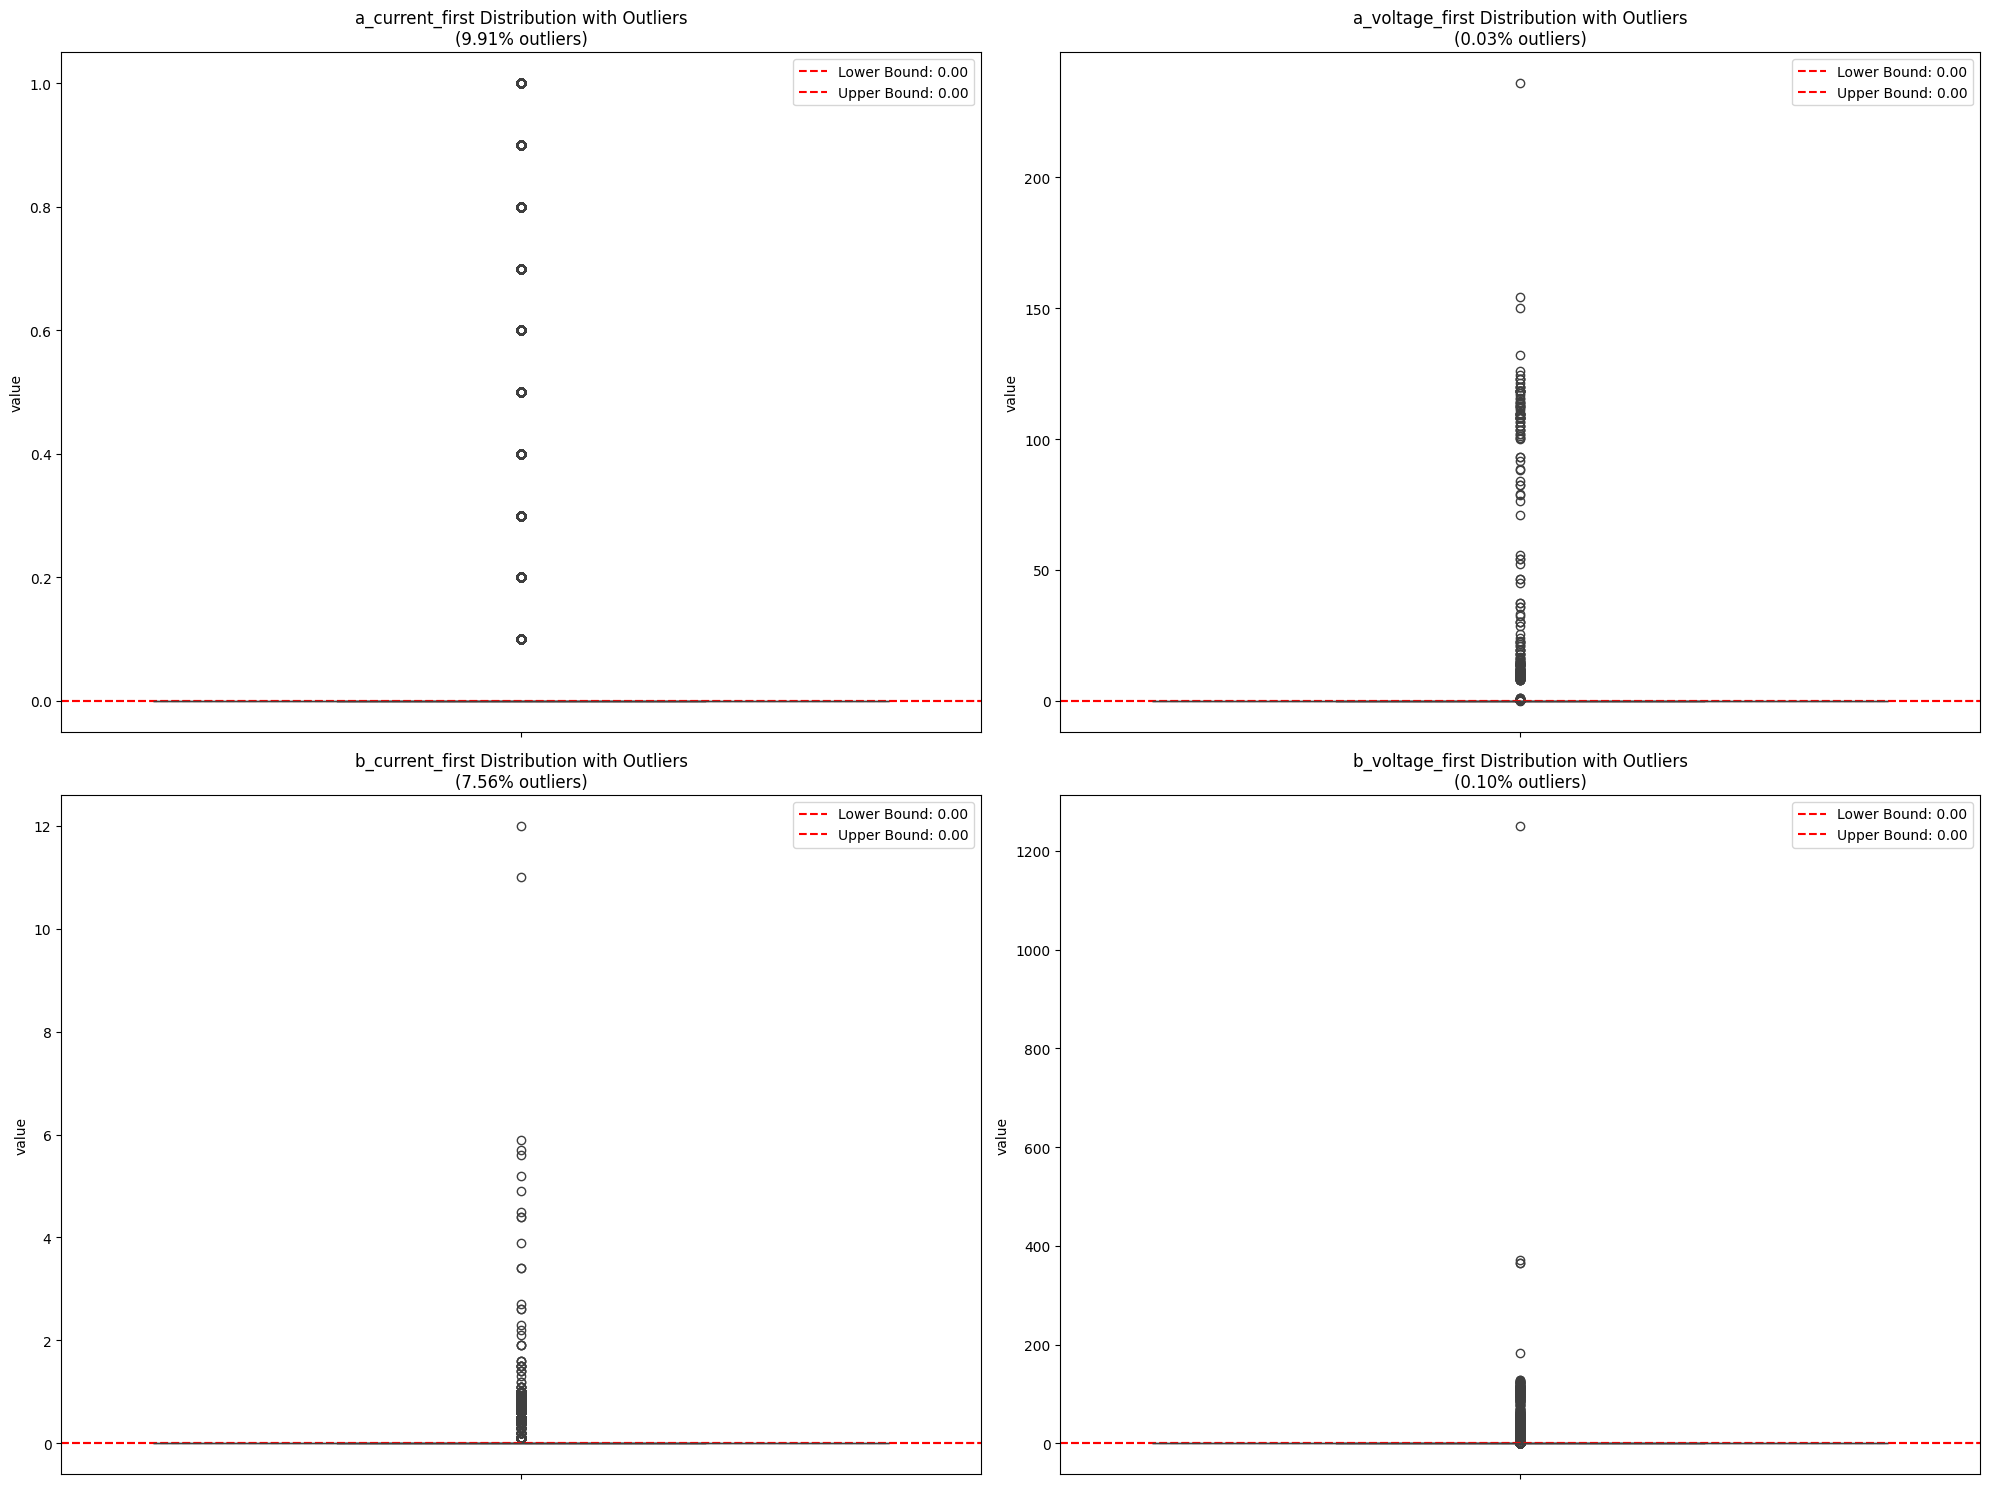

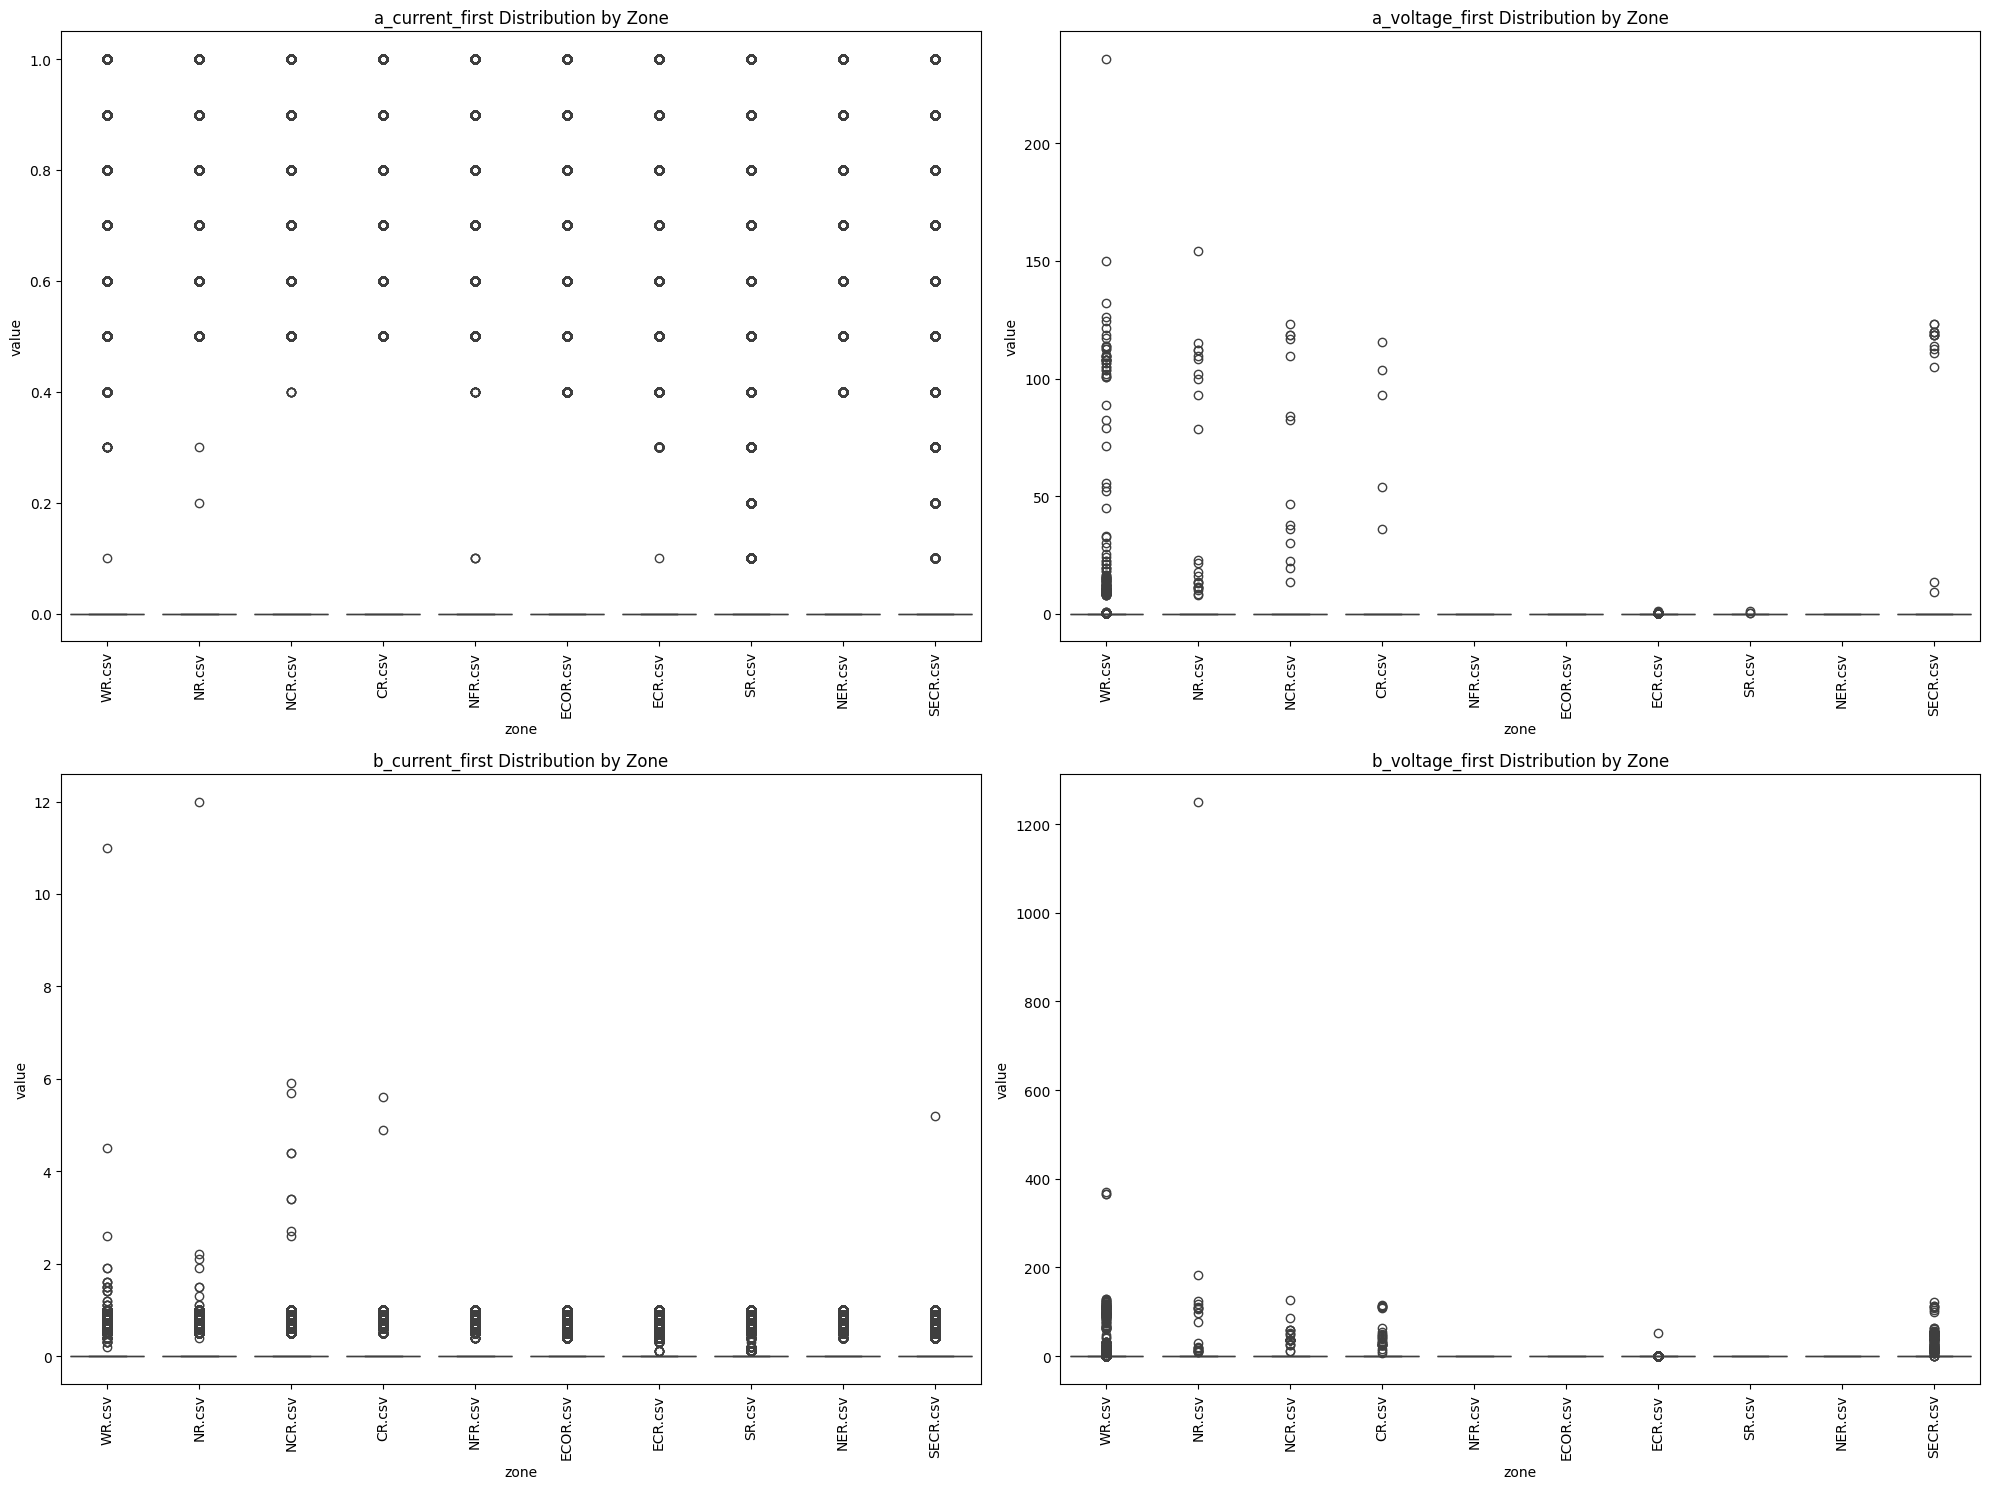

In [26]:
# Outlier detection and analysis
def analyze_outliers(datasets_dict):
    # Combine data for outlier analysis
    outlier_data = []
    
    for zone, df in datasets_dict.items():
        for col in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
            if col in df.columns:
                col_data = df[col].dropna().tolist()
                outlier_data.extend([
                    {'zone': zone, 'variable': col, 'value': val}
                    for val in col_data
                ])
    
    outlier_df = pd.DataFrame(outlier_data)
    
    # Calculate outlier boundaries
    outlier_stats = {}
    for var in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
        data = outlier_df[outlier_df['variable'] == var]['value']
        if not data.empty:
            q1 = data.quantile(0.25)
            q3 = data.quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            outlier_percent = (len(outliers) / len(data)) * 100
            
            outlier_stats[var] = {
                'q1': q1,
                'q3': q3,
                'iqr': iqr,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': len(outliers),
                'outlier_percent': outlier_percent
            }
    
    # Visualize outliers
    plt.figure(figsize=(20, 15))
    
    for i, var in enumerate(['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']):
        plt.subplot(2, 2, i+1)
        if var in outlier_stats:
            stats = outlier_stats[var]
            
            # Box plot with outliers
            sns.boxplot(data=outlier_df[outlier_df['variable'] == var], y='value')
            plt.title(f'{var} Distribution with Outliers\n({stats["outlier_percent"]:.2f}% outliers)')
            
            # Add annotations for bounds
            plt.axhline(stats['lower_bound'], color='r', linestyle='--', label=f'Lower Bound: {stats["lower_bound"]:.2f}')
            plt.axhline(stats['upper_bound'], color='r', linestyle='--', label=f'Upper Bound: {stats["upper_bound"]:.2f}')
            plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Visualize outliers by zone
    plt.figure(figsize=(20, 15))
    
    for i, var in enumerate(['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']):
        plt.subplot(2, 2, i+1)
        if var in outlier_stats:
            # Get top 10 zones by record count
            zone_counts = outlier_df.groupby('zone').size().sort_values(ascending=False).head(10).index
            
            # Box plot by zone
            var_data = outlier_df[outlier_df['variable'] == var]
            top_zones_data = var_data[var_data['zone'].isin(zone_counts)]
            
            sns.boxplot(data=top_zones_data, x='zone', y='value')
            plt.title(f'{var} Distribution by Zone')
            plt.xticks(rotation=90)
    
    plt.tight_layout()
    plt.show()
    
    # Return outlier information
    return {
        'outlier_df': outlier_df,
        'outlier_stats': outlier_stats
    }

outlier_analysis = analyze_outliers(datasets)


# Advance Feature Analysis

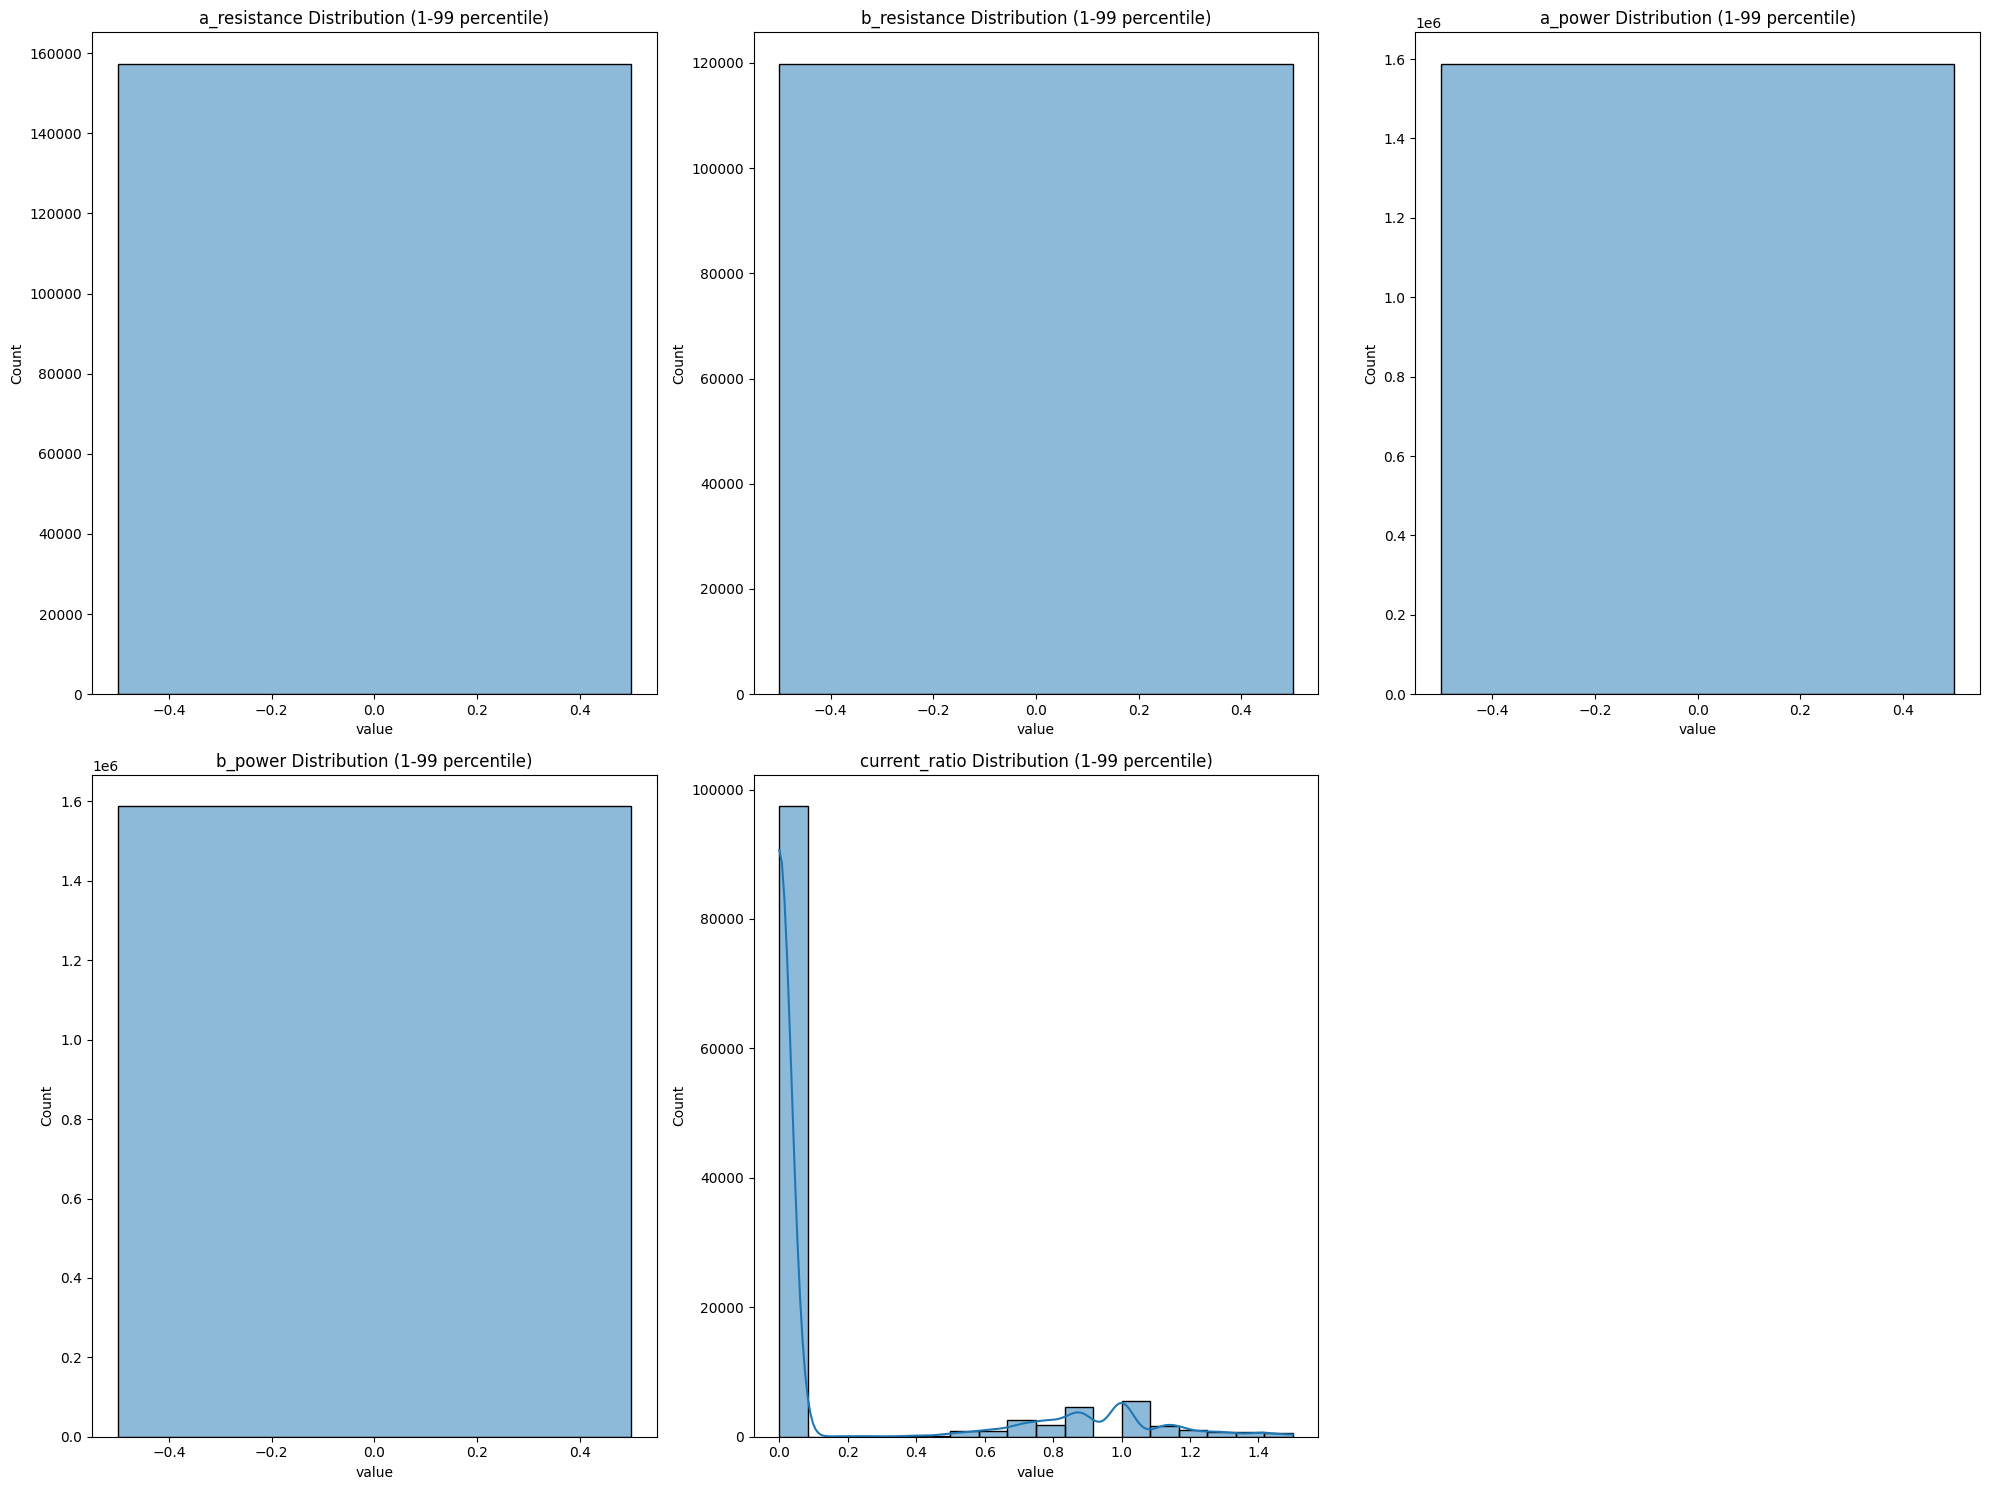

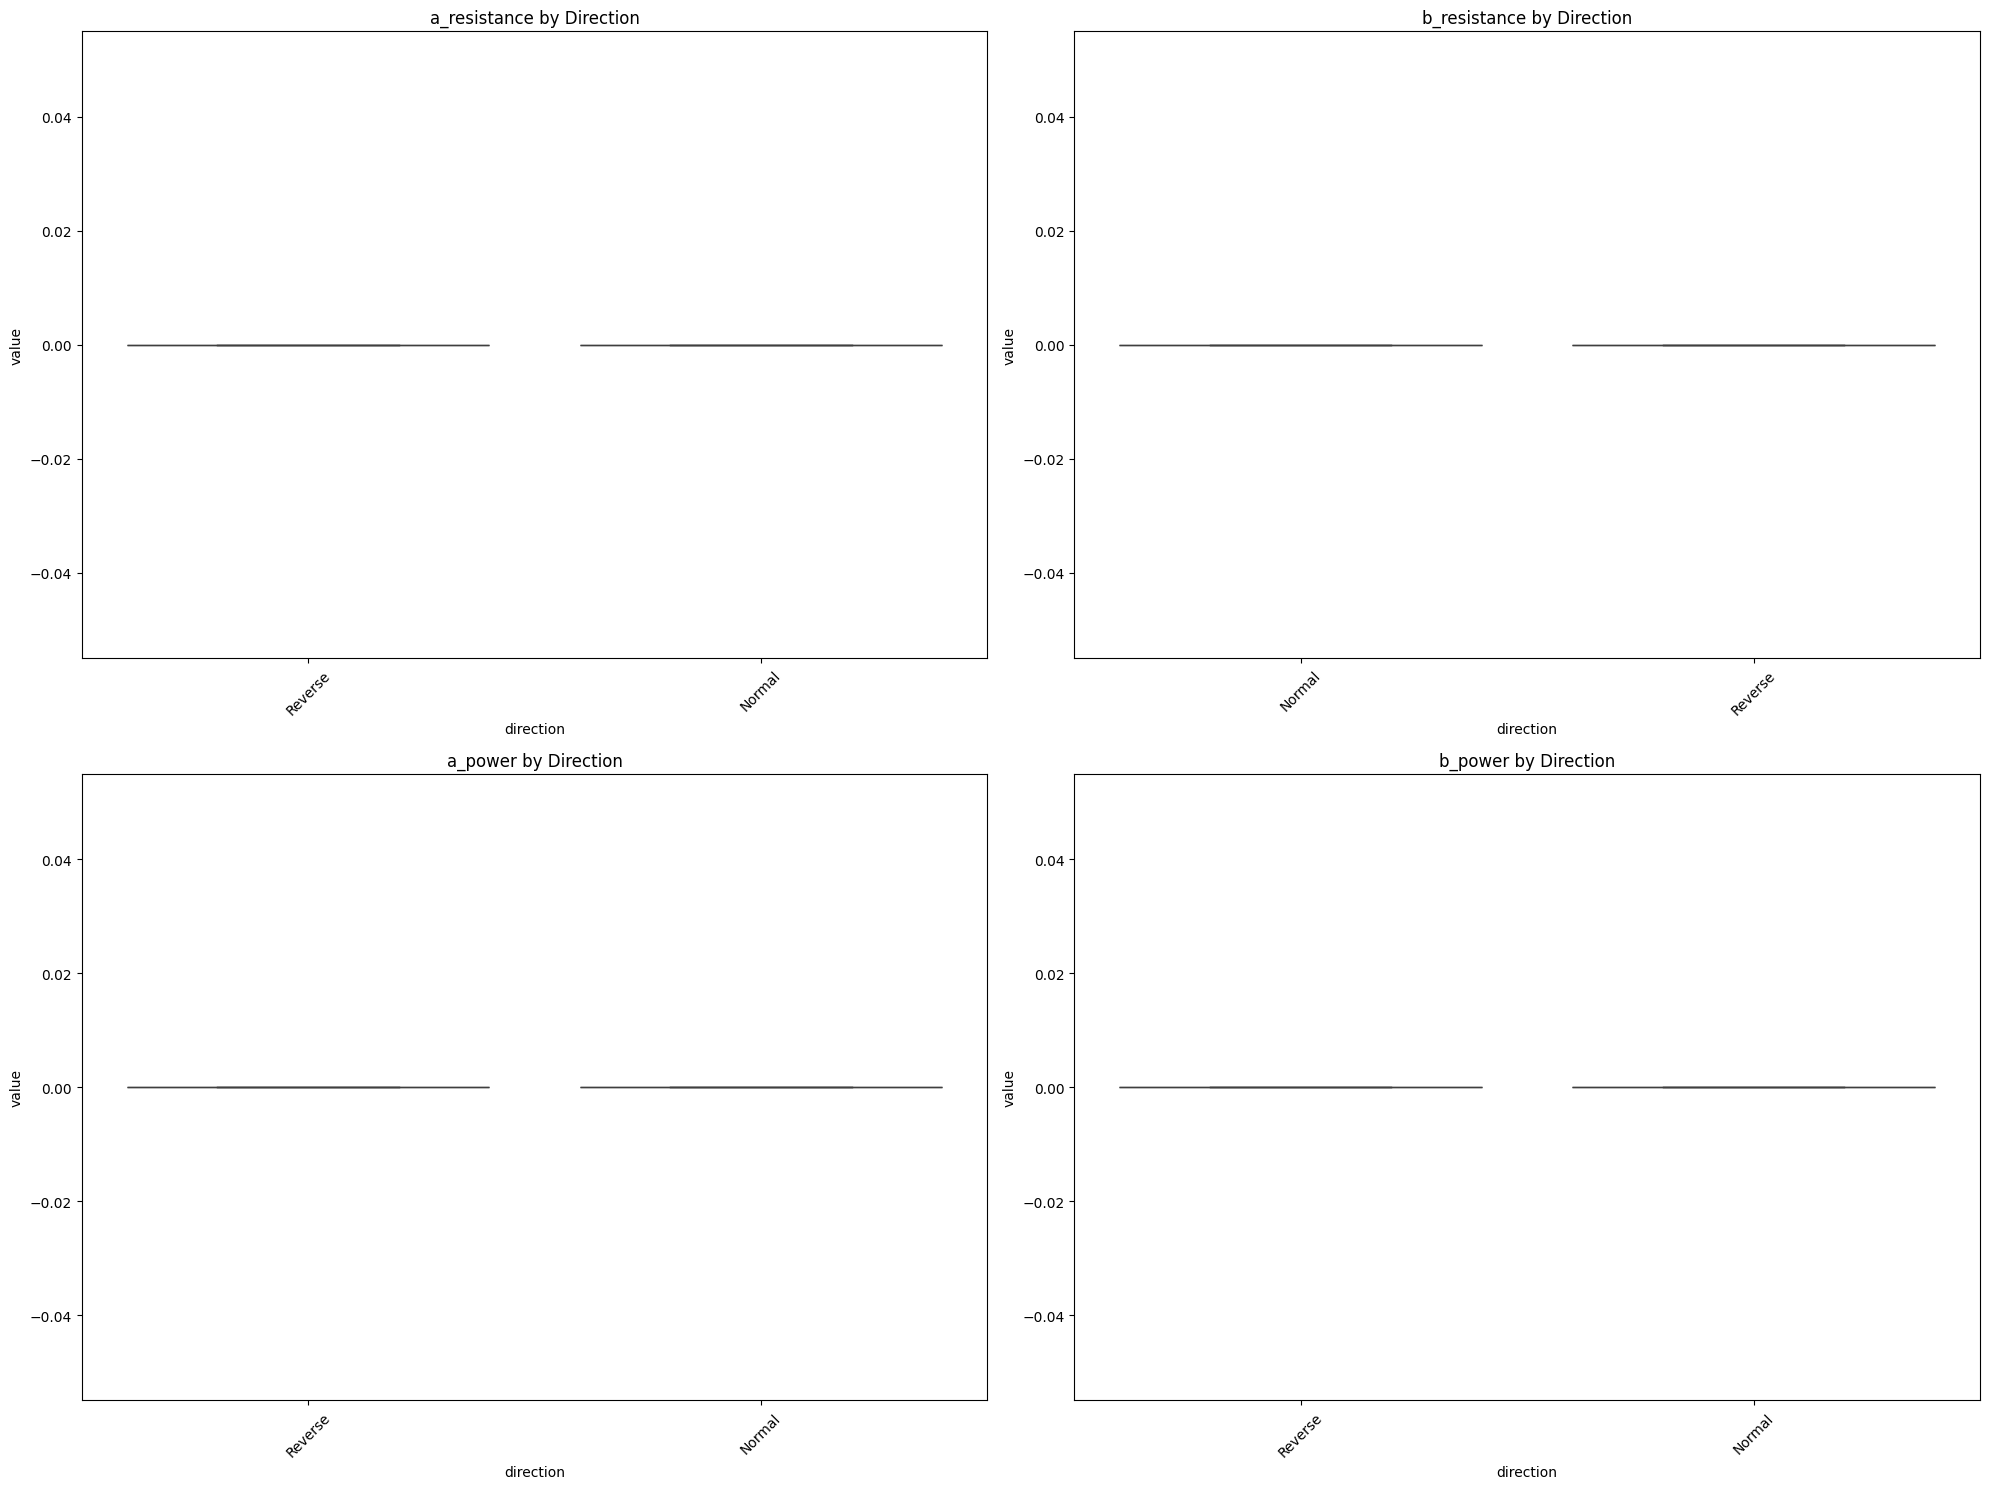

In [27]:
# Advanced feature engineering and analysis
def perform_advanced_analysis(datasets_dict):
    # Create advanced features
    for zone, df in datasets_dict.items():
        # Current-voltage ratio (resistance-like measurement)
        if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
            df['a_resistance'] = df['a_voltage_first'] / df['a_current_first'].replace(0, np.nan)
        
        if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
            df['b_resistance'] = df['b_voltage_first'] / df['b_current_first'].replace(0, np.nan)
        
        # Power-like measurements
        if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
            df['a_power'] = df['a_current_first'] * df['a_voltage_first']
            
        if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
            df['b_power'] = df['b_current_first'] * df['b_voltage_first']
            
        # Current ratio A/B
        if all(col in df.columns for col in ['a_current_first', 'b_current_first']):
            df['current_ratio'] = df['a_current_first'] / df['b_current_first'].replace(0, np.nan)
    
    # Combine data for analysis
    advanced_data = []
    
    for zone, df in datasets_dict.items():
        for col in ['a_resistance', 'b_resistance', 'a_power', 'b_power', 'current_ratio']:
            if col in df.columns:
                col_data = df[col].dropna().tolist()
                advanced_data.extend([
                    {'zone': zone, 'variable': col, 'value': val, 'direction': dir_val}
                    for val, dir_val in zip(col_data, df.loc[df[col].notna(), 'direction'].tolist())
                    if not np.isinf(val) and not np.isnan(val)
                ])
    
    # Create dataframe
    advanced_df = pd.DataFrame(advanced_data)
    
    # Visualize advanced features
    if not advanced_df.empty:
        plt.figure(figsize=(20, 15))
        
        for i, var in enumerate(['a_resistance', 'b_resistance', 'a_power', 'b_power', 'current_ratio']):
            var_data = advanced_df[advanced_df['variable'] == var]
            
            if not var_data.empty:
                plt.subplot(2, 3, i+1)
                # Remove extreme outliers for better visualization
                q1 = var_data['value'].quantile(0.01)
                q3 = var_data['value'].quantile(0.99)
                filtered_data = var_data[(var_data['value'] >= q1) & (var_data['value'] <= q3)]
                
                sns.histplot(data=filtered_data, x='value', kde=True)
                plt.title(f'{var} Distribution (1-99 percentile)')
        
        plt.tight_layout()
        plt.show()
        
        # Direction-based analysis for advanced features
        plt.figure(figsize=(20, 15))
        
        for i, var in enumerate(['a_resistance', 'b_resistance', 'a_power', 'b_power']):
            var_data = advanced_df[advanced_df['variable'] == var]
            
            if not var_data.empty:
                plt.subplot(2, 2, i+1)
                # Remove extreme outliers for better visualization
                q1 = var_data['value'].quantile(0.01)
                q3 = var_data['value'].quantile(0.99)
                filtered_data = var_data[(var_data['value'] >= q1) & (var_data['value'] <= q3)]
                
                sns.boxplot(data=filtered_data, x='direction', y='value')
                plt.title(f'{var} by Direction')
                plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'advanced_df': advanced_df,
        'datasets': datasets_dict  # Return the updated datasets
    }

advanced_analysis = perform_advanced_analysis(datasets)


# Statistical Insights

STATISTICAL INSIGHTS
--------------------

Overall Statistics:

A_CURRENT_FIRST:
  Mean: 0.09
  Std: 0.23
  Range: 0.00 to 1.00
  Count: 1,587,859

A_VOLTAGE_FIRST:
  Mean: 0.01
  Std: 0.55
  Range: 0.00 to 235.90
  Count: 1,587,859

B_CURRENT_FIRST:
  Mean: 0.07
  Std: 0.21
  Range: 0.00 to 12.00
  Count: 1,587,859

B_VOLTAGE_FIRST:
  Mean: 0.02
  Std: 1.02
  Range: 0.00 to 1250.80
  Count: 1,587,859

A_CURRENT_FIRST - Zone Comparison:
  Zone with lowest mean: NCR.csv (0.03)
  Zone with highest mean: SCR.csv (0.21)
  Ratio: 7.27x

A_VOLTAGE_FIRST - Zone Comparison:
  Zone with lowest mean: SCR.csv (0.00)
  Zone with highest mean: NR.csv (0.02)
  Ratio: infx

B_CURRENT_FIRST - Zone Comparison:
  Zone with lowest mean: CR.csv (0.01)
  Zone with highest mean: SCR.csv (0.21)
  Ratio: 22.84x

B_VOLTAGE_FIRST - Zone Comparison:
  Zone with lowest mean: SCR.csv (0.00)
  Zone with highest mean: NR.csv (0.05)
  Ratio: infx

Potentially Anomalous Zones (|Z-score| > 2):

A_CURRENT_FIRST:
  SCR.c

/tmp/ipykernel_154680/538893696.py:57: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Ratio: {highest_zone['mean']/lowest_zone['mean']:.2f}x")


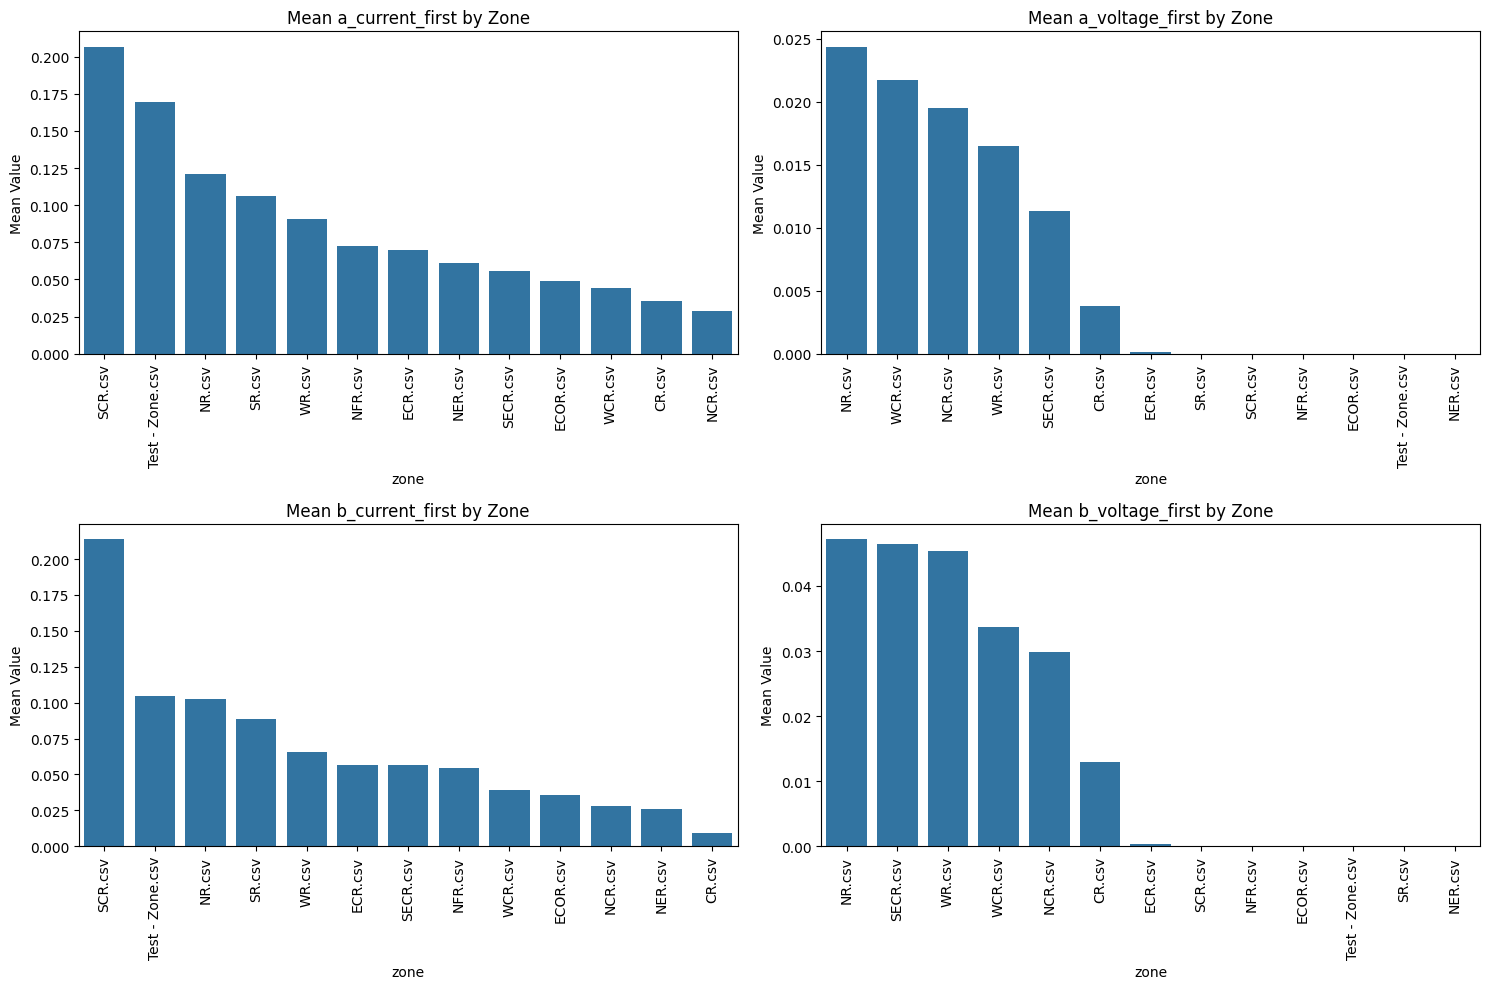

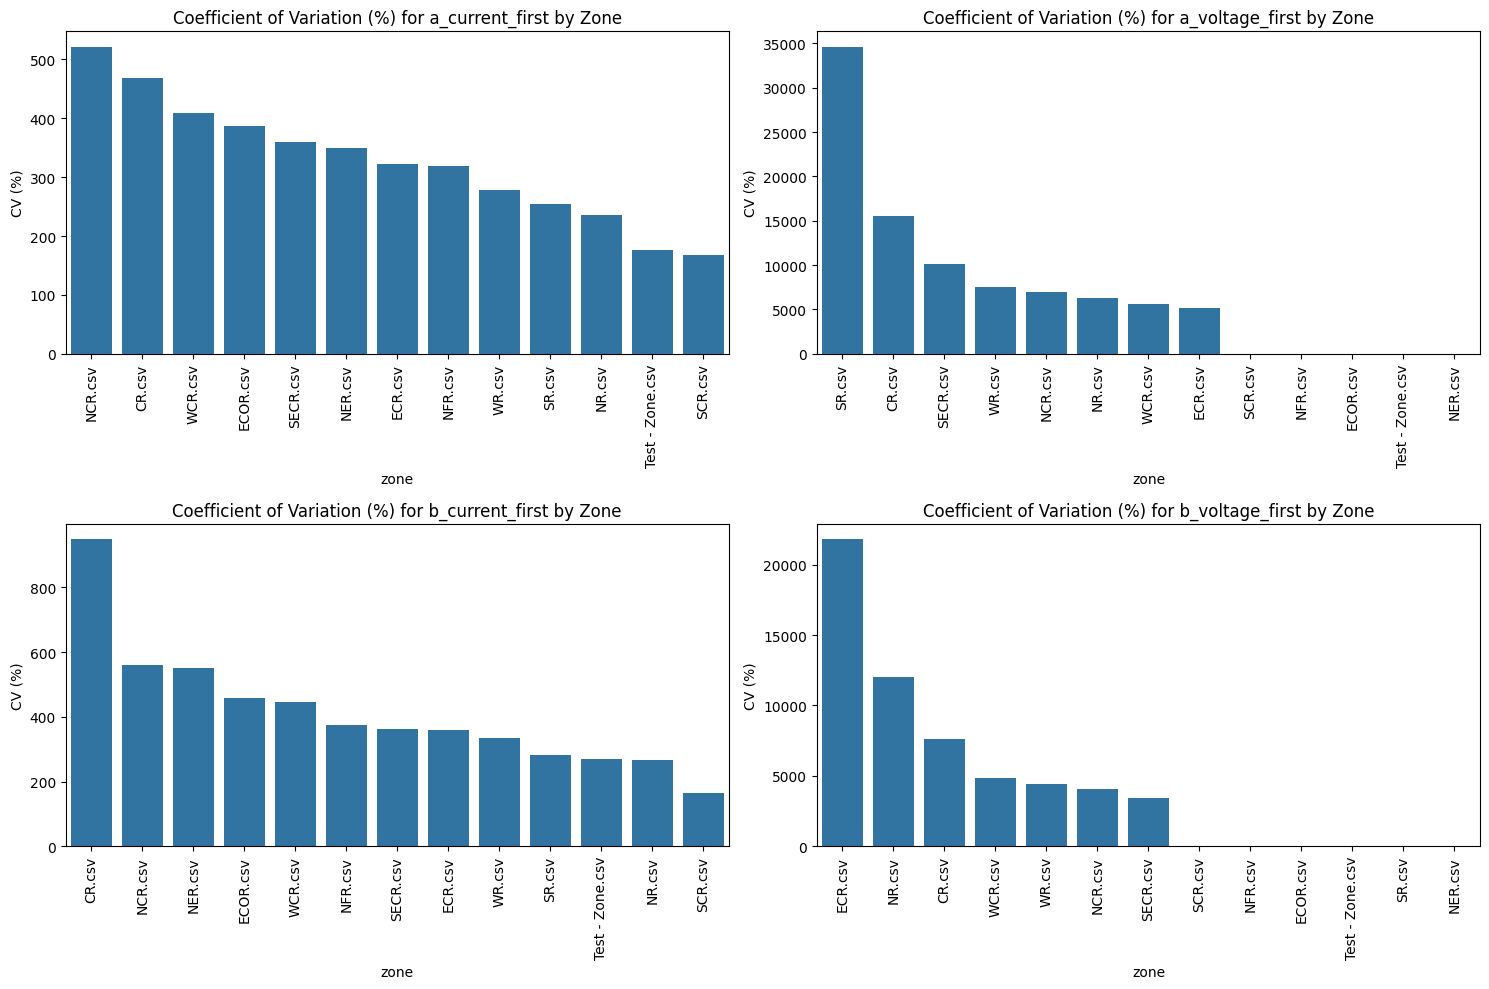

In [28]:
# Statistical analysis and insights
def extract_statistical_insights(datasets_dict):
    # Collect statistics by zone and overall
    stats_data = []
    
    for zone, df in datasets_dict.items():
        for col in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
            if col in df.columns:
                col_stats = df[col].describe()
                
                stats_data.append({
                    'zone': zone,
                    'variable': col,
                    'mean': col_stats['mean'],
                    'std': col_stats['std'],
                    'min': col_stats['min'],
                    'q1': col_stats['25%'],
                    'median': col_stats['50%'],
                    'q3': col_stats['75%'],
                    'max': col_stats['max'],
                    'count': col_stats['count']
                })
    
    stats_df = pd.DataFrame(stats_data)
    
    # Calculate overall statistics
    overall_stats = stats_df.groupby('variable').agg({
        'mean': 'mean',
        'std': 'mean',
        'min': 'min',
        'max': 'max',
        'count': 'sum'
    }).reset_index()
    
    # Print overall statistical insights
    print("STATISTICAL INSIGHTS")
    print("--------------------")
    print("\nOverall Statistics:")
    for _, row in overall_stats.iterrows():
        print(f"\n{row['variable'].upper()}:")
        print(f"  Mean: {row['mean']:.2f}")
        print(f"  Std: {row['std']:.2f}")
        print(f"  Range: {row['min']:.2f} to {row['max']:.2f}")
        print(f"  Count: {int(row['count']):,}")
    
    # Find zones with highest/lowest averages
    for var in stats_df['variable'].unique():
        var_stats = stats_df[stats_df['variable'] == var].sort_values('mean')
        
        if not var_stats.empty:
            lowest_zone = var_stats.iloc[0]
            highest_zone = var_stats.iloc[-1]
            
            print(f"\n{var.upper()} - Zone Comparison:")
            print(f"  Zone with lowest mean: {lowest_zone['zone']} ({lowest_zone['mean']:.2f})")
            print(f"  Zone with highest mean: {highest_zone['zone']} ({highest_zone['mean']:.2f})")
            print(f"  Ratio: {highest_zone['mean']/lowest_zone['mean']:.2f}x")
    
    # Identify potentially anomalous zones
    z_scores = {}
    for var in stats_df['variable'].unique():
        var_data = stats_df[stats_df['variable'] == var]
        
        if len(var_data) > 1:
            mean = var_data['mean'].mean()
            std = var_data['mean'].std()
            
            if std > 0:
                z_scores[var] = {}
                for _, row in var_data.iterrows():
                    z = (row['mean'] - mean) / std
                    z_scores[var][row['zone']] = z
    
    # Print anomalous zones
    print("\nPotentially Anomalous Zones (|Z-score| > 2):")
    for var, scores in z_scores.items():
        anomalies = {zone: z for zone, z in scores.items() if abs(z) > 2}
        
        if anomalies:
            print(f"\n{var.upper()}:")
            for zone, z in anomalies.items():
                print(f"  {zone}: Z-score = {z:.2f}")
    
    # Create comparison visualizations
    plt.figure(figsize=(15, 10))
    
    # Compare mean values across zones
    for i, var in enumerate(['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']):
        var_data = stats_df[stats_df['variable'] == var]
        
        if not var_data.empty:
            plt.subplot(2, 2, i+1)
            
            # Sort by mean
            var_data = var_data.sort_values('mean', ascending=False)
            
            sns.barplot(data=var_data, x='zone', y='mean')
            plt.title(f'Mean {var} by Zone')
            plt.xticks(rotation=90)
            plt.ylabel('Mean Value')
    
    plt.tight_layout()
    plt.show()
    
    # Coefficient of variation analysis
    plt.figure(figsize=(15, 10))
    
    # Calculate coefficient of variation (CV)
    stats_df['cv'] = stats_df['std'] / stats_df['mean'] * 100  # CV as percentage
    
    for i, var in enumerate(['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']):
        var_data = stats_df[stats_df['variable'] == var]
        
        if not var_data.empty:
            plt.subplot(2, 2, i+1)
            
            # Sort by CV
            var_data = var_data.sort_values('cv', ascending=False)
            
            sns.barplot(data=var_data, x='zone', y='cv')
            plt.title(f'Coefficient of Variation (%) for {var} by Zone')
            plt.xticks(rotation=90)
            plt.ylabel('CV (%)')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'stats_df': stats_df,
        'overall_stats': overall_stats,
        'z_scores': z_scores
    }

statistical_insights = extract_statistical_insights(datasets)


# Data Quality Assessment and Recommendations

In [29]:
# Data quality assessment and recommendations
def assess_data_quality(datasets_dict, missing_analysis, outlier_analysis, statistical_insights):
    # Calculate general quality metrics
    total_records = sum(len(df) for df in datasets_dict.values())
    zone_count = len(datasets_dict)
    
    # Assess completeness
    missing_counts = missing_analysis.groupby('column')['missing_count'].sum()
    total_cells = sum(len(df.columns) * len(df) for df in datasets_dict.values())
    overall_missing_percentage = missing_counts.sum() / total_cells * 100
    
    # Assess outliers
    outlier_percentages = {var: stats['outlier_percent'] 
                          for var, stats in outlier_analysis['outlier_stats'].items() 
                          if 'outlier_percent' in stats}
    avg_outlier_percentage = sum(outlier_percentages.values()) / len(outlier_percentages) if outlier_percentages else 0
    
    # Find columns with high missing percentages
    high_missing_cols = missing_analysis.groupby('column')['missing_count'].sum()
    high_missing_cols = high_missing_cols[high_missing_cols / total_records * 100 > 20]
    
    # Calculate zone consistency
    zone_consistencies = {}
    for var in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
        var_stats = statistical_insights['stats_df'][statistical_insights['stats_df']['variable'] == var]
        if len(var_stats) > 1:
            mean_values = var_stats['mean']
            consistency = 1 - (mean_values.std() / mean_values.mean())
            zone_consistencies[var] = consistency * 100  # as percentage
    
    # Print quality assessment
    print("DATA QUALITY ASSESSMENT")
    print("----------------------")
    print(f"\nTotal Records: {total_records:,}")
    print(f"Number of Zones: {zone_count}")
    print(f"Overall Missing Data: {overall_missing_percentage:.2f}%")
    print(f"Average Outlier Percentage: {avg_outlier_percentage:.2f}%")
    
    # Print high missing columns
    if not high_missing_cols.empty:
        print("\nColumns with >20% Missing Values:")
        for col, count in high_missing_cols.items():
            print(f"  {col}: {count/total_records*100:.2f}%")
    
    # Print zone consistency
    print("\nCross-Zone Data Consistency (higher % is more consistent):")
    for var, consistency in zone_consistencies.items():
        quality = "Good" if consistency > 90 else "Moderate" if consistency > 70 else "Poor"
        print(f"  {var}: {consistency:.2f}% ({quality})")
    
    # Overall quality score (simple heuristic)
    completeness_score = max(0, 100 - overall_missing_percentage)
    outlier_score = max(0, 100 - avg_outlier_percentage)
    consistency_score = sum(zone_consistencies.values()) / len(zone_consistencies) if zone_consistencies else 0
    
    overall_quality = (completeness_score * 0.4 + outlier_score * 0.3 + consistency_score * 0.3) / 100
    
    quality_category = "Excellent" if overall_quality > 0.9 else \
                      "Good" if overall_quality > 0.8 else \
                      "Satisfactory" if overall_quality > 0.7 else \
                      "Fair" if overall_quality > 0.6 else \
                      "Poor"
    
    print(f"\nOverall Data Quality Score: {overall_quality:.2f} ({quality_category})")
    
    # Recommendations
    print("\nRECOMMENDATIONS:")
    
    # Missing data recommendations
    if overall_missing_percentage > 10:
        print("\n1. Missing Data Issues:")
        print("   - Consider imputation strategies for high-missing columns")
        print("   - Investigate why certain zones have higher missing percentages")
        if high_missing_cols.empty:
            print("   - No columns have critically high missing values")
        else:
            print(f"   - Consider dropping columns with high missing values: {', '.join(high_missing_cols.index)}")
    
    # Outlier recommendations
    if avg_outlier_percentage > 5:
        print("\n2. Outlier Handling:")
        print("   - Implement outlier capping or removal before analysis")
        high_outlier_vars = [var for var, pct in outlier_percentages.items() if pct > 10]
        if high_outlier_vars:
            print(f"   - Pay special attention to variables with many outliers: {', '.join(high_outlier_vars)}")
    
    # Zone consistency recommendations
    low_consistency_vars = [var for var, cons in zone_consistencies.items() if cons < 70]
    if low_consistency_vars:
        print("\n3. Zone Consistency Issues:")
        print(f"   - Investigate why these variables show high variance across zones: {', '.join(low_consistency_vars)}")
        print("   - Consider normalizing data within each zone before cross-zone analysis")
    
    # Feature engineering recommendations
    print("\n4. Feature Engineering Suggestions:")
    print("   - Create aggregated statistical features (min, max, mean) from array columns")
    print("   - Consider calculating rate-of-change features if timestamps are available")
    print("   - Develop categorical features from continuous measurements (e.g., voltage ranges)")
    
    # Final data preparation recommendations
    print("\n5. Final Data Preparation:")
    print("   - Standardize all numerical features")
    print("   - One-hot encode categorical variables")
    print("   - Consider dimensionality reduction if using many features")
    
    return {
        'completeness_score': completeness_score,
        'outlier_score': outlier_score,
        'consistency_score': consistency_score,
        'overall_quality': overall_quality,
        'quality_category': quality_category
    }

quality_assessment = assess_data_quality(datasets, missing_analysis, outlier_analysis, statistical_insights)


DATA QUALITY ASSESSMENT
----------------------

Total Records: 1,587,859
Number of Zones: 13
Overall Missing Data: 0.00%
Average Outlier Percentage: 4.40%

Cross-Zone Data Consistency (higher % is more consistent):
  a_current_first: 37.52% (Poor)
  a_voltage_first: -29.61% (Poor)
  b_current_first: 22.10% (Poor)
  b_voltage_first: -23.60% (Poor)

Overall Data Quality Score: 0.69 (Fair)

RECOMMENDATIONS:

3. Zone Consistency Issues:
   - Investigate why these variables show high variance across zones: a_current_first, a_voltage_first, b_current_first, b_voltage_first
   - Consider normalizing data within each zone before cross-zone analysis

4. Feature Engineering Suggestions:
   - Create aggregated statistical features (min, max, mean) from array columns
   - Consider calculating rate-of-change features if timestamps are available
   - Develop categorical features from continuous measurements (e.g., voltage ranges)

5. Final Data Preparation:
   - Standardize all numerical features
  

This comprehensive EDA has provided valuable insights into the railway zone dataset:

    Data Volume and Distribution: We analyzed the distribution of records across zones, identifying which zones have the most data.

    Temporal Patterns: We explored the distribution of records over time, revealing patterns in data collection frequency.

    Electrical Measurements: We conducted in-depth analysis of the current and voltage readings, their distributions, and relationships.

    Categorical Variables: We analyzed the distribution of directions and point machine types across different zones.

    Missing Values: We identified patterns in missing data and highlighted problematic zones or columns.

    Outliers: We detected and analyzed outliers in the electrical measurements, providing insights into data quality.

    Advanced Features: We created and analyzed derived features that could provide additional insights for modeling.

    Statistical Insights: We extracted key statistical patterns and identified zones with anomalous behavior.

    Data Quality Assessment: We evaluated the overall quality of the dataset and provided recommendations for improvement.


In [32]:
# Advanced Data Processing and Enhancement for Railway Zone Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from datetime import datetime, timedelta
import os
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set the style for more fancy visualizations
plt.style.use('ggplot')
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("deep")


# Improving Data Quality further

In [33]:
# Function to enhance the dataset with advanced processing
def enhance_dataset(datasets_dict):
    """
    Perform advanced data processing and enhancement on the railway dataset
    """
    print("🚂 Starting advanced data processing...")
    
    # Create a copy of the datasets to avoid modifying originals
    enhanced_datasets = {}
    
    for zone_name, df in tqdm(datasets_dict.items(), desc="Processing Zones"):
        # Create a deep copy to avoid modifying the original
        enhanced_df = df.copy(deep=True)
        
        # 1. Advanced missing value handling
        enhanced_df = handle_missing_values(enhanced_df)
        
        # 2. Feature engineering
        enhanced_df = engineer_features(enhanced_df)
        
        # 3. Add zone as a feature (already exists but let's make sure)
        if 'zone' not in enhanced_df.columns:
            enhanced_df['zone'] = zone_name.replace('.csv', '')
        
        # Store the enhanced dataframe
        enhanced_datasets[zone_name] = enhanced_df
    
    # Consolidate all datasets into one
    print("🔄 Consolidating datasets...")
    consolidated_df = pd.concat(enhanced_datasets.values(), ignore_index=True)
    
    # Further processing on the consolidated dataset
    print("📊 Performing final processing steps...")
    
    # 4. Standardize/normalize numerical features
    consolidated_df = normalize_features(consolidated_df)
    
    # 5. Identify and handle outliers
    consolidated_df = handle_outliers(consolidated_df)
    
    # 6. Encode categorical variables
    consolidated_df = encode_categorical_variables(consolidated_df)
    
    print("✅ Advanced data processing complete!")
    
    return consolidated_df, enhanced_datasets

def handle_missing_values(df):
    """
    Advanced handling of missing values based on feature type and distribution
    """
    # Handle electrical measurement missing values more intelligently
    for col in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']:
        if col in df.columns:
            # If majority of values are missing, drop the column
            if df[col].isna().mean() > 0.8:
                df = df.drop(col, axis=1)
            else:
                # For electrical measurements, we'll impute with the median grouped by direction and type
                # Group by direction if it exists
                if 'direction' in df.columns:
                    df[col] = df.groupby('direction')[col].transform(lambda x: x.fillna(x.median()))
                
                # Group by type if it exists
                if col.startswith('a_') and 'type_of_a' in df.columns:
                    df[col] = df.groupby('type_of_a')[col].transform(lambda x: x.fillna(x.median()))
                elif col.startswith('b_') and 'type_of_b' in df.columns:
                    df[col] = df.groupby('type_of_b')[col].transform(lambda x: x.fillna(x.median()))
                
                # Fill any remaining NaNs with the overall median
                df[col] = df[col].fillna(df[col].median())
    
    # For categorical variables, use the most frequent value or a special 'Unknown' category
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].isna().mean() > 0.5:  # If more than 50% are missing
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    
    return df


# Feature engineering

In [34]:
def engineer_features(df):
    """
    Create new features that could be useful for analysis and modeling
    """
    # Copy the dataframe to avoid modifying the original
    df = df.copy()
    
    # 1. Time-based features - if 'time' column exists
    if 'time' in df.columns:
        df['hour'] = df['time'].dt.hour
        df['day'] = df['time'].dt.day
        df['month'] = df['time'].dt.month
        df['year'] = df['time'].dt.year
        df['day_of_week'] = df['time'].dt.dayofweek
        df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
        
        # Time of day category
        df['time_of_day'] = pd.cut(
            df['hour'], 
            bins=[0, 6, 12, 18, 24], 
            labels=['Night', 'Morning', 'Afternoon', 'Evening']
        )
    
    # 2. Ratio features for electrical measurements
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
        # Create a resistance feature (V/I)
        df['a_resistance'] = df['a_voltage_first'] / df['a_current_first'].replace(0, np.nan)
        df['a_resistance'] = df['a_resistance'].replace([np.inf, -np.inf], np.nan)
        df['a_resistance'] = df['a_resistance'].fillna(df['a_resistance'].median())
    
    if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
        # Create a resistance feature (V/I)
        df['b_resistance'] = df['b_voltage_first'] / df['b_current_first'].replace(0, np.nan)
        df['b_resistance'] = df['b_resistance'].replace([np.inf, -np.inf], np.nan)
        df['b_resistance'] = df['b_resistance'].fillna(df['b_resistance'].median())
    
    # 3. Current and voltage differences (if both A and B measurements exist)
    if all(col in df.columns for col in ['a_current_first', 'b_current_first']):
        df['current_diff'] = np.abs(df['a_current_first'] - df['b_current_first'])
    
    if all(col in df.columns for col in ['a_voltage_first', 'b_voltage_first']):
        df['voltage_diff'] = np.abs(df['a_voltage_first'] - df['b_voltage_first'])
    
    # 4. Power calculation (P = VI)
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
        df['a_power'] = df['a_current_first'] * df['a_voltage_first']
    
    if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
        df['b_power'] = df['b_current_first'] * df['b_voltage_first']
    
    return df


# Data normalization and outlier handling

In [35]:
def normalize_features(df):
    """
    Standardize numerical features to have mean 0 and variance 1
    """
    # Select numerical columns for normalization
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Exclude certain columns that shouldn't be normalized
    exclude_cols = ['hour', 'day', 'month', 'year', 'day_of_week', 'is_weekend']
    norm_cols = [col for col in num_cols if col not in exclude_cols]
    
    if norm_cols:
        # Create a scaler
        scaler = StandardScaler()
        
        # Fit and transform the selected columns
        df_normalized = df.copy()
        df_normalized[norm_cols] = scaler.fit_transform(df[norm_cols])
        
        # Store scaler parameters for later use
        df_normalized.attrs['scaler_mean'] = scaler.mean_
        df_normalized.attrs['scaler_scale'] = scaler.scale_
        
        return df_normalized
    
    return df

def handle_outliers(df):
    """
    Identify and handle outliers in numerical features
    """
    # Copy dataframe to avoid modifying the original
    df_clean = df.copy()
    
    # Select numerical columns that might have outliers
    num_cols = df.select_dtypes(include=['float64']).columns.tolist()
    
    # Exclude certain columns
    exclude_cols = ['hour', 'day', 'month', 'year', 'day_of_week', 'is_weekend']
    outlier_cols = [col for col in num_cols if col not in exclude_cols]
    
    for col in outlier_cols:
        # Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds for outliers
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # Cap outliers to the bounds instead of removing them
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
    
    return df_clean


# Categorical Variable Encoding

In [36]:
def encode_categorical_variables(df):
    """
    Encode categorical variables for machine learning models
    """
    # Copy the dataframe to avoid modifying the original
    df_encoded = df.copy()
    
    # Encode 'direction' with Label Encoder for modeling purposes
    if 'direction' in df_encoded.columns:
        le = LabelEncoder()
        df_encoded['direction_encoded'] = le.fit_transform(df_encoded['direction'])
        # Save the encoder classes for future reference
        df_encoded.attrs['direction_classes'] = le.classes_.tolist()
    
    # Encode zone with LabelEncoder
    if 'zone' in df_encoded.columns:
        le = LabelEncoder()
        df_encoded['zone_encoded'] = le.fit_transform(df_encoded['zone'])
        df_encoded.attrs['zone_classes'] = le.classes_.tolist()
    
    # One-hot encode direction for analysis
    if 'direction' in df_encoded.columns:
        direction_dummies = pd.get_dummies(df_encoded['direction'], prefix='direction')
        df_encoded = pd.concat([df_encoded, direction_dummies], axis=1)
    
    # One-hot encode type_of_a and type_of_b if present
    if 'type_of_a' in df_encoded.columns:
        type_a_dummies = pd.get_dummies(df_encoded['type_of_a'], prefix='type_a')
        df_encoded = pd.concat([df_encoded, type_a_dummies], axis=1)
    
    if 'type_of_b' in df_encoded.columns:
        type_b_dummies = pd.get_dummies(df_encoded['type_of_b'], prefix='type_b')
        df_encoded = pd.concat([df_encoded, type_b_dummies], axis=1)
    
    return df_encoded


# Enhanced Data visualization

In [37]:
def visualize_enhanced_dataset(df, enhanced_datasets):
    """
    Create enhanced visualizations for the dataset
    """
    print("🎨 Creating enhanced visualizations...")
    
    # Create a figure directory if it doesn't exist
    if not os.path.exists("figures"):
        os.makedirs("figures")
    
    # 1. Distribution of records by zone (improved)
    plt.figure(figsize=(14, 8))
    zone_counts = df['zone'].value_counts()
    
    # Create a colorful bar chart
    ax = sns.barplot(x=zone_counts.index, y=zone_counts.values, palette="viridis")
    
    # Add count labels on top of bars
    for i, count in enumerate(zone_counts.values):
        ax.text(i, count + 100, f"{count:,}", ha='center', fontweight='bold')
    
    plt.title('Distribution of Records by Railway Zone', fontsize=20, fontweight='bold')
    plt.xlabel('Zone', fontsize=16)
    plt.ylabel('Number of Records', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("figures/zone_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Time-based analysis (if time column exists)
    if 'hour' in df.columns:
        # Create a 2x2 subplot
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        
        # Hour distribution
        sns.histplot(data=df, x='hour', bins=24, kde=True, color='darkblue', ax=axes[0, 0])
        axes[0, 0].set_title('Distribution by Hour of Day', fontsize=16, fontweight='bold')
        axes[0, 0].set_xlabel('Hour', fontsize=12)
        axes[0, 0].set_ylabel('Count', fontsize=12)
        axes[0, 0].grid(linestyle='--', alpha=0.7)
        
        # Day of week distribution
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        day_counts = df['day_of_week'].value_counts().sort_index()
        axes[0, 1].bar(range(len(day_counts)), day_counts, color=sns.color_palette("viridis", 7))
        axes[0, 1].set_title('Distribution by Day of Week', fontsize=16, fontweight='bold')
        axes[0, 1].set_xlabel('Day', fontsize=12)
        axes[0, 1].set_ylabel('Count', fontsize=12)
        axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
        axes[0, 1].set_xticks(range(len(day_counts)))
        axes[0, 1].set_xticklabels([day_names[i] for i in day_counts.index], rotation=45, ha='right')
        
        # Month distribution
        if 'month' in df.columns:
            month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            month_counts = df['month'].value_counts().sort_index()
            axes[1, 0].bar(range(len(month_counts)), month_counts, color=sns.color_palette("plasma", len(month_counts)))
            axes[1, 0].set_title('Distribution by Month', fontsize=16, fontweight='bold')
            axes[1, 0].set_xlabel('Month', fontsize=12)
            axes[1, 0].set_ylabel('Count', fontsize=12)
            axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
            axes[1, 0].set_xticks(range(len(month_counts)))
            axes[1, 0].set_xticklabels([month_names[i-1] for i in month_counts.index], rotation=45, ha='right')
        
        # Time of day distribution
        if 'time_of_day' in df.columns:
            time_of_day_counts = df['time_of_day'].value_counts()
            axes[1, 1].pie(time_of_day_counts, labels=time_of_day_counts.index, autopct='%1.1f%%', 
                 colors=sns.color_palette("cool", len(time_of_day_counts)), shadow=True, startangle=90)
            axes[1, 1].set_title('Distribution by Time of Day', fontsize=16, fontweight='bold')
            # Add a legend
            axes[1, 1].legend(loc='upper right')
        
        plt.tight_layout()
        plt.savefig("figures/time_distribution.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # 3. Electrical measurements analysis
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']):
        # Create a figure for electrical measurements
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        
        # Current distribution
        sns.histplot(data=df, x='a_current_first', kde=True, color='red', ax=axes[0, 0])
        axes[0, 0].set_title('Distribution of A Current', fontsize=16, fontweight='bold')
        axes[0, 0].set_xlabel('Current (A)', fontsize=12)
        axes[0, 0].grid(linestyle='--', alpha=0.7)
        
        sns.histplot(data=df, x='b_current_first', kde=True, color='blue', ax=axes[0, 1])
        axes[0, 1].set_title('Distribution of B Current', fontsize=16, fontweight='bold')
        axes[0, 1].set_xlabel('Current (A)', fontsize=12)
        axes[0, 1].grid(linestyle='--', alpha=0.7)
        
        # Voltage distribution
        sns.histplot(data=df, x='a_voltage_first', kde=True, color='orange', ax=axes[1, 0])
        axes[1, 0].set_title('Distribution of A Voltage', fontsize=16, fontweight='bold')
        axes[1, 0].set_xlabel('Voltage (V)', fontsize=12)
        axes[1, 0].grid(linestyle='--', alpha=0.7)
        
        sns.histplot(data=df, x='b_voltage_first', kde=True, color='green', ax=axes[1, 1])
        axes[1, 1].set_title('Distribution of B Voltage', fontsize=16, fontweight='bold')
        axes[1, 1].set_xlabel('Voltage (V)', fontsize=12)
        axes[1, 1].grid(linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.savefig("figures/electrical_distributions.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Scatter plots for relationships
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))
        
        # A Current vs A Voltage
        sns.scatterplot(data=df, x='a_current_first', y='a_voltage_first', alpha=0.5, 
                        hue='direction' if 'direction' in df.columns else None, ax=axes[0, 0])
        axes[0, 0].set_title('A Current vs A Voltage', fontsize=16, fontweight='bold')
        axes[0, 0].grid(linestyle='--', alpha=0.7)
        
        # B Current vs B Voltage
        sns.scatterplot(data=df, x='b_current_first', y='b_voltage_first', alpha=0.5, 
                        hue='direction' if 'direction' in df.columns else None, ax=axes[0, 1])
        axes[0, 1].set_title('B Current vs B Voltage', fontsize=16, fontweight='bold')
        axes[0, 1].grid(linestyle='--', alpha=0.7)
        
        # A Current vs B Current
        sns.scatterplot(data=df, x='a_current_first', y='b_current_first', alpha=0.5, 
                        hue='direction' if 'direction' in df.columns else None, ax=axes[1, 0])
        axes[1, 0].set_title('A Current vs B Current', fontsize=16, fontweight='bold')
        axes[1, 0].grid(linestyle='--', alpha=0.7)
        
        # A Voltage vs B Voltage
        sns.scatterplot(data=df, x='a_voltage_first', y='b_voltage_first', alpha=0.5, 
                        hue='direction' if 'direction' in df.columns else None, ax=axes[1, 1])
        axes[1, 1].set_title('A Voltage vs B Voltage', fontsize=16, fontweight='bold')
        axes[1, 1].grid(linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.savefig("figures/electrical_relationships.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # 4. Correlation matrix of numerical features
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Filter out unnecessary columns
    exclude = ['hour', 'day', 'month', 'year', 'day_of_week', 'direction_encoded', 'zone_encoded']
    corr_cols = [col for col in num_cols if col not in exclude and 'direction_' not in col and 'type_' not in col]
    
    if len(corr_cols) > 1:
        plt.figure(figsize=(16, 14))
        correlation = df[corr_cols].corr()
        
        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(correlation, dtype=bool))
        
        # Create a heatmap with improved style
        sns.heatmap(correlation, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", 
                    linewidths=0.5, vmin=-1, vmax=1, center=0, square=True)
        
        plt.title('Correlation Matrix of Numerical Features', fontsize=20, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig("figures/correlation_matrix.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # 5. PCA visualization if we have enough numerical features
    if len(corr_cols) > 2:
        # Perform PCA on numerical features
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(df[corr_cols])
        
        # Create a dataframe with the principal components
        pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
        
        # Add zone and direction if available
        if 'zone' in df.columns:
            pca_df['zone'] = df['zone'].values
        if 'direction' in df.columns:
            pca_df['direction'] = df['direction'].values
        
        # Create a PCA plot colored by zone
        plt.figure(figsize=(14, 10))
        
        if 'zone' in pca_df.columns:
            sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='zone', palette='tab20', alpha=0.7)
            plt.title('PCA of Numerical Features by Zone', fontsize=20, fontweight='bold')
        elif 'direction' in pca_df.columns:
            sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='direction', palette='Set2', alpha=0.7)
            plt.title('PCA of Numerical Features by Direction', fontsize=20, fontweight='bold')
        else:
            sns.scatterplot(data=pca_df, x='PC1', y='PC2', alpha=0.7)
            plt.title('PCA of Numerical Features', fontsize=20, fontweight='bold')
        
        plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=14)
        plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=14)
        plt.grid(linestyle='--', alpha=0.7)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig("figures/pca_visualization.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print("✅ Enhanced visualizations created and saved in the 'figures' directory!")


# Dataset preperation for model training

In [38]:
def split_and_save_dataset(df, test_size=0.2, random_state=42):
    """
    Split the dataset into training and testing sets and save them
    """
    print("📊 Preparing train/test split...")
    
    # Create data directory if it doesn't exist
    if not os.path.exists("data"):
        os.makedirs("data")
    
    # For this dataset, we'll create a classification task predicting the direction
    # This is just one possible prediction task
    if 'direction_encoded' in df.columns:
        # Define features and target
        features = [col for col in df.columns if col != 'direction' and 'direction_' not in col]
        X = df[features]
        y = df['direction_encoded']
        
        # Train test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        print(f"Train set size: {X_train.shape[0]:,} samples")
        print(f"Test set size: {X_test.shape[0]:,} samples")
        
        # Save the datasets
        X_train.to_csv("data/X_train.csv", index=False)
        X_test.to_csv("data/X_test.csv", index=False)
        y_train.to_csv("data/y_train.csv", index=False)
        y_test.to_csv("data/y_test.csv", index=False)
        
        # Also save direction class mapping
        if hasattr(df, 'attrs') and 'direction_classes' in df.attrs:
            pd.DataFrame({
                'class_id': range(len(df.attrs['direction_classes'])),
                'direction': df.attrs['direction_classes']
            }).to_csv("data/direction_class_mapping.csv", index=False)
    
    # Also save the full processed dataset for flexibility
    df.to_csv("data/full_processed_dataset.csv", index=False)
    
    # Save preprocessing parameters
    if hasattr(df, 'attrs'):
        preprocessing_params = {k: v for k, v in df.attrs.items() if k in ['scaler_mean', 'scaler_scale']}
        if preprocessing_params:
            joblib.dump(preprocessing_params, "data/preprocessing_params.joblib")
    
    print("✅ Dataset split and saved successfully in the 'data' directory!")
    
    return X_train, X_test, y_train, y_test if 'direction_encoded' in df.columns else None


# Main Function to call everything

🚂 Starting advanced data processing...


Processing Zones: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:16<00:00,  1.28s/it]


🔄 Consolidating datasets...
📊 Performing final processing steps...
✅ Advanced data processing complete!

🔍 Processed dataset information:
  - Total records: 1,587,859
  - Features: 40
  - Zones: 13
  - Directions: 2
🎨 Creating enhanced visualizations...


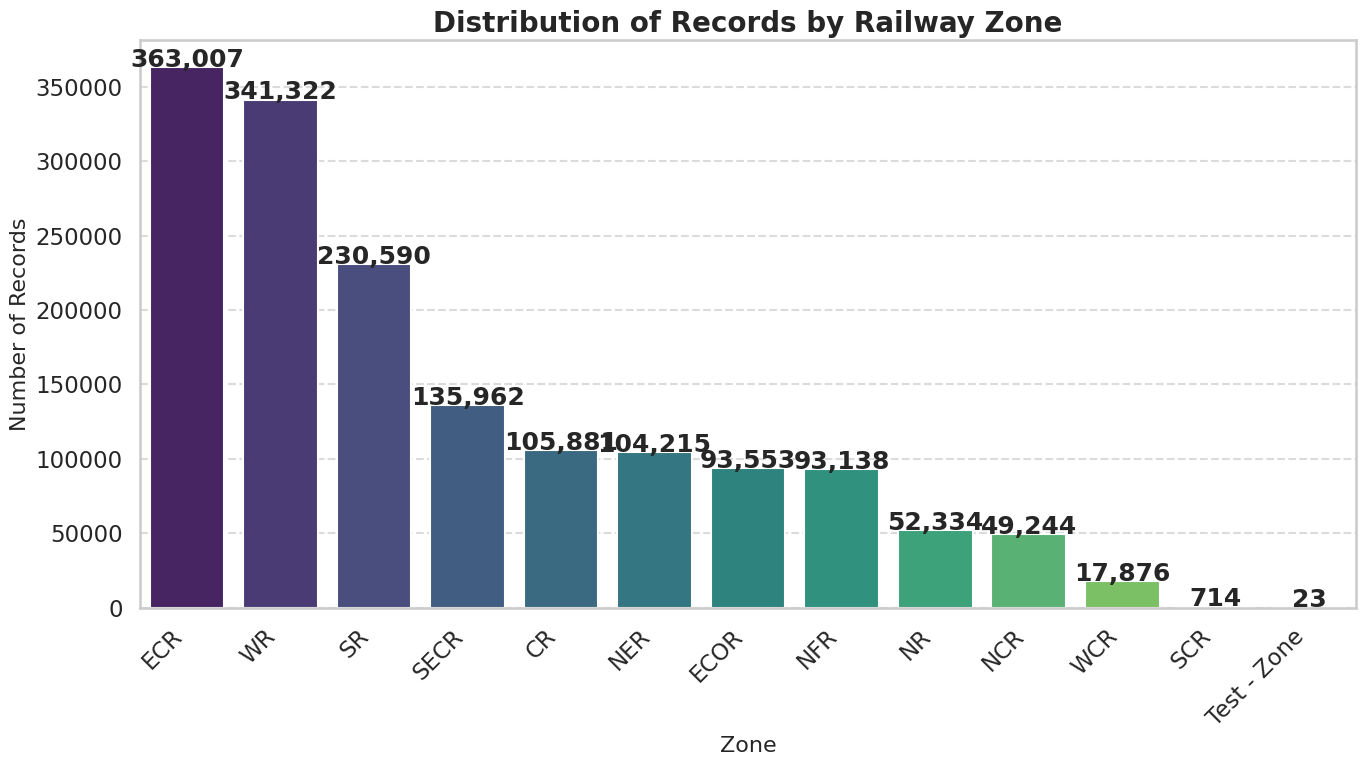

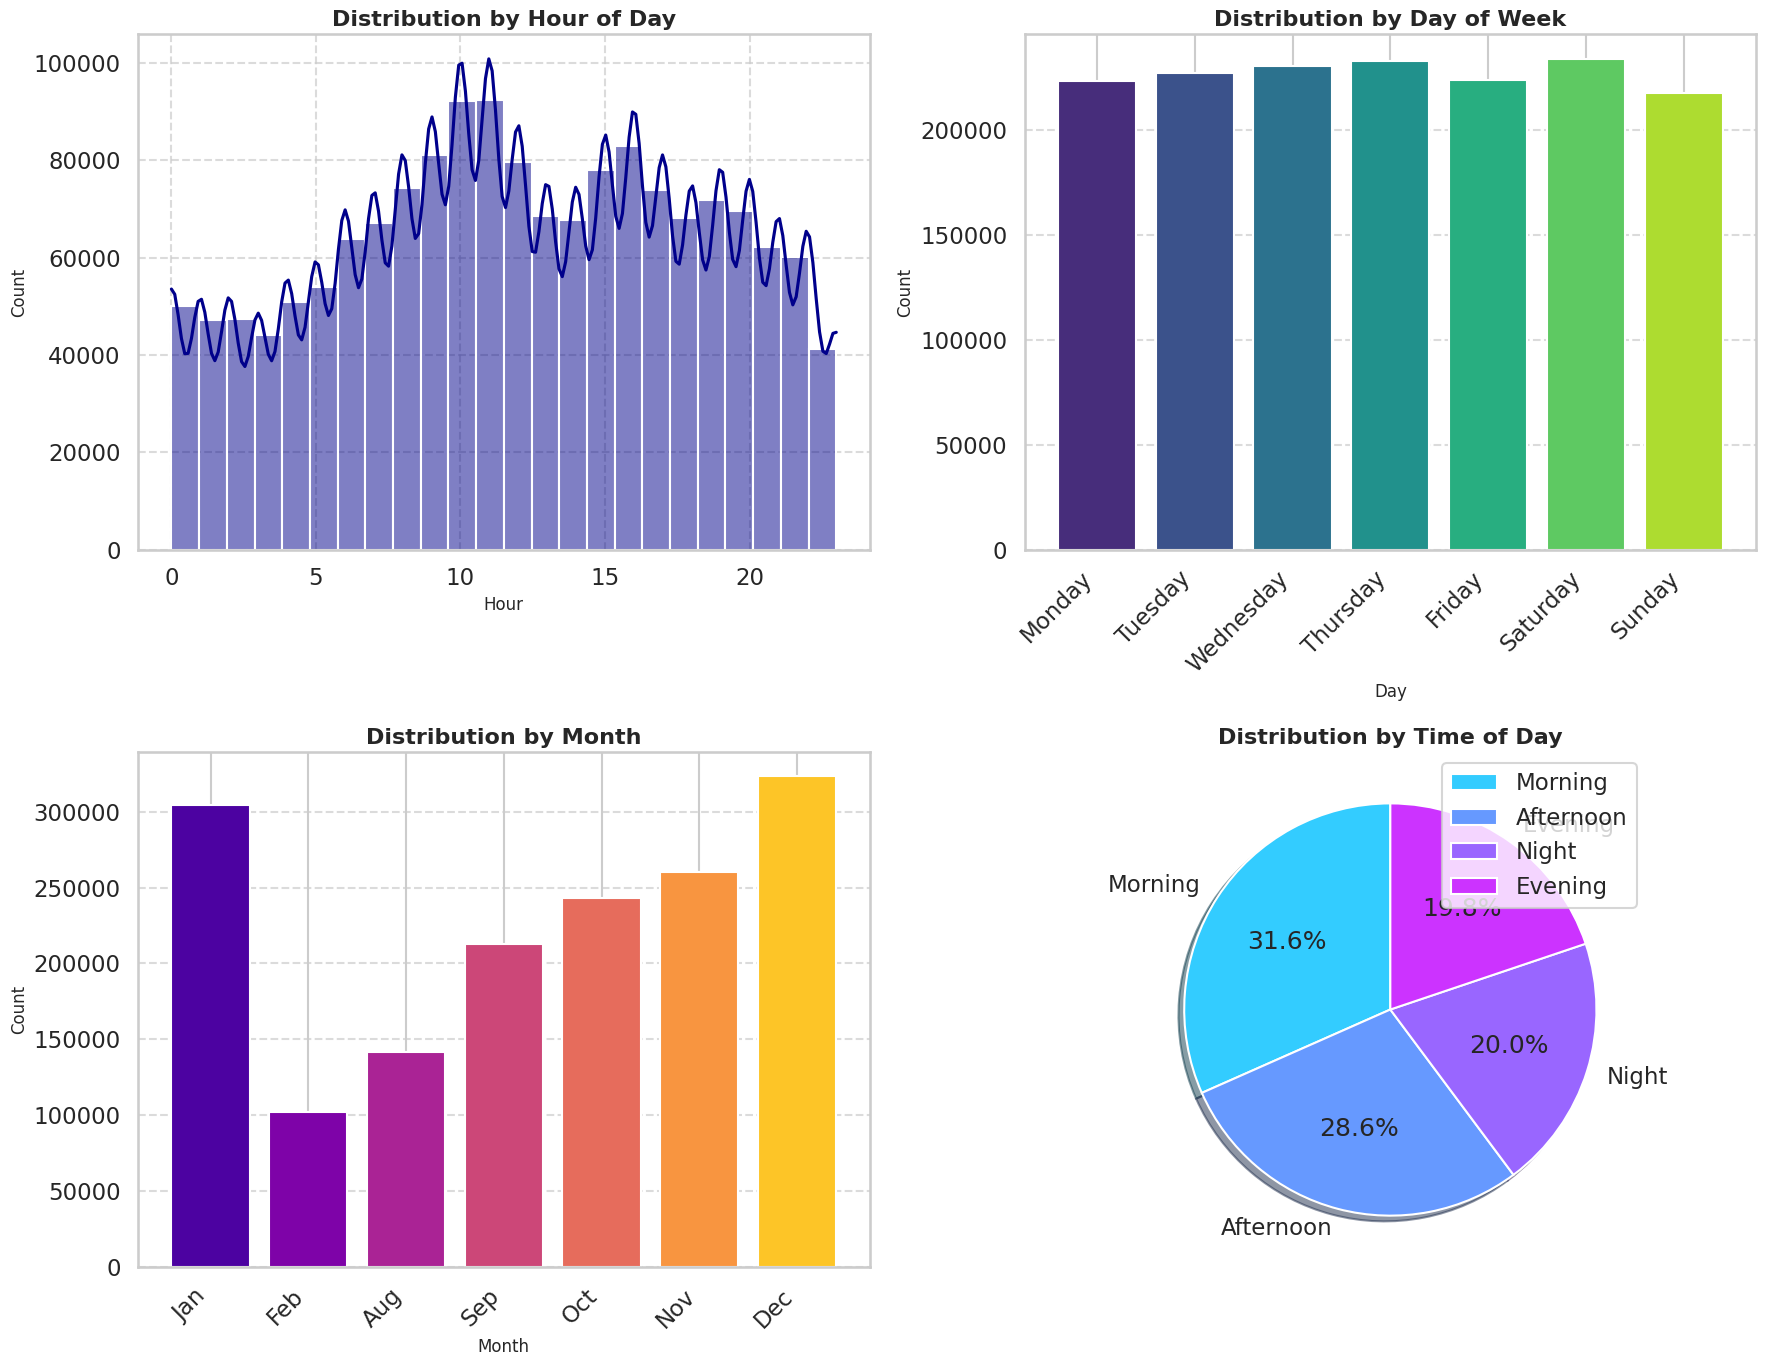

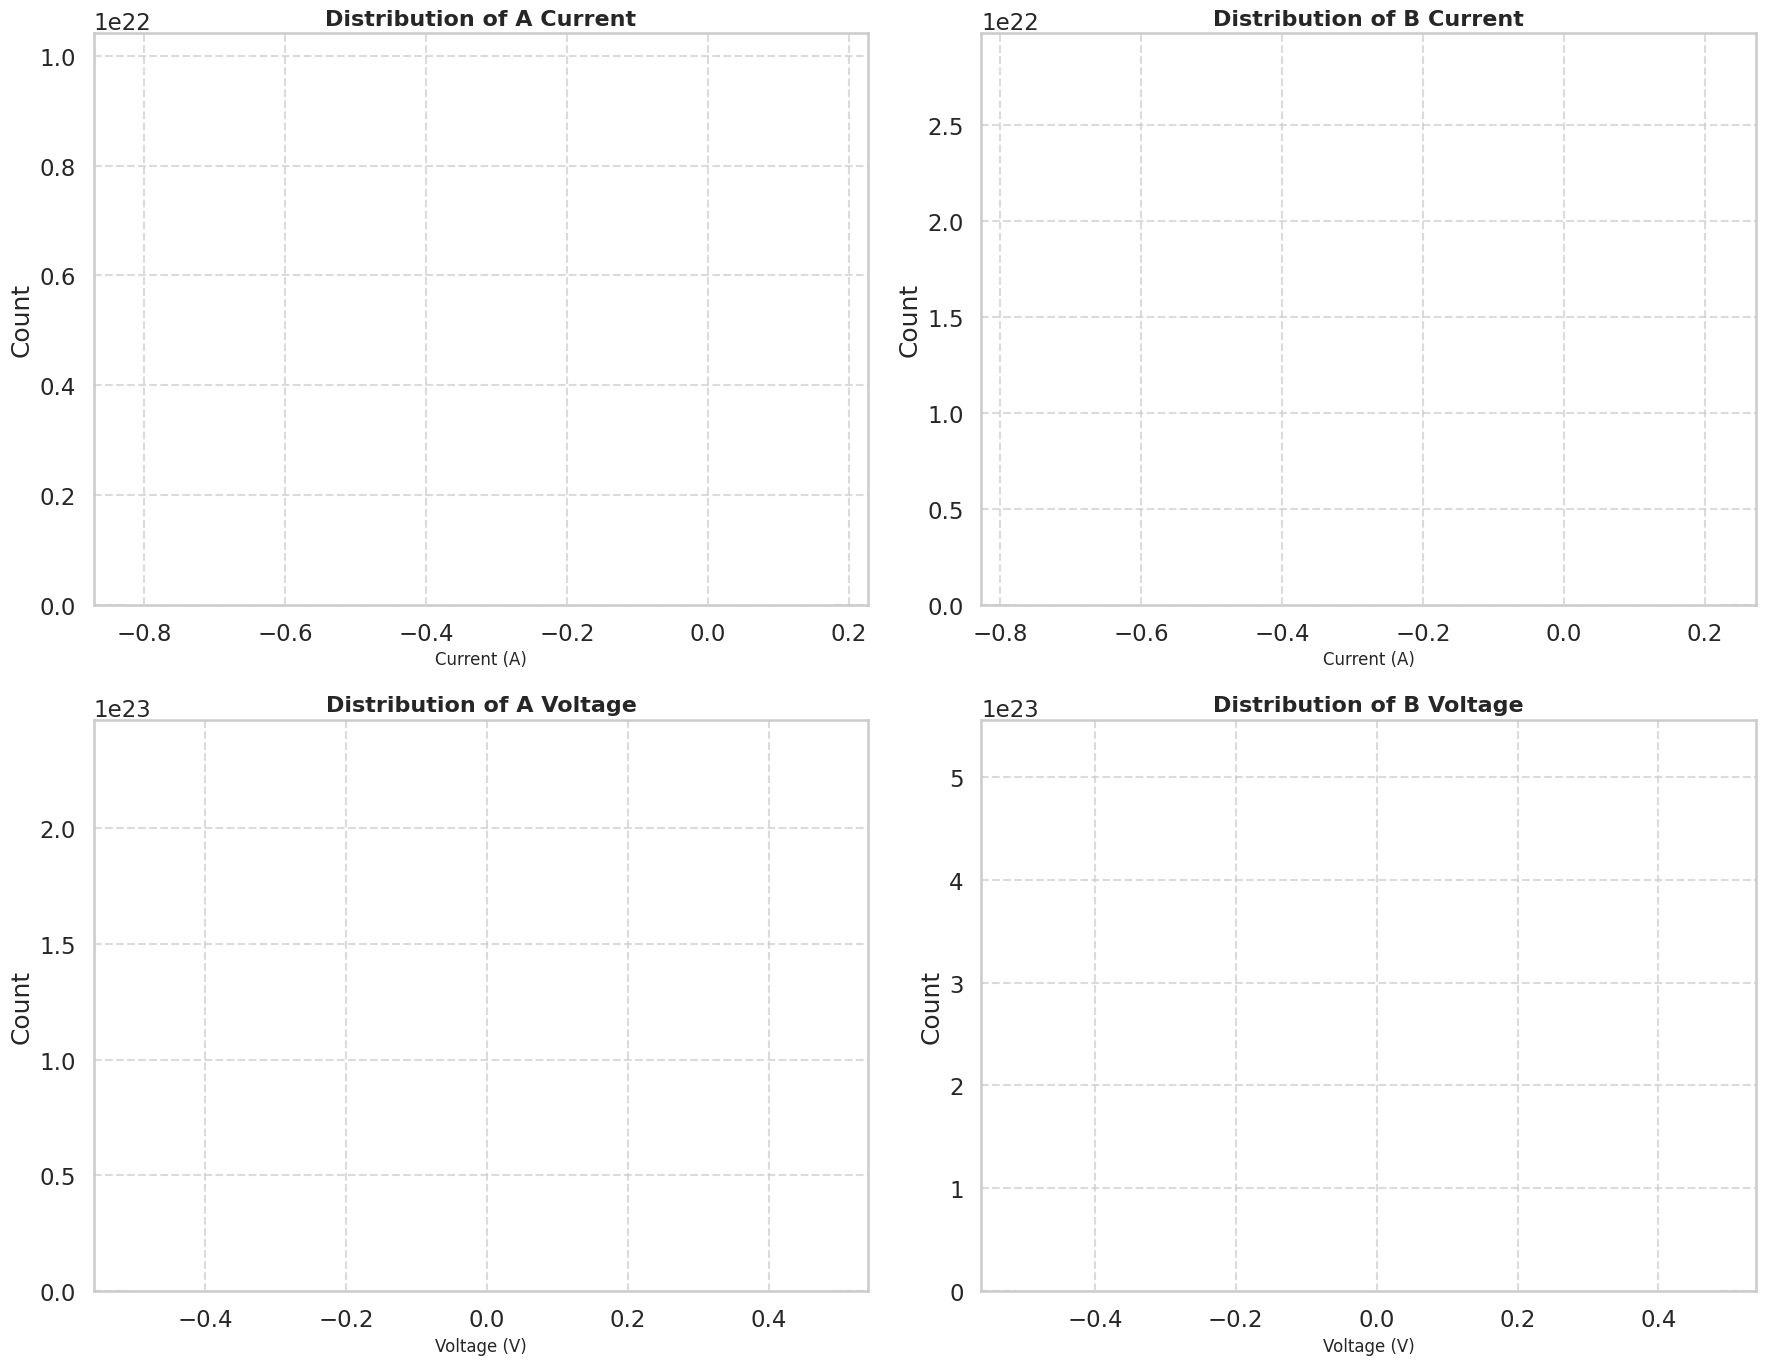

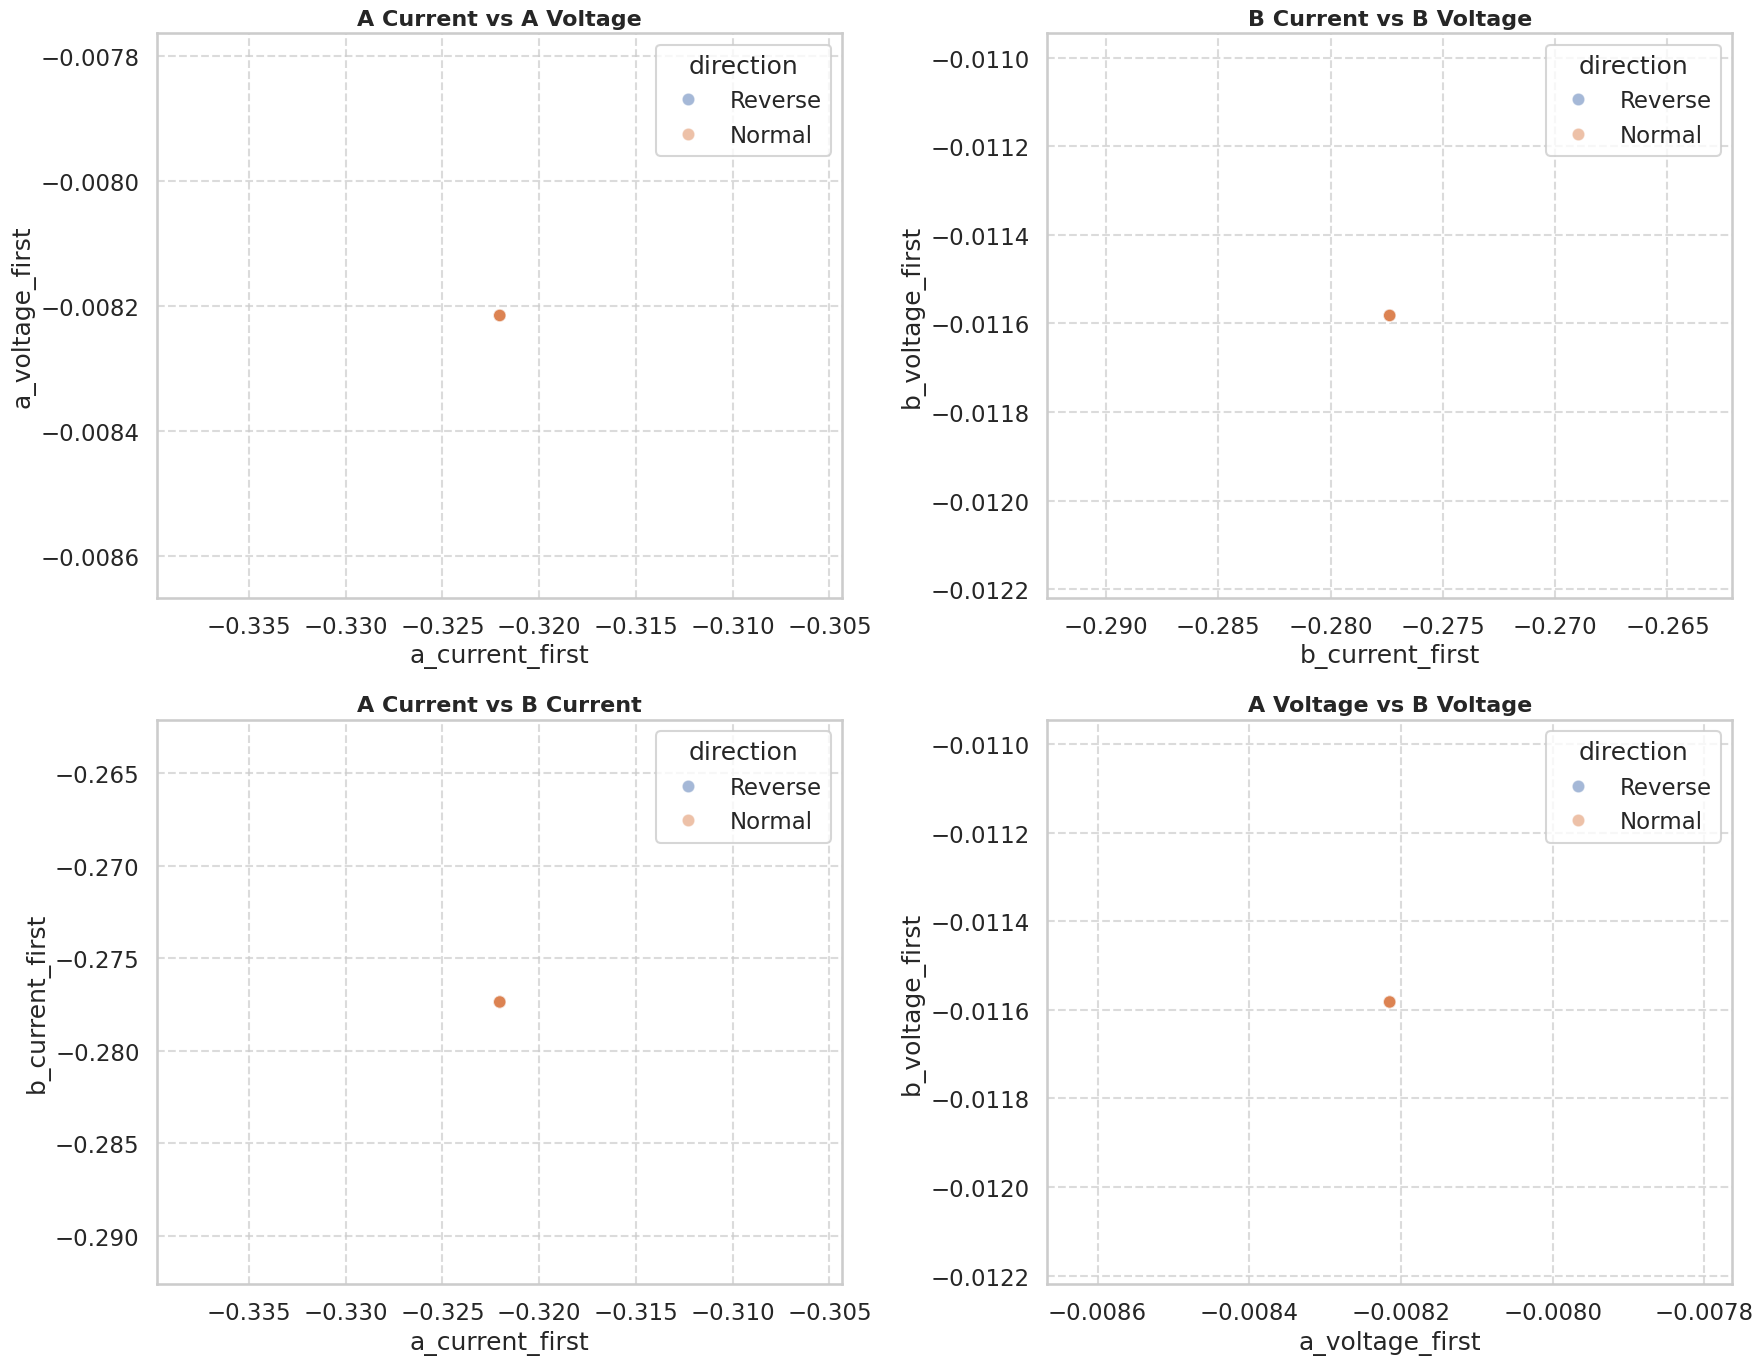

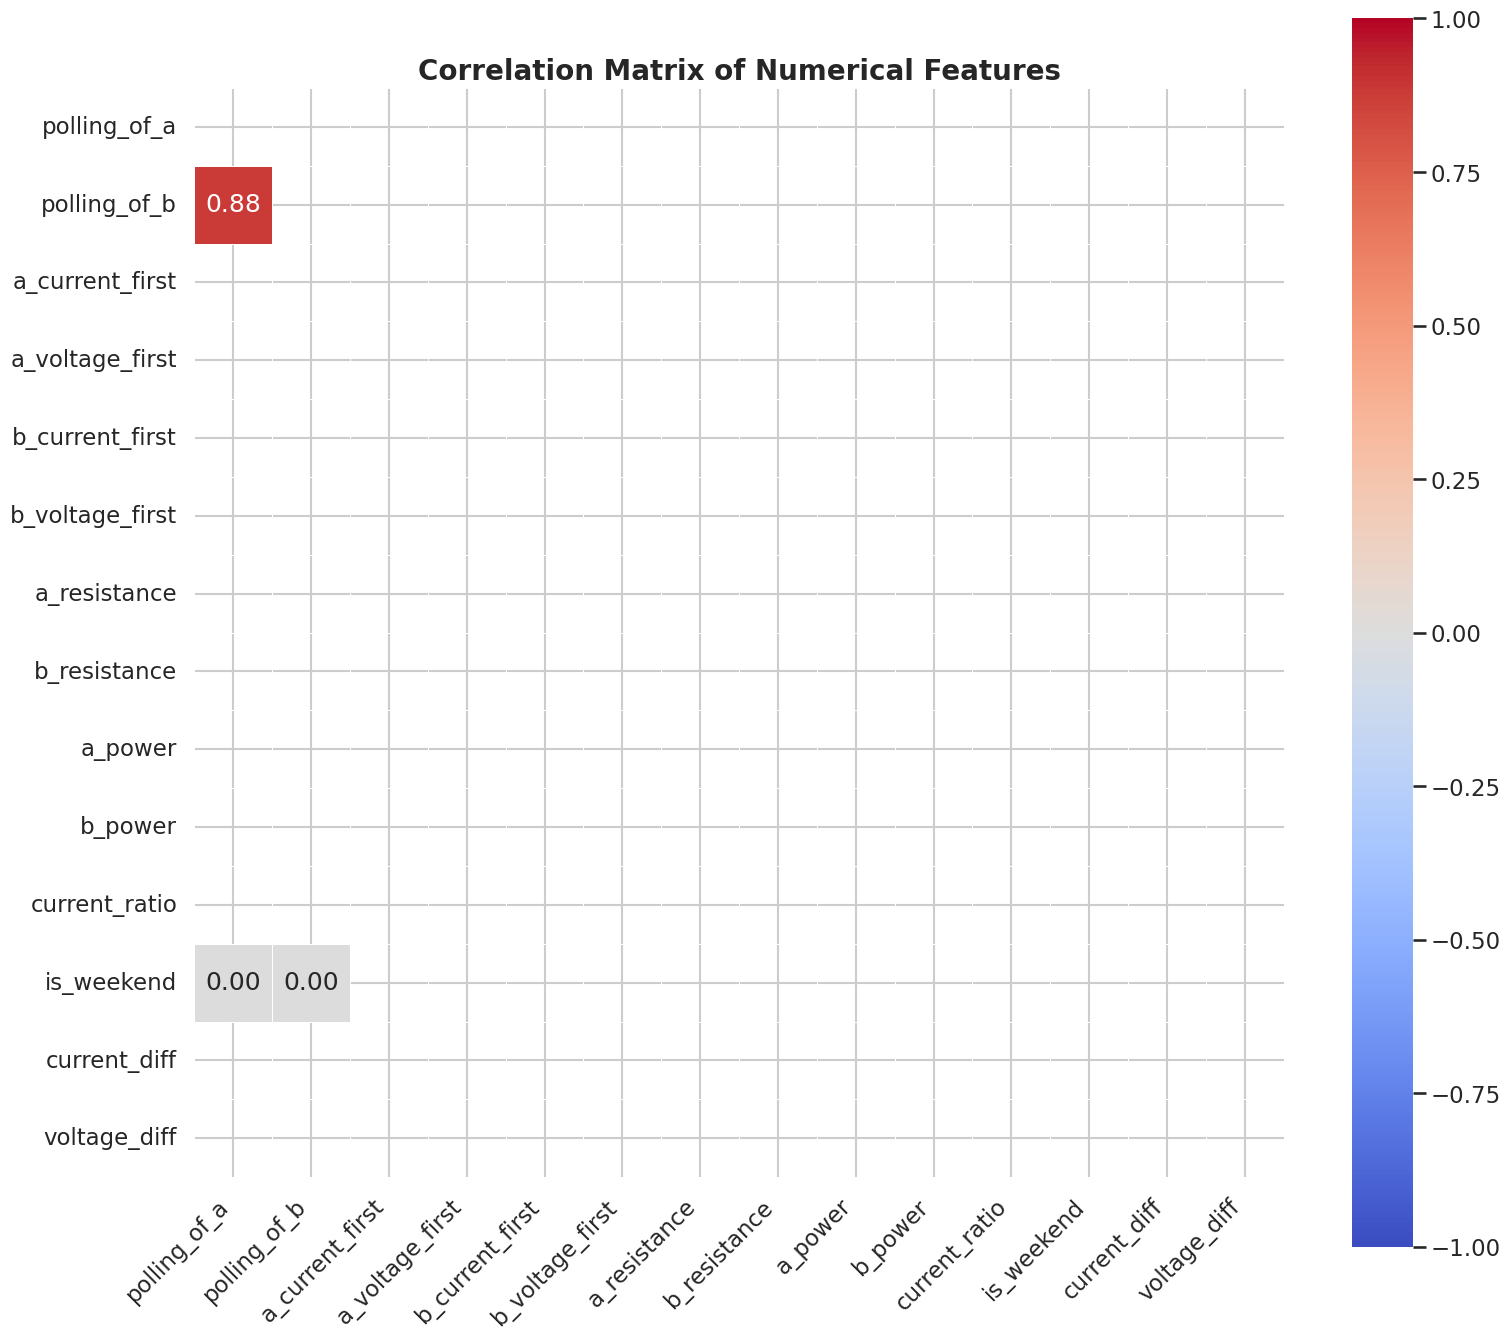

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Main execution logic
def main():
    # Process the dataset
    processed_df, enhanced_datasets_dict = enhance_dataset(datasets)
    
    # Display some info about the processed dataset
    print(f"\n🔍 Processed dataset information:")
    print(f"  - Total records: {len(processed_df):,}")
    print(f"  - Features: {processed_df.shape[1]}")
    print(f"  - Zones: {processed_df['zone'].nunique()}")
    if 'direction' in processed_df.columns:
        print(f"  - Directions: {processed_df['direction'].nunique()}")
    
    # Visualize the enhanced dataset
    visualize_enhanced_dataset(processed_df, enhanced_datasets_dict)
    
    # Split and save the dataset for modeling
    split_result = split_and_save_dataset(processed_df)
    
    # Calculate dataset quality metrics
    missing_values = processed_df.isnull().sum().sum()
    total_elements = processed_df.shape[0] * processed_df.shape[1]
    missing_percentage = missing_values / total_elements * 100
    
    print(f"\n📊 Dataset Quality Metrics:")
    print(f"  - Completeness: {100 - missing_percentage:.2f}%")
    print(f"  - Missing Values: {missing_values:,} ({missing_percentage:.2f}%)")
    
    print("\n🎉 Processing complete! Your enhanced dataset is ready for model training.")
    print("   - The processed data is saved in the 'data' directory")
    print("   - Visualizations are saved in the 'figures' directory")

# Run the enhancement process
# if __name__ == "__main__":
#     main()


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from datetime import datetime
import os
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set the visualization style for more professional plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
sns.set_palette("viridis")


# Enhanced Data Processing Pipeline

In [44]:
def enhance_dataset(datasets_dict):
    """
    Advanced data preprocessing and feature engineering pipeline
    """
    print("🚂 Starting advanced data processing...")
    
    # Create a copy to avoid modifying originals
    enhanced_datasets = {}
    
    for zone_name, df in tqdm(datasets_dict.items(), desc="Processing Zones"):
        # Create a deep copy to avoid modifying the original
        enhanced_df = df.copy(deep=True)
        
        # 1. Convert time to datetime if it's not already
        if 'time' in enhanced_df.columns:
            enhanced_df['time'] = pd.to_datetime(enhanced_df['time'], errors='coerce')
        
        # 2. Advanced missing value handling with proper imputation
        enhanced_df = handle_missing_values(enhanced_df)
        
        # 3. Feature engineering
        enhanced_df = engineer_features(enhanced_df)
        
        # 4. Add zone as a feature
        if 'zone' not in enhanced_df.columns:
            enhanced_df['zone'] = zone_name.replace('.csv', '')
        
        # Store the enhanced dataframe
        enhanced_datasets[zone_name] = enhanced_df
    
    # Consolidate all datasets into one
    print("🔄 Consolidating datasets...")
    consolidated_df = pd.concat(enhanced_datasets.values(), ignore_index=True)
    
    # Final processing steps
    print("📊 Performing final processing steps...")
    
    # 5. Encode categorical variables
    consolidated_df = encode_categorical_variables(consolidated_df)
    
    # 6. Handle outliers
    consolidated_df = handle_outliers(consolidated_df)
    
    # 7. Normalize numerical features
    consolidated_df = normalize_features(consolidated_df)
    
    # 8. Final check for any remaining NaN values
    consolidated_df = final_cleaning(consolidated_df)
    
    print("✅ Advanced data processing complete!")
    
    return consolidated_df, enhanced_datasets

def handle_missing_values(df):
    """
    Advanced handling of missing values with multiple imputation strategies
    """
    # Make a copy to avoid warnings
    df = df.copy()
    
    # For electrical measurement columns - now using explicit column names
    electrical_cols = [col for col in df.columns if col in ['a_current_first', 'a_voltage_first', 
                                                           'b_current_first', 'b_voltage_first']]
    
    # For categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    # For numerical columns (excluding electrical measurements)
    numerical_cols = df.select_dtypes(include=['number']).columns.difference(electrical_cols)
    
    # 1. For electrical measurements, use iterative imputation (MICE)
    if len(electrical_cols) > 0:  # Changed from electrical_cols.size > 0
        # First, handle inf and -inf values
        for col in electrical_cols:
            if col in df.columns:
                df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        
        # Extract columns that exist in the dataframe
        existing_cols = [col for col in electrical_cols if col in df.columns]
        
        if existing_cols:
            # Create a subset dataframe with just these columns
            subset_df = df[existing_cols].copy()
            
            # Apply iterative imputation if there are missing values
            if subset_df.isnull().sum().sum() > 0:
                imp = IterativeImputer(max_iter=10, random_state=42)
                imputed_values = imp.fit_transform(subset_df)
                
                # Replace the original values with imputed ones
                for i, col in enumerate(existing_cols):
                    df[col] = imputed_values[:, i]
    
    # 2. For numerical columns, use KNN imputation
    if numerical_cols.size > 0:
        existing_num_cols = [col for col in numerical_cols if col in df.columns]
        if existing_num_cols and df[existing_num_cols].isnull().sum().sum() > 0:
            imputer = KNNImputer(n_neighbors=5, weights='uniform')
            df[existing_num_cols] = imputer.fit_transform(df[existing_num_cols])
    
    # 3. For categorical columns, use mode imputation with Unknown category for high missing ratios
    for col in categorical_cols:
        if col in df.columns:
            missing_ratio = df[col].isnull().mean()
            if missing_ratio > 0:
                if missing_ratio > 0.5:  # If more than 50% are missing
                    df[col] = df[col].fillna('Unknown')
                else:
                    df[col] = df[col].fillna(df[col].mode()[0])
    
    return df

def engineer_features(df):
    """
    Create valuable new features from existing data
    """
    df = df.copy()
    
    # Time-based features
    if 'time' in df.columns:
        df['hour'] = df['time'].dt.hour
        df['day'] = df['time'].dt.day
        df['month'] = df['time'].dt.month
        df['year'] = df['time'].dt.year
        df['day_of_week'] = df['time'].dt.dayofweek
        df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
        
        # Time of day category
        df['time_of_day'] = pd.cut(
            df['hour'], 
            bins=[0, 6, 12, 18, 24], 
            labels=['Night', 'Morning', 'Afternoon', 'Evening'],
            include_lowest=True
        )
    
    # Extract first value from measurement columns and create ratio features
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
        # Create a resistance feature (V/I)
        df['a_resistance'] = df['a_voltage_first'] / df['a_current_first'].replace(0, np.nan)
        df['a_resistance'] = df['a_resistance'].replace([np.inf, -np.inf], np.nan)
    
    if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
        df['b_resistance'] = df['b_voltage_first'] / df['b_current_first'].replace(0, np.nan)
        df['b_resistance'] = df['b_resistance'].replace([np.inf, -np.inf], np.nan)
    
    # Create a power feature
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
        df['a_power'] = df['a_current_first'] * df['a_voltage_first']
    
    if all(col in df.columns for col in ['b_current_first', 'b_voltage_first']):
        df['b_power'] = df['b_current_first'] * df['b_voltage_first']
    
    # Direction-based features
    if 'direction' in df.columns:
        # One-hot encode direction
        direction_dummies = pd.get_dummies(df['direction'], prefix='dir', drop_first=False)
        df = pd.concat([df, direction_dummies], axis=1)
    
    return df

def encode_categorical_variables(df):
    """
    Encode categorical variables for machine learning
    """
    df = df.copy()
    
    # Identify categorical columns that need encoding
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Remove 'time' and any other datetime columns from categorical list
    if 'time' in cat_cols:
        cat_cols.remove('time')
    
    # For each categorical column
    for col in cat_cols:
        if df[col].nunique() <= 10:  # For low cardinality features, use one-hot encoding
            one_hot = pd.get_dummies(df[col], prefix=col, drop_first=False)
            df = pd.concat([df.drop(col, axis=1), one_hot], axis=1)
        else:  # For high cardinality features, use label encoding
            le = LabelEncoder()
            df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    
    return df

def handle_outliers(df):
    """
    Detect and handle outliers using IQR method
    """
    df = df.copy()
    
    # Only apply to numerical columns
    num_cols = df.select_dtypes(include=['number']).columns
    
    for col in num_cols:
        # Skip columns with too many unique values (like IDs) or binary features
        if df[col].nunique() > 10 and df[col].nunique() < len(df) * 0.5:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds for outliers (using 3 * IQR for a more conservative approach)
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            
            # Instead of removing, cap the outliers
            df[col] = df[col].clip(lower_bound, upper_bound)
    
    return df

def normalize_features(df):
    """
    Normalize numerical features using robust scaling
    """
    df = df.copy()
    
    # Select numerical columns
    num_cols = df.select_dtypes(include=['number']).columns
    
    # Use RobustScaler which is less influenced by outliers
    scaler = RobustScaler()
    
    # Apply scaling
    df[num_cols] = scaler.fit_transform(df[num_cols])
    
    return df

def final_cleaning(df):
    """
    Final cleaning to ensure no missing values remain
    """
    df = df.copy()
    
    # Check for any remaining NaN values
    null_cols = df.columns[df.isnull().any()].tolist()
    
    if null_cols:
        print(f"⚠️ Found {len(null_cols)} columns with remaining NaN values. Filling with appropriate values...")
        
        for col in null_cols:
            # For numerical columns, use median
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].median())
            # For categorical columns, use mode
            else:
                df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")
    
    return df


# Improved Visualization Funcitons

In [45]:
def visualize_enhanced_dataset(df, enhanced_datasets_dict):
    """
    Enhanced data visualization with improved aesthetics and NaN handling
    """
    print("\n📊 Creating visualizations of the enhanced dataset...")
    
    # Define a custom color palette
    colors = sns.color_palette("viridis", 10)
    
    # 1. Distribution of zones
    plt.figure(figsize=(14, 8))
    zone_counts = df['zone'].value_counts()
    
    # Create a horizontal bar chart
    ax = sns.barplot(x=zone_counts.values, y=zone_counts.index, palette="viridis")
    plt.title('Distribution of Data Points by Railway Zone', fontsize=18)
    plt.xlabel('Number of Data Points', fontsize=14)
    plt.ylabel('Zone', fontsize=14)
    
    # Add count labels to the bars
    for i, v in enumerate(zone_counts.values):
        ax.text(v + 0.1, i, f"{v:,}", va='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('zone_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # 2. Direction distribution
    if 'direction' in df.columns:
        plt.figure(figsize=(10, 6))
        direction_counts = df['direction'].value_counts()
        ax = sns.barplot(x=direction_counts.index, y=direction_counts.values, palette=colors[:len(direction_counts)])
        plt.title('Distribution by Direction', fontsize=18)
        plt.xlabel('Direction', fontsize=14)
        plt.ylabel('Count', fontsize=14)
        plt.xticks(rotation=45)
        
        # Add percentage labels
        total = float(len(df))
        for i, v in enumerate(direction_counts.values):
            ax.text(i, v + 0.1, f"{v:,} ({v/total:.1%})", ha='center', fontsize=12)
            
        plt.tight_layout()
        plt.savefig('direction_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 3. PCA of electrical measurements (ensuring no NaN values)
    numerical_cols = df.select_dtypes(include=['number']).columns
    
    # Get correlation for selecting features
    corr_cols = [col for col in numerical_cols if (
        'current' in col.lower() or 
        'voltage' in col.lower() or 
        'resistance' in col.lower() or
        'power' in col.lower()
    )]
    
    if len(corr_cols) > 2:
        # Verify no NaN values before PCA
        df_pca = df[corr_cols].copy()
        
        # Check for NaN values and handle them
        if df_pca.isnull().sum().sum() > 0:
            print("⚠️ Found NaN values before PCA. Applying imputation...")
            imputer = SimpleImputer(strategy='median')
            df_pca = pd.DataFrame(
                imputer.fit_transform(df_pca),
                columns=df_pca.columns
            )
        
        # Perform PCA on cleaned data
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(df_pca)
        
        # Create a dataframe with the principal components
        pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
        
        # Add zone information for coloring
        pca_df['zone'] = df['zone'].values
        
        # Plot PCA
        plt.figure(figsize=(12, 10))
        
        # Use a better color palette for distinguishing zones
        unique_zones = pca_df['zone'].unique()
        zone_palette = sns.color_palette("tab20", len(unique_zones))
        
        # Create a scatter plot with zones colored
        scatter = sns.scatterplot(
            x='PC1', y='PC2', 
            hue='zone', 
            data=pca_df,
            palette=zone_palette,
            alpha=0.7,
            s=80
        )
        
        # Improve the legend placement and size
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
        
        # Add explanatory text
        explained_variance = pca.explained_variance_ratio_
        plt.title(f'PCA of Electrical Measurements by Zone', fontsize=18)
        plt.xlabel(f'PC1 (Explains {explained_variance[0]:.2%} of variance)', fontsize=14)
        plt.ylabel(f'PC2 (Explains {explained_variance[1]:.2%} of variance)', fontsize=14)
        
        # Add grid for better readability
        plt.grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.savefig('pca_by_zone.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 4. Time analysis - hourly distribution
    if 'hour' in df.columns:
        plt.figure(figsize=(12, 7))
        
        # Create a more visually appealing hourly distribution
        hour_counts = df['hour'].value_counts().sort_index()
        
        # Plot hourly distribution with better aesthetics
        ax = sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='viridis')
        
        # Add smooth curve overlay showing the trend
        sns.lineplot(x=hour_counts.index, y=hour_counts.values, color='red', linewidth=2.5)
        
        plt.title('Hourly Distribution of Railway Data', fontsize=18)
        plt.xlabel('Hour of Day', fontsize=14)
        plt.ylabel('Count', fontsize=14)
        plt.xticks(range(0, 24))
        
        # Add vertical lines for day segments
        plt.axvline(x=6, color='grey', linestyle='--', alpha=0.7)
        plt.axvline(x=12, color='grey', linestyle='--', alpha=0.7)
        plt.axvline(x=18, color='grey', linestyle='--', alpha=0.7)
        
        # Add text annotations for day segments
        plt.text(3, hour_counts.max()*0.9, 'Night', fontsize=12, ha='center')
        plt.text(9, hour_counts.max()*0.9, 'Morning', fontsize=12, ha='center')
        plt.text(15, hour_counts.max()*0.9, 'Afternoon', fontsize=12, ha='center')
        plt.text(21, hour_counts.max()*0.9, 'Evening', fontsize=12, ha='center')
        
        plt.tight_layout()
        plt.savefig('hourly_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 5. Relationships between electrical measurements
    if all(col in df.columns for col in ['a_current_first', 'a_voltage_first']):
        plt.figure(figsize=(10, 8))
        
        # Create a sample of data for better visualization if dataset is large
        if len(df) > 5000:
            sample_df = df.sample(5000, random_state=42)
        else:
            sample_df = df
        
        # Plot relationship with direction coloring
        if 'direction' in sample_df.columns:
            scatter = sns.scatterplot(
                x='a_current_first', 
                y='a_voltage_first', 
                hue='direction',
                data=sample_df,
                alpha=0.6,
                palette='coolwarm'
            )
        else:
            scatter = sns.scatterplot(
                x='a_current_first', 
                y='a_voltage_first', 
                data=sample_df,
                alpha=0.6,
                color='blue'
            )
            
        plt.title('Relationship Between Current and Voltage (A Circuit)', fontsize=18)
        plt.xlabel('Current (A)', fontsize=14)
        plt.ylabel('Voltage (V)', fontsize=14)
        
        # Add regression line
        sns.regplot(
            x='a_current_first', 
            y='a_voltage_first', 
            data=sample_df,
            scatter=False, 
            ci=None,
            line_kws={"color": "red", "alpha": 0.7, "lw": 2}
        )
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig('current_voltage_relationship.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    print("✅ Visualizations created successfully!")


# Dataset Splitting for ML training

In [46]:
def split_and_save_dataset(df, output_path="processed_data"):
    """
    Split the dataset into training and testing sets, then save them
    """
    print("\n💾 Preparing and saving datasets for machine learning...")
    
    # Create directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # If time column exists, sort by time
    if 'time' in df.columns:
        df = df.sort_values('time')
    
    # Convert any categorical variables that weren't one-hot encoded
    cat_cols = df.select_dtypes(include=['object']).columns
    
    # Drop the time column for machine learning
    if 'time' in df.columns:
        df_ml = df.drop('time', axis=1)
    else:
        df_ml = df.copy()
    
    # For remaining object columns that weren't encoded
    for col in cat_cols:
        if col in df_ml.columns and col != 'time':
            # Some columns might remain as objects even after encoding
            # Create a new encoded column for them
            if col not in ['zone']:  # Keep zone as is for reference
                le = LabelEncoder()
                try:
                    df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col].astype(str))
                    # Save the encoder for future use
                    joblib.dump(le, f"{output_path}/{col}_encoder.joblib")
                except:
                    print(f"⚠️ Warning: Could not encode column {col}")
    
    # Split into train and test sets (80/20)
    # Stratify by zone if available
    if 'zone' in df_ml.columns:
        train_df, test_df = train_test_split(
            df_ml, 
            test_size=0.2, 
            random_state=42,
            stratify=df_ml['zone']
        )
    else:
        train_df, test_df = train_test_split(
            df_ml, 
            test_size=0.2, 
            random_state=42
        )
    
    # Save datasets
    train_df.to_csv(f"{output_path}/train_data.csv", index=False)
    test_df.to_csv(f"{output_path}/test_data.csv", index=False)
    
    # Save the full dataset for reference
    df.to_csv(f"{output_path}/full_processed_dataset.csv", index=False)
    
    # Save dataset statistics
    stats = {
        'total_samples': len(df),
        'train_samples': len(train_df),
        'test_samples': len(test_df),
        'features': len(df_ml.columns),
        'zones': df['zone'].nunique() if 'zone' in df.columns else 0,
        'directions': df['direction'].nunique() if 'direction' in df.columns else 0
    }
    
    with open(f"{output_path}/dataset_stats.txt", "w") as f:
        for key, value in stats.items():
            f.write(f"{key}: {value}\n")
    
    print(f"✅ Datasets saved successfully to {output_path}!")
    print(f"  - Total samples: {stats['total_samples']}")
    print(f"  - Training samples: {stats['train_samples']}")
    print(f"  - Testing samples: {stats['test_samples']}")
    print(f"  - Features: {stats['features']}")
    print(f"  - Zones: {stats['zones']}")
    print(f"  - Directions: {stats['directions']}")
    
    return {
        'train_df': train_df,
        'test_df': test_df,
        'stats': stats
    }

def main():
    # Load datasets
    data_dir = '/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data'
    
    # List all CSV files
    csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    
    # Load datasets
    datasets = {}
    for file_name in csv_files:
        file_path = os.path.join(data_dir, file_name)
        datasets[file_name] = pd.read_csv(file_path, low_memory=False)
    
    # Process and enhance datasets
    processed_df, enhanced_datasets_dict = enhance_dataset(datasets)
    
    # Print some basic statistics
    print("\n📈 Dataset Statistics:")
    print(f"  - Total samples: {len(processed_df)}")
    print(f"  - Features: {len(processed_df.columns)}")
    print(f"  - Zones: {processed_df['zone'].nunique()}")
    print(f"  - Directions: {processed_df['direction'].nunique()}")
    
    # Visualize the enhanced dataset
    visualize_enhanced_dataset(processed_df, enhanced_datasets_dict)
    
    # Split and save the dataset for modeling
    split_result = split_and_save_dataset(processed_df)

if __name__ == "__main__":
    main()


🚂 Starting advanced data processing...


Processing Zones: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [44:19<00:00, 204.54s/it]


🔄 Consolidating datasets...
📊 Performing final processing steps...
✅ Advanced data processing complete!

📈 Dataset Statistics:
  - Total samples: 1587859
  - Features: 25
  - Zones: 13


KeyError: 'direction'

Found 13 CSV files
['WR.csv', 'NR.csv', 'NCR.csv', 'CR.csv', 'SCR.csv', 'NFR.csv', 'ECOR.csv', 'ECR.csv', 'WCR.csv', 'Test - Zone.csv', 'SR.csv', 'NER.csv', 'SECR.csv']


Loaded WR.csv with shape (341322, 12)
Loaded NR.csv with shape (52334, 12)
Loaded NCR.csv with shape (49244, 12)
Loaded CR.csv with shape (105881, 12)
Loaded SCR.csv with shape (714, 12)
Loaded NFR.csv with shape (93138, 12)
Loaded ECOR.csv with shape (93553, 12)
Loaded ECR.csv with shape (363007, 12)
Loaded WCR.csv with shape (17876, 12)
Loaded Test - Zone.csv with shape (23, 12)
Loaded SR.csv with shape (230590, 12)
Loaded NER.csv with shape (104215, 12)
Loaded SECR.csv with shape (135962, 12)

Sample from WR.csv:
                  Time Site Name Point Machine Name Direction  \
0  2025-02-10 01:04:09      Atul            101/102   Reverse   
1  2025-02-10 01:12:10      Atul            101/102    Normal   
2  2025-02-10 07:13:06      Atul            101/102   Reverse   
3  2025-02-10 08:00:53      Atul            101/102   Reverse   
4  2025-02-10 08:03:36      Atul            101/102    Normal   

                                           A Current  \
0  0.0,1.5,4.9,4.5,3.7,3,2.6,2.

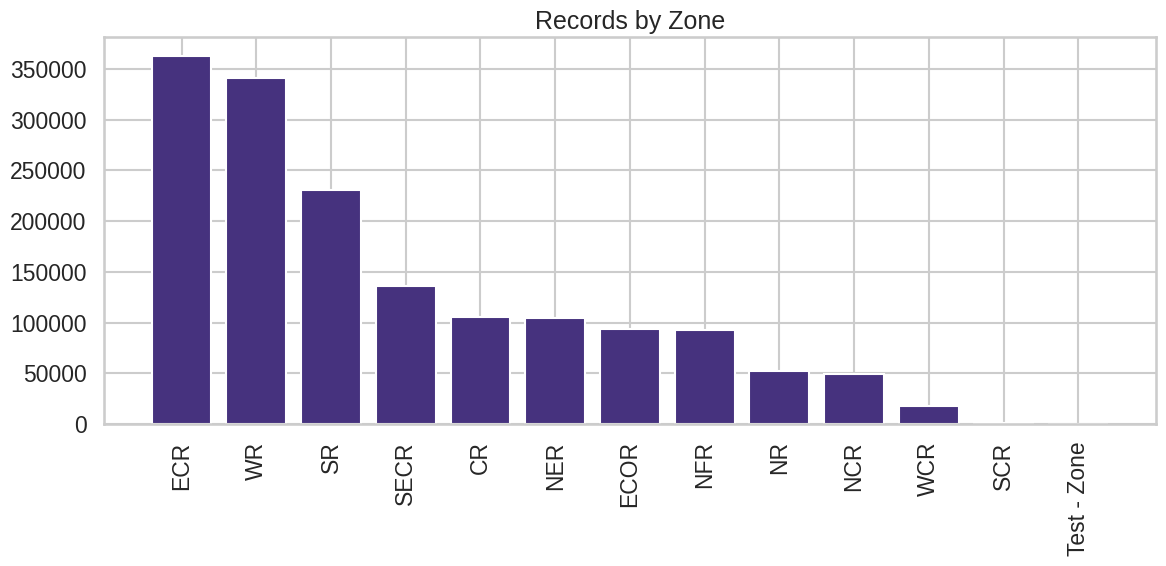

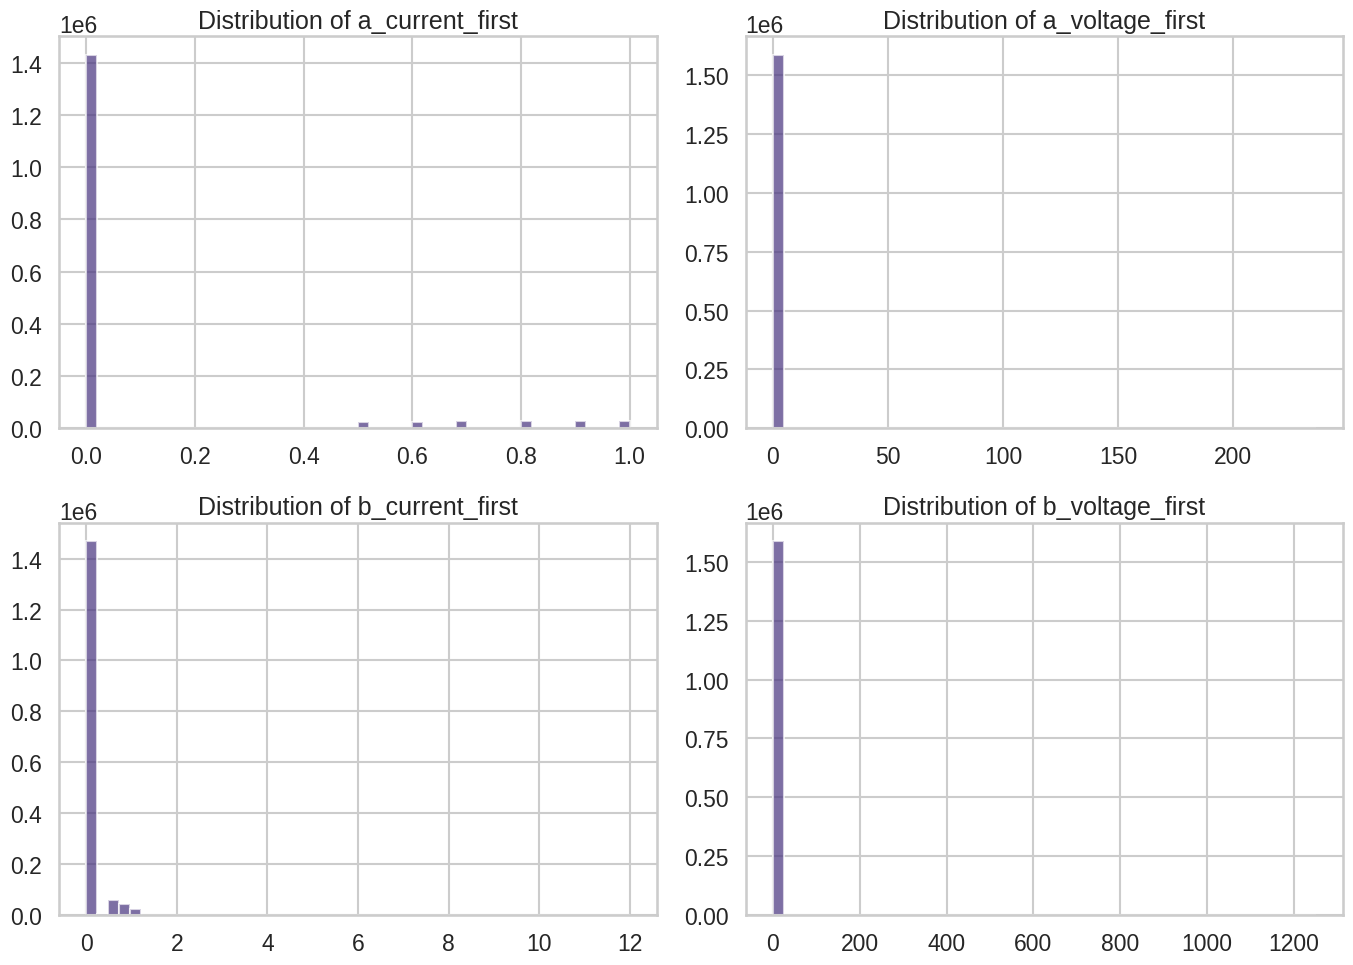

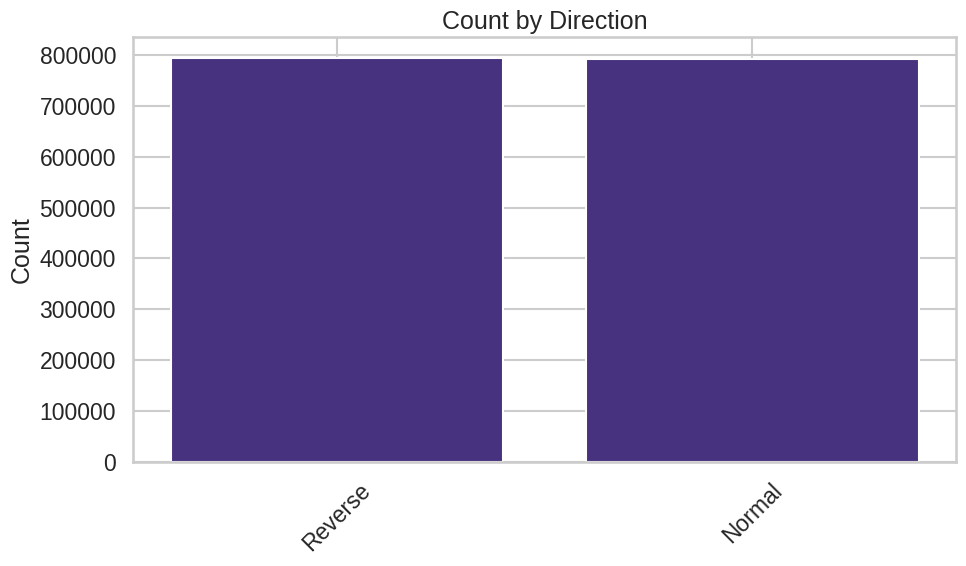


Processed dataset saved to /home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data/processed_railway_data.csv


: 

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define path to data directory
data_dir = '/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data'  # Replace with your actual path

# Function to load all datasets
def load_datasets(data_dir):
    # List all CSV files in the directory
    csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    print(f"Found {len(csv_files)} CSV files")
    print(csv_files)
    
    # Load all datasets into a dictionary
    datasets = {}
    for file_name in csv_files:
        file_path = os.path.join(data_dir, file_name)
        datasets[file_name] = pd.read_csv(file_path, low_memory=False)
        print(f"Loaded {file_name} with shape {datasets[file_name].shape}")
    
    return datasets, csv_files

# Function to preprocess datasets
def preprocess_datasets(datasets):
    # Add zone identifier before concatenating
    for zone_name, df in datasets.items():
        # Extract zone name from filename (remove .csv)
        zone = zone_name.replace('.csv', '')
        df['zone'] = zone
    
    # Fix data types
    for file_name, df in datasets.items():
        # Convert time to datetime
        df['Time'] = pd.to_datetime(df['Time'])
        
        # Ensure Point Machine Name is string type
        df['Point Machine Name'] = df['Point Machine Name'].astype(str)
    
    # Extract first value from array-like columns
    def extract_first_value(value_str):
        try:
            return float(str(value_str).split(',')[0])
        except (ValueError, AttributeError):
            return None
    
    # Apply to all datasets
    for df in datasets.values():
        df['a_current_first'] = df['A Current'].apply(extract_first_value)
        df['a_voltage_first'] = df['A Voltage'].apply(extract_first_value)
        df['b_current_first'] = df['B Current'].apply(extract_first_value)
        df['b_voltage_first'] = df['B Voltage'].apply(extract_first_value)
    
    # Standardize column names (replace spaces with underscores and convert to lowercase)
    for df in datasets.values():
        df.columns = [col.lower().replace(' ', '_') for col in df.columns]
    
    # Handle missing values
    for df in datasets.values():
        # Fill missing numerical values appropriately
        numeric_cols = df.select_dtypes(include=['number']).columns
        for col in numeric_cols:
            # Use df[col] = df[col].fillna(...) instead of inplace to avoid warnings
            df[col] = df[col].fillna(df[col].median())
        
        # Fill categorical with 'Unknown'
        categorical_cols = df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            df[col] = df[col].fillna('Unknown')
    
    # Combine all datasets
    combined_df = pd.concat(datasets.values(), ignore_index=True)
    
    # Check for and remove duplicates
    combined_df = combined_df.drop_duplicates().reset_index(drop=True)
    
    return combined_df

# Function to visualize dataset
def visualize_dataset(df):
    # Create some basic visualizations
    plt.figure(figsize=(12, 6))
    
    # Count of records by zone
    zone_counts = df['zone'].value_counts()
    plt.bar(zone_counts.index, zone_counts.values)
    plt.title('Records by Zone')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Check distribution of currents and voltages
    numeric_cols = ['a_current_first', 'a_voltage_first', 'b_current_first', 'b_voltage_first']
    plt.figure(figsize=(14, 10))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, 2, i)
        plt.hist(df[col].dropna(), bins=50, alpha=0.7)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
    
    # Direction distribution
    plt.figure(figsize=(10, 6))
    direction_counts = df['direction'].value_counts()
    plt.bar(direction_counts.index, direction_counts.values)
    plt.title('Count by Direction')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Main function
def main():
    # Load datasets
    datasets, csv_files = load_datasets(data_dir)
    
    # Preview a sample dataset to understand structure
    sample_file = csv_files[0]
    print(f"\nSample from {sample_file}:")
    print(datasets[sample_file].head())
    
    # Preprocess datasets
    print("\nPreprocessing datasets...")
    processed_df = preprocess_datasets(datasets)
    
    # Show basic statistics
    print("\n📊 Dataset Statistics:")
    print(f"  - Total samples: {processed_df.shape[0]}")
    print(f"  - Features: {processed_df.shape[1]}")
    print(f"  - Unique sites: {processed_df['site_name'].nunique()}")
    print(f"  - Directions: {processed_df['direction'].nunique()}")
    
    # Visualize
    visualize_dataset(processed_df)
    
    # Save processed dataset
    output_path = os.path.join(data_dir, 'processed_railway_data.csv')
    processed_df.to_csv(output_path, index=False)
    print(f"\nProcessed dataset saved to {output_path}")
    
    return processed_df

# Run the main function if this script is run directly
if __name__ == "__main__":
    processed_df = main()
